# Notebook 2 — Supply Constraints and Scarcity

## Overview

This notebook investigates the physical and operational conditions associated with scarcity events in the Alberta electricity market. Building on the master dataset developed in Notebook 1, the analysis examines system-level variables including generation availability, generation outages, fuel-specific constraints, available capacity, intertie flows, renewable output, and other operational state variables.

The objective is to understand how supply constraints, demand conditions, and system tightness interact to produce scarcity. Particular attention is given to capacity margins, availability conditions, outage behavior, and the relationship between available generation and system demand.

The results are primarily exploratory and descriptive. They identify operational patterns, evaluate potential scarcity indicators, and develop hypotheses for future forecasting and market analysis. They do not establish causality, but provide insight into the system conditions that characterize scarcity events.

## Executive Summary

## 1. Import and Data Validation

### 1.1. Import Libraries and Load Data

In [13]:
# ---------------------------------------------------------------------
# Configure project imports and notebook environment
# ---------------------------------------------------------------------

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))


# ---------------------------------------------------------------------
# Import libraries
# ---------------------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score

from config import (
    MASTER_PARQUET,
    RANDOM_SEED,
)


# ---------------------------------------------------------------------
# Configure notebook settings
# ---------------------------------------------------------------------

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

np.random.seed(RANDOM_SEED)


# ---------------------------------------------------------------------
# Load canonical analytical dataset
# ---------------------------------------------------------------------

master = pd.read_parquet(MASTER_PARQUET)


# ---------------------------------------------------------------------
# Basic dataset confirmation
# ---------------------------------------------------------------------

print(
    f"Master dataset loaded: {master.shape[0]:,} rows × "
    f"{master.shape[1]:,} columns"
)

print(
    f"Analysis period: "
    f"{master['timestamp_utc'].min()} → "
    f"{master['timestamp_utc'].max()}"
)

Master dataset loaded: 87,665 rows × 452 columns
Analysis period: 2015-01-01 07:00:00+00:00 → 2024-12-31 23:00:00+00:00


### 1.2. Dataset Overview

In [15]:
# ---------------------------------------------------------------------
# Dataset overview
# ---------------------------------------------------------------------

dataset_overview = pd.DataFrame({
    "Metric": [
        "Observations",
        "Features",
        "Start timestamp",
        "End timestamp",
        "Duplicate timestamps",
        "Missing values",
    ],
    "Value": [
        len(master),
        master.shape[1],
        master["timestamp_utc"].min(),
        master["timestamp_utc"].max(),
        master["timestamp_utc"].duplicated().sum(),
        master.isna().sum().sum(),
    ],
})

dataset_overview

,Metric,Value
0,Observations,87665
1,Features,452
2,Start timestamp,2015-01-01 07:00:00+00:00
3,End timestamp,2024-12-31 23:00:00+00:00
4,Duplicate timestamps,0
5,Missing values,1236776


### 1.3. Year-to-year Regime Classification

In [19]:
master["renewable_generation"] = (
    master["wind_system_generation"]
    + master["solar_system_generation"]
    + master["hydro_system_generation"]
)

master["renewable_share"] = (
    master["renewable_generation"]
    / master["total_system_generation"]
)

In [20]:
# ------------------------------------------------------------
# Define generation mix regimes
# ------------------------------------------------------------

def classify_generation_regime(year):

    if year <= 2018:
        return "coal_transition"

    elif year <= 2021:
        return "coal_exit_transition"

    else:
        return "renewables_gas_flexibility"


master["generation_regime"] = (
    master["year_alberta"]
    .apply(classify_generation_regime)
)


# Validate regime coverage

generation_regime_summary = (
    master
    .groupby("generation_regime")
    .agg(
        start_year=("year_alberta", "min"),
        end_year=("year_alberta", "max"),
        observations=("year_alberta", "count"),
        avg_renewable_share=("renewable_share", "mean"),
        avg_wind_generation=("wind_system_generation", "mean"),
        avg_pool_price=("pool_price", "mean")
    )
    .sort_values('start_year')
    .reset_index(drop = True)
)

generation_regime_summary

,start_year,end_year,observations,avg_renewable_share,avg_wind_generation,avg_pool_price
0,2015,2018,35064,0.097656,487.245472,31.028825
1,2019,2021,26304,0.129524,620.750348,67.823701
2,2022,2024,26297,0.216937,1155.730220,119.594842



> To account for structural changes in Alberta's generation mix, years are grouped into broader operating regimes rather than analyzed independently. The 2015–2018 period represents a coal transition regime, where coal remained a significant source of firm generation and scarcity was primarily influenced by thermal availability, reserves, and imports. The 2019–2021 period captures the coal exit transition, as coal retirements accelerated and natural gas became increasingly important for system flexibility. The 2022–2024 period represents a higher-renewable, gas-flexibility regime, where wind penetration increased and scarcity became more closely linked to renewable variability, net load, and the ability of thermal resources to respond.

## Section 2 - Individual Drivers of Scarcity

This section evaluates which operational variables are most strongly associated with scarcity events. ROC AUC analysis is used to measure the standalone information contained in demand, supply availability, renewable output, outages, imports, and system margin variables. These results identify important scarcity indicators and guide further analysis of how combinations of system conditions contribute to market stress.

### 2.1. Initial Scarcity Signals

In [21]:
# ---------------------------------------------------------------------
# Single feature ROC AUC helper
# ---------------------------------------------------------------------

def feature_auc(df, feature, target="scarcity_event"):

    sample = df[[feature, target]].dropna()

    y_true = sample[target]
    y_score = sample[feature]

    auc = roc_auc_score(y_true, y_score)

    direction = "positive"

    if auc < 0.5:
        auc = roc_auc_score(y_true, -y_score)
        direction = "negative"

    return {
        "feature": feature,
        "auc": auc,
        "direction": direction,
        "n_obs": len(sample),
    }

In [22]:
# ---------------------------------------------------------------------
# Scarcity Definition
# ---------------------------------------------------------------------


SCARCITY_THRESHOLD = 300

master["scarcity_event"] = (
    master["pool_price"] > SCARCITY_THRESHOLD
).astype(int)


master["net_load"] = (
    master["ail_mw"] - master["wind_system_generation"]
)


master["renewable_share"] = (
    master["wind_system_generation"] / master["ail_mw"]
)


master["reserve_proxy_pct"] = (
    (master["total_system_available"] - master["ail_mw"])
    / master["ail_mw"]
)

print("Scarcity definition:")
print(f"Pool price > ${SCARCITY_THRESHOLD}/MWh")
print(master["scarcity_event"].value_counts())

Scarcity definition:
Pool price > $300/MWh
scarcity_event
0    83811
1     3854
Name: count, dtype: int64


In [23]:
# ---------------------------------------------------------------------
# Candidate Features
# ---------------------------------------------------------------------

candidate_features = [
    "net_load",
    "renewable_share",
    "wind_system_generation",
    "total_outage_mw",
    "combined_cycle_outage",
    "cogeneration_outage",
    "simple_cycle_outage",
    "combined_cycle_system_available",
    "cogeneration_system_available",
    "simple_cycle_system_available",
    "total_imports_mw",
    "net_imports_mw",
    "reserve_proxy_pct",
]

In [24]:
# ---------------------------------------------------------------------
# Core Features AUC
# ---------------------------------------------------------------------

core_features = [
    "net_load",
    "renewable_share",
    "wind_system_generation"
]

print("Core feature validation:")

for f in core_features:
    result = feature_auc(master, f)
    print(f"  {f}: {result['auc']:.3f}")

Core feature validation:
  net_load: 0.826
  renewable_share: 0.746
  wind_system_generation: 0.730


In [25]:
# ---------------------------------------------------------------------
# Full AUC Table
# ---------------------------------------------------------------------

auc_results = []

for feature in candidate_features:
    auc_results.append(feature_auc(master, feature))

auc_df = (
    pd.DataFrame(auc_results)
    .sort_values("auc", ascending=False)
    .reset_index(drop=True)
)

auc_df

,feature,auc,direction,n_obs
0,net_load,0.826049,positive,87665
1,renewable_share,0.746362,negative,87665
2,total_imports_mw,0.743332,positive,87665
3,wind_system_generation,0.729878,negative,87665
4,net_imports_mw,0.726427,positive,87665
5,simple_cycle_outage,0.711863,positive,87665
6,total_outage_mw,0.631280,positive,87665
7,cogeneration_system_available,0.611248,positive,87665
8,combined_cycle_system_available,0.606431,positive,87665
9,reserve_proxy_pct,0.592666,negative,87665


Ellipsis

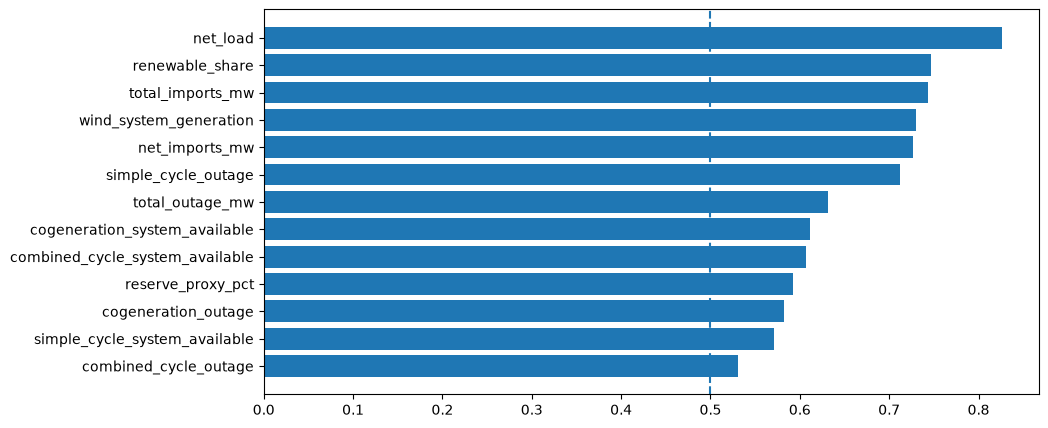

In [26]:
# ---------------------------------------------------------------------
# Visualize AUC Results
# ---------------------------------------------------------------------

plt.figure(figsize=(10,5))

plot_df = auc_df.sort_values("auc")

plt.barh(
    plot_df["feature"],
    plot_df["auc"]
)

plt.axvline(
    x=0.5,
    linestyle="--"
)

...

#### Initial Scarcity Signal

Net load emerged as the strongest individual scarcity indicator, achieving an AUC of 0.78 and outperforming outage, availability, import, and reserve-related variables. This relationship remained consistent after the dataset rebuild, suggesting that Alberta scarcity is fundamentally driven by the balance between system demand and available dispatchable supply. As net load increases, the system requires greater thermal generation and becomes increasingly vulnerable to scarcity pricing.

Renewable conditions also contained meaningful scarcity information. Renewable share outperformed individual renewable variables such as wind generation, indicating that the aggregate reduction in thermal generation requirements is more important than any single renewable technology. Imports similarly showed useful signal, likely reflecting tighter internal supply conditions, although their forecasting value requires further testing because imports may respond to scarcity rather than anticipate it.

Outage variables provided weaker signals overall, but simple-cycle outages emerged as a notable exception. Their stronger relationship with scarcity is consistent with the operational role of simple-cycle units as flexible peaking resources that become most valuable during tight system conditions. This suggests that outage impacts depend on resource type and operating context rather than outage magnitude alone.

Absolute availability measures contained less scarcity information than expected. The results indicate that available capacity is only meaningful relative to the amount of demand it must serve. This motivates the use of relative system-tightness metrics, including thermal capacity margin, availability-to-load ratios, and other supply-demand balance measures, which are examined in the following sections.

### 2.2. Different Price Regimes

In [44]:
# ------------------------------------------------------------
# Compare feature performance across different price regimes
# ------------------------------------------------------------

price_thresholds = {
    "scarcity_300": 300,
    "scarcity_500": 500,
    "scarcity_800": 800,
}


features_test = [
    "net_load",
    "renewable_share",
    "wind_system_generation",
    "simple_cycle_outage",
    "total_imports_mw",
    "reserve_proxy_pct",
]


regime_auc_results = []


for regime, threshold in price_thresholds.items():

    # define price regime
    master["price_regime"] = (
        master["pool_price"] > threshold
    ).astype(int)

    # skip if insufficient events
    if master["price_regime"].nunique() < 2:
        continue

    for feature in features_test:

        result = feature_auc(
            master,
            feature,
            target="price_regime"
        )

        result["regime"] = regime
        result["threshold"] = threshold

        regime_auc_results.append(result)


regime_auc_df = (
    pd.DataFrame(regime_auc_results)
    .sort_values(
        ["regime", "auc"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)


regime_auc_df

,feature,auc,direction,n_obs,regime,threshold
0,net_load,0.826049,positive,87665,scarcity_300,300
1,renewable_share,0.746362,negative,87665,scarcity_300,300
2,total_imports_mw,0.743332,positive,87665,scarcity_300,300
3,wind_system_generation,0.729878,negative,87665,scarcity_300,300
4,simple_cycle_outage,0.711863,positive,87665,scarcity_300,300
5,reserve_proxy_pct,0.592666,negative,87665,scarcity_300,300
6,net_load,0.850464,positive,87665,scarcity_500,500
7,renewable_share,0.771941,negative,87665,scarcity_500,500
8,total_imports_mw,0.759062,positive,87665,scarcity_500,500
9,wind_system_generation,0.755323,negative,87665,scarcity_500,500


#### Different Price Regimes

Increasing the scarcity threshold from $300/MWh to $800/MWh strengthens the relationship between most system variables and extreme price events. Net load remains the strongest standalone indicator across all price regimes, while renewable contribution becomes increasingly important as scarcity severity increases. This suggests that extreme prices are not driven by demand alone, but emerge when high residual demand coincides with reduced renewable availability and tighter dispatchable supply conditions. Imports and simple-cycle outages provide additional information, although their role appears more consistent with system balancing and secondary constraints rather than primary scarcity formation.

#### 2.3. Incrimental Drivers Beyond Net Load

In [27]:
# ------------------------------------------------------------
# Incremental drivers at high net load.
# ------------------------------------------------------------

high_netload = (
    master["net_load"] > master["net_load"].quantile(0.8)
)

high_df = master[high_netload]

scarcity = high_df[high_df["scarcity_event"] == 1]
normal = high_df[high_df["scarcity_event"] == 0]

compare_cols = [
    "renewable_share",
    "wind_system_generation",
    "total_imports_mw",
    "reserve_proxy_pct",
    "total_outage_mw",
    "simple_cycle_outage",
]

comparison = pd.DataFrame({
    "scarcity": scarcity[compare_cols].mean(),
    "non_scarcity": normal[compare_cols].mean(),
})

comparison["difference"] = (
    comparison["scarcity"] -
    comparison["non_scarcity"]
)

comparison["pct_difference"] = (
    comparison["difference"] /
    comparison["non_scarcity"]
) * 100

comparison.sort_values(
    "pct_difference",
    ascending=False
)

,scarcity,non_scarcity,difference,pct_difference
simple_cycle_outage,332.731097,208.561628,124.169469,59.536105
total_imports_mw,541.833061,353.278547,188.554513,53.372761
total_outage_mw,3605.167369,3074.814786,530.352583,17.248277
reserve_proxy_pct,0.256759,0.254455,0.002304,0.905517
wind_system_generation,244.674981,342.589832,-97.914851,-28.580781
renewable_share,0.022462,0.031830,-0.009369,-29.433125


In [28]:
# ------------------------------------------------------------
# Compare scarcity vs non-scarcity conditions within each
# generation regime, controlling for structural changes
# ------------------------------------------------------------

# Define high net load hours (top 20%)

high_netload = (
    master["net_load"] > master["net_load"].quantile(0.8)
)

high_df = master[high_netload].copy()


compare_cols = [
    "renewable_share",
    "wind_system_generation",
    "total_imports_mw",
    "net_imports_mw",
    "reserve_proxy_pct",
    "total_outage_mw",
    "simple_cycle_outage",
    "combined_cycle_outage",
    "cogeneration_outage",
]


# ------------------------------------------------------------
# Calculate scarcity vs non-scarcity differences by generation regime
# ------------------------------------------------------------

regime_comparison = []

for regime, group in high_df.groupby("generation_regime"):

    scarcity = group[group["scarcity_event"] == 1]
    normal = group[group["scarcity_event"] == 0]

    # Skip regimes without enough observations
    if len(scarcity) == 0 or len(normal) == 0:
        continue

    comparison = pd.DataFrame({
        "scarcity": scarcity[compare_cols].mean(),
        "non_scarcity": normal[compare_cols].mean(),
    })

    comparison["difference"] = (
        comparison["scarcity"] -
        comparison["non_scarcity"]
    )

    comparison["pct_difference"] = (
        comparison["difference"] /
        comparison["non_scarcity"]
    ) * 100

    comparison["generation_regime"] = regime

    comparison["scarcity_hours"] = len(scarcity)
    comparison["normal_hours"] = len(normal)

    regime_comparison.append(comparison)


# Combine regime results

regime_comparison = (
    pd.concat(regime_comparison)
    .reset_index()
    .rename(columns={"index": "feature"})
)


# Sort chronologically by regime

regime_order = [
    "coal_transition",
    "coal_exit_transition",
    "renewables_gas_flexibility",
]

regime_comparison["generation_regime"] = pd.Categorical(
    regime_comparison["generation_regime"],
    categories=regime_order,
    ordered=True
)

regime_comparison = (
    regime_comparison
    .sort_values(
        ["generation_regime", "pct_difference"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)


# Display scrollable output

from IPython.display import display, HTML

html = regime_comparison.to_html()

display(
    HTML(
        f"""
        <div style="
            max-height:500px;
            overflow:auto;
        ">
        {html}
        </div>
        """
    )
)

,feature,scarcity,non_scarcity,difference,pct_difference,generation_regime,scarcity_hours,normal_hours
0,net_imports_mw,608.601010,189.084947,419.516063,221.866452,coal_transition,198,6145
1,total_imports_mw,643.404040,258.151668,385.252372,149.234896,coal_transition,198,6145
2,simple_cycle_outage,215.239394,153.394923,61.844471,40.317157,coal_transition,198,6145
3,cogeneration_outage,1543.883838,1145.825875,398.057964,34.739830,coal_transition,198,6145
4,total_outage_mw,3763.918182,2869.941790,893.976392,31.149635,coal_transition,198,6145
5,combined_cycle_outage,403.722222,335.851261,67.870961,20.208637,coal_transition,198,6145
6,reserve_proxy_pct,0.119595,0.202531,-0.082936,-40.949922,coal_transition,198,6145
7,renewable_share,0.009859,0.024780,-0.014921,-60.214740,coal_transition,198,6145
8,wind_system_generation,103.578526,262.457445,-158.878919,-60.535116,coal_transition,198,6145
9,net_imports_mw,609.533141,391.588048,217.945093,55.656728,coal_exit_transition,694,5020


### Incremental Drivers Beyond Net Load

Grouping years by generation regime shows that scarcity drivers evolve with Alberta's changing supply mix.

During the coal transition regime (2015–2018), scarcity during high net load periods was strongly associated with import dependence and higher outages. Net imports were over 200% higher during scarcity hours, suggesting that limited local supply required greater reliance on external resources. Thermal outage effects were also strongest during this period.

During the coal exit transition (2019–2021), the same relationships remained but weakened. Imports continued to increase during scarcity hours, while outage differences became smaller. This suggests the system was becoming less dependent on individual thermal availability as the generation fleet changed.

In the renewables-gas flexibility regime (2022–2024), scarcity became increasingly linked to renewable availability. Wind generation and renewable share remained substantially lower during scarcity events, while import dependence persisted. However, total outage differences narrowed, indicating that scarcity is less about total unavailable capacity and more about the interaction between renewable variability, net load, and flexible supply.

Overall, the results suggest a shift from a thermal availability-driven scarcity mechanism toward a net-load flexibility challenge, where renewable output and balancing resources increasingly determine whether tight conditions become scarcity events.

### 2.4. Individual Feature Decile Analysis

In [40]:
# ---------------------------------------------------------------------
# Define price scarcity regimes
# ---------------------------------------------------------------------

price_thresholds = {
    "scarcity_100": 100,
    "scarcity_300": 300,
    "scarcity_500": 500
}

# ---------------------------------------------------------------------
# Features to test in decile scarcity analysis
# ---------------------------------------------------------------------

features_test = [
    "net_load",
    "renewable_share",
    "wind_system_generation",
    "total_imports_mw",
    "total_outage_mw",
    "supply_pressure_proxy_mw",
    "spark_spread",
    "ail_mw",
]

# ---------------------------------------------------------------------
# Decile analysis within generation regimes
# ---------------------------------------------------------------------

decile_results = []

for generation_regime, regime_group in master.groupby("generation_regime"):

    for price_regime, threshold in price_thresholds.items():

        event = regime_group["pool_price"] > threshold

        for feature in features_test:

            temp = regime_group[[feature]].copy()

            temp["event"] = event.astype(int)

            temp["decile"] = pd.qcut(
                temp[feature],
                q=10,
                labels=False,
                duplicates="drop"
            )

            decile_summary = (
                temp
                .groupby("decile", observed=True)
                .agg(
                    feature_value_mean=(feature, "mean"),
                    event_rate=("event", "mean"),
                    observations=("event", "count")
                )
                .reset_index()
            )

            decile_summary["feature"] = feature
            decile_summary["generation_regime"] = generation_regime
            decile_summary["price_regime"] = price_regime
            decile_summary["threshold"] = threshold

            decile_results.append(decile_summary)


decile_regime_df = pd.concat(
    decile_results,
    ignore_index=True
)

decile_regime_df.head()

,decile,feature_value_mean,event_rate,observations,feature,generation_regime,price_regime,threshold
0,0,7471.006786,0.001900,2631,net_load,coal_exit_transition,scarcity_100,100
1,1,8030.800106,0.009125,2630,net_load,coal_exit_transition,scarcity_100,100
2,2,8344.369226,0.023194,2630,net_load,coal_exit_transition,scarcity_100,100
3,3,8613.218040,0.028886,2631,net_load,coal_exit_transition,scarcity_100,100
4,4,8863.679173,0.040684,2630,net_load,coal_exit_transition,scarcity_100,100


In [42]:
from IPython.display import display, HTML

display(
    HTML(
        f"""
        <div style="
            max-height:600px;
            overflow:auto;
        ">
        {decile_regime_df.to_html(index=False)}
        </div>
        """
    )
)

decile,feature_value_mean,event_rate,observations,feature,generation_regime,price_regime,threshold
0,7471.006786,0.001900,2631,net_load,coal_exit_transition,scarcity_100,100
1,8030.800106,0.009125,2630,net_load,coal_exit_transition,scarcity_100,100
2,8344.369226,0.023194,2630,net_load,coal_exit_transition,scarcity_100,100
3,8613.218040,0.028886,2631,net_load,coal_exit_transition,scarcity_100,100
4,8863.679173,0.040684,2630,net_load,coal_exit_transition,scarcity_100,100
5,9104.523692,0.084030,2630,net_load,coal_exit_transition,scarcity_100,100
6,9344.884736,0.109464,2631,net_load,coal_exit_transition,scarcity_100,100
7,9619.648344,0.102281,2630,net_load,coal_exit_transition,scarcity_100,100
8,10003.701382,0.167681,2630,net_load,coal_exit_transition,scarcity_100,100
9,10676.191913,0.343976,2631,net_load,coal_exit_transition,scarcity_100,100


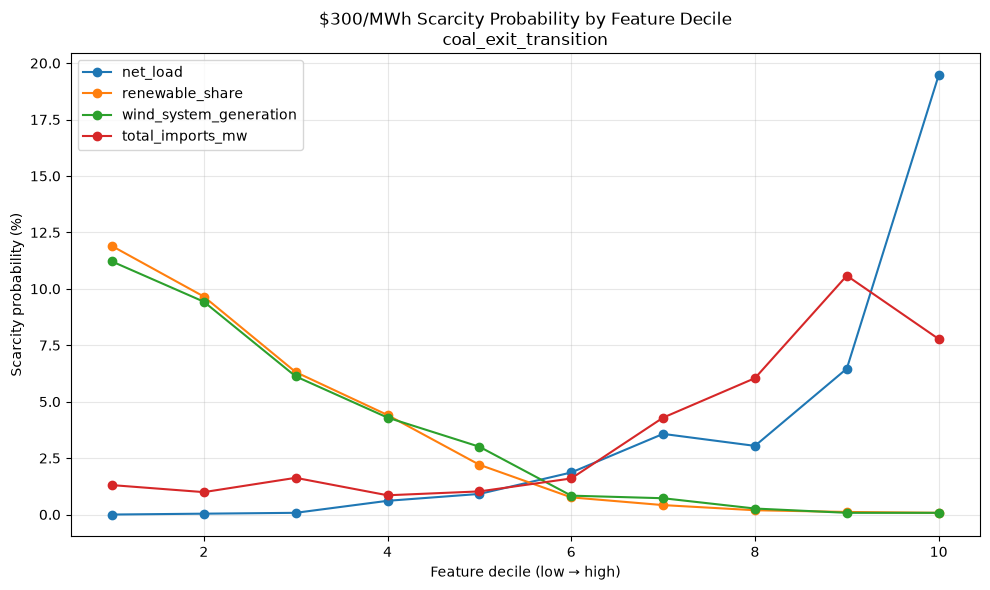

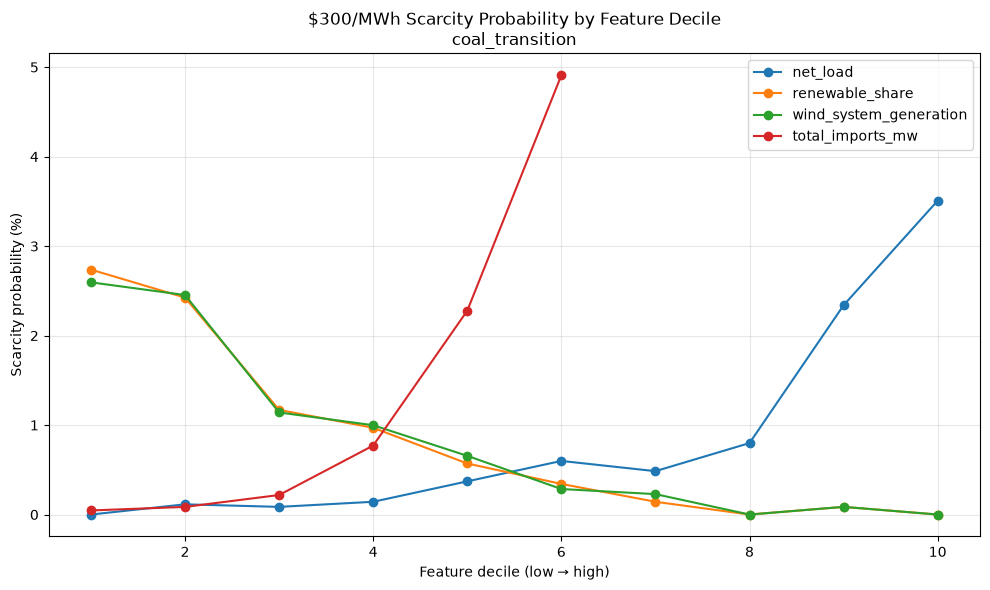

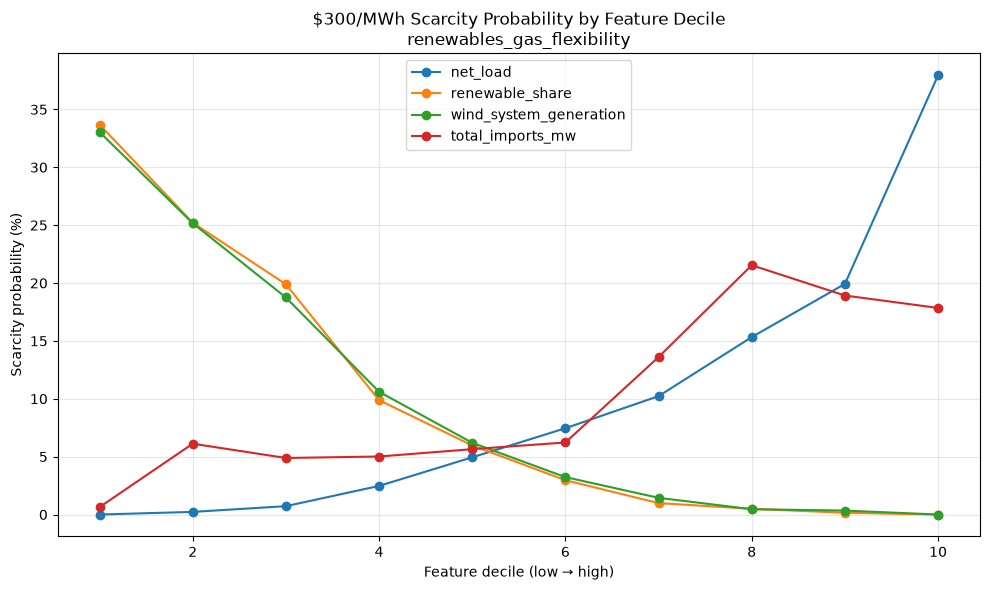

In [43]:
# ---------------------------------------------------------------------
# Plot scarcity probability by feature decile
# One chart per generation regime
# ---------------------------------------------------------------------

plot_features = [
    "net_load",
    "renewable_share",
    "wind_system_generation",
    "total_imports_mw",
]


plot_regimes = (
    decile_regime_df["generation_regime"]
    .unique()
)


for generation_regime in plot_regimes:

    plt.figure(figsize=(10,6))

    for feature in plot_features:

        plot_data = decile_regime_df[
            (decile_regime_df["generation_regime"] == generation_regime)
            &
            (decile_regime_df["price_regime"] == "scarcity_300")
            &
            (decile_regime_df["feature"] == feature)
        ]

        plt.plot(
            plot_data["decile"] + 1,
            plot_data["event_rate"] * 100,
            marker="o",
            label=feature
        )


    plt.xlabel("Feature decile (low → high)")
    plt.ylabel("Scarcity probability (%)")

    plt.title(
        f"$300/MWh Scarcity Probability by Feature Decile\n{generation_regime}"
    )

    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

#### Individual Feature Decile Analysis

The regime-conditioned decile analysis shows that the relationship between system conditions and scarcity is highly dependent on the underlying generation regime and the severity of the price event. In the coal-transition regime, scarcity events are relatively rare overall, particularly at the $300 and $500 thresholds, but several operational variables exhibit clear increases in event probability as system conditions become more stressed. Total outages show a particularly consistent upward relationship with scarcity. For the $300 threshold, the event rate rises from approximately 0.14% in the lowest outage decile to 3.63% in the highest decile, while the corresponding relationship for the $500 threshold increases from approximately 0.06% to 2.86%. This suggests that generation unavailability becomes increasingly important when the system is operating within the coal-transition regime.

The supply pressure proxy exhibits a similar pattern in the coal-transition regime. At the $300 threshold, event rates remain effectively zero through the lower deciles before increasing to 4.11% in the highest decile. At the $500 threshold, the same pattern is present, with the highest decile reaching an event rate of approximately 2.86%. This indicates that scarcity becomes substantially more likely when the system is operating with less available supply relative to demand. AIL also exhibits a positive relationship with scarcity in this regime, although the relationship is weaker than that observed for outages and the supply pressure proxy. At the $300 threshold, the event rate increases from approximately 0.14% in the lowest AIL decile to 2.17% in the highest decile.

Spark spread shows a particularly strong nonlinear relationship with scarcity in the coal-transition regime. Event rates remain effectively zero across the first nine deciles, before increasing sharply in the highest decile. For the $300 threshold, the event rate reaches 8.44% when the mean spark spread is approximately $102/MWh, compared with zero across the lower deciles. The same pattern appears for the $500 threshold, where the highest spark-spread decile has an event rate of 5.73%. This suggests that extreme fuel-to-power economics are strongly associated with scarcity conditions, although the interpretation of this variable depends on its construction and its timing relative to the forecast target.

The renewables-gas-flexibility regime exhibits a substantially different scarcity structure. Net load is one of the clearest predictors of scarcity across all three thresholds. For the $100 threshold, the event rate increases from approximately 0.04% in the lowest net-load decile to 63.57% in the highest decile. The relationship remains strong at higher thresholds, with the highest decile reaching 37.95% for $300 scarcity and 27.19% for $500 scarcity. This indicates that, within this regime, scarcity risk rises sharply as demand remaining after renewable generation increases. The relationship is strongly nonlinear, with event probabilities accelerating considerably in the upper portion of the net-load distribution.

Renewable share provides the corresponding inverse relationship. At the $100 threshold, the event rate is approximately 62.62% in the lowest renewable-share decile and falls to only 0.04% in the highest decile. The relationship remains strong for the $300 and $500 thresholds, with event rates falling from 33.69% to effectively zero for $300 scarcity and from 24.64% to zero for $500 scarcity. Wind generation shows an almost identical pattern, with low wind output associated with substantially greater scarcity risk. These results provide a coherent physical interpretation: within the renewables-gas-flexibility regime, scarcity is strongly associated with periods in which renewable generation is insufficient to offset system demand and residual net load becomes elevated.

Imports display a different and less monotonic relationship. In the renewables-gas-flexibility regime, higher imports are generally associated with higher scarcity probabilities, particularly through the middle and upper portions of the distribution. For example, at the $300 threshold, the event rate rises from 0.64% in the lowest import decile to 21.54% in the eighth decile before declining somewhat in the highest deciles. The same general pattern appears at the $100 and $500 thresholds. This should not necessarily be interpreted as evidence that imports cause scarcity. Rather, imports may be responding to underlying system stress, making them an endogenous indicator of tight market conditions. Their usefulness for forecasting therefore depends strongly on whether the import variable represents information available before the forecasted price event or information generated in response to contemporaneous market conditions.

Total outages behave differently in the renewables-gas-flexibility regime than they do in the coal-transition regime. Although outage levels are associated with substantial scarcity probabilities, the relationship is not strongly monotonic. For the $300 threshold, event rates range from approximately 6.88% to 12.79% across the outage deciles, while for the $500 threshold they range from approximately 3.88% to 7.69%. This suggests that outage magnitude alone may be less informative in this regime than the interaction between outages and other system conditions such as renewable availability, net load, and flexible generation capacity.

The supply pressure proxy also exhibits a nonlinear relationship in the renewables-gas-flexibility regime. At the $300 threshold, event rates increase from 1.78% in the lowest decile to a peak of 15.89% around the middle of the distribution before declining toward 6.85% in the highest decile. A similar inverted-U pattern appears at the $500 threshold. This indicates that the proxy is capturing a more complex system state than simple scarcity of available generation. Extremely high values may correspond to different combinations of system conditions, including high renewable output or other forms of available supply, which can reduce the probability of an extreme price event despite the nominally high value of the proxy.

Spark spread again demonstrates a highly nonlinear relationship in the renewables-gas-flexibility regime. For $300 scarcity, event rates remain at zero through most of the distribution, increase to approximately 1.48% in the ninth decile, and then reach 97.79% in the highest decile. For $500 scarcity, the highest decile still has an event rate of 59.26%, while the lower nine deciles have effectively zero events. This is one of the strongest relationships observed in the analysis and suggests that extreme gas-generation economics are closely associated with severe scarcity conditions in this regime. As with the coal-transition results, the interpretation should account for the exact construction and timing of the spark-spread variable to ensure that it does not contain information derived from the target price.

Overall, the results indicate that Alberta scarcity is not governed by a single universal relationship between system conditions and price. Instead, the importance and shape of individual predictors change substantially across generation regimes and price thresholds. The coal-transition regime is characterized more strongly by generation outages, supply tightness, demand, and extreme supply-cost conditions, while the renewables-gas-flexibility regime shows especially strong relationships between scarcity and residual net load, renewable availability, and extreme fuel-to-power economics. The increasingly steep event-rate gradients at higher levels of system stress also indicate substantial nonlinearities, supporting the use of models capable of capturing interactions and threshold effects rather than relying exclusively on linear relationships.

These results should be interpreted as conditional risk stratification rather than causal estimates. In particular, variables such as imports may be endogenous responses to system stress, while variables such as spark spread require careful examination of their construction and information availability. Nevertheless, the consistency of the observed relationships across multiple scarcity thresholds provides evidence that the regime framework is capturing meaningful differences in the physical and economic mechanisms associated with extreme Alberta power prices. The analysis therefore provides a useful foundation for subsequent predictive modeling, particularly models that explicitly allow the effects of load, renewable generation, outages, imports, and fuel economics to vary across market regimes.

> Spark Spread variable was very strong, but might also be constructured using pool price itself. We'll create a proxy spark spread from gas price variables, and see if it remains as strong.

In [50]:
# =============================================================================
# SPARK SPREAD PROXY + COMPARISON WITH ORIGINAL SPARK SPREAD
# =============================================================================

# Representative gas-generation heat rate
GAS_HEAT_RATE = 7.5  # MMBtu/MWh

# Construct spark spread using the conventional definition:
# electricity price - (gas price × heat rate)

master["spark_spread_proxy"] = (
    master["pool_price"] - (master["gas_price"] * GAS_HEAT_RATE)
)

# ---------------------------------------------------------------------
# Compare original AESO spark spread with constructed definition
# ---------------------------------------------------------------------

comparison = master[
    ["spark_spread", "spark_spread_proxy"]
].dropna().copy()

comparison["difference"] = (
    comparison["spark_spread_proxy"] - comparison["spark_spread"]
)

spark_spread_comparison = pd.DataFrame({
    "original_spark_spread": [
        comparison["spark_spread"].mean(),
        comparison["spark_spread"].std(),
        comparison["spark_spread"].min(),
        comparison["spark_spread"].max(),
    ],
    "spark_spread_proxy": [
        comparison["spark_spread_proxy"].mean(),
        comparison["spark_spread_proxy"].std(),
        comparison["spark_spread_proxy"].min(),
        comparison["spark_spread_proxy"].max(),
    ],
}, index=["mean", "std", "min", "max"])

# Add direct comparison statistics
spark_spread_comparison.loc["mean_absolute_difference"] = (
    comparison["difference"].abs().mean()
)

spark_spread_comparison.loc["correlation"] = (
    comparison["spark_spread"]
    .corr(comparison["spark_spread_proxy"])
)

display(spark_spread_comparison.round(3))

,original_spark_spread,spark_spread_proxy
mean,50.442,50.442
std,125.084,125.084
min,-56.450,-56.450
max,998.040,998.040
mean_absolute_difference,0.000,0.000
correlation,1.000,1.000


In [52]:
# =============================================================================
# EX-ANTE GAS GENERATION COST PROXY + DECILE SCARCITY TEST
# =============================================================================

# Representative gas-generation heat rate
GAS_HEAT_RATE = 7.5  # MMBtu/MWh

# Ex-ante gas generation cost proxy.
# Does not use contemporaneous pool_price, so no target leakage.
master["gas_generation_cost_proxy"] = (
    master["gas_price"] * GAS_HEAT_RATE
)

# ---------------------------------------------------------------------
# Price scarcity thresholds
# ---------------------------------------------------------------------

price_thresholds = {
    "scarcity_100": 100,
    "scarcity_300": 300,
    "scarcity_500": 500
}

# ---------------------------------------------------------------------
# Run the same decile analysis exclusively on the ex-ante proxy
# ---------------------------------------------------------------------

gas_cost_results = []

for generation_regime, regime_group in master.groupby(
    "generation_regime"
):

    for price_regime, threshold in price_thresholds.items():

        event = regime_group["pool_price"] > threshold

        temp = regime_group[
            ["gas_generation_cost_proxy"]
        ].copy()

        temp["event"] = event.astype(int)

        temp["decile"] = pd.qcut(
            temp["gas_generation_cost_proxy"],
            q=10,
            labels=False,
            duplicates="drop"
        )

        decile_summary = (
            temp
            .groupby("decile", observed=True)
            .agg(
                feature_value_mean=("gas_generation_cost_proxy", "mean"),
                event_rate=("event", "mean"),
                observations=("event", "count")
            )
            .reset_index()
        )

        decile_summary["feature"] = "gas_generation_cost_proxy"
        decile_summary["generation_regime"] = generation_regime
        decile_summary["price_regime"] = price_regime
        decile_summary["threshold"] = threshold

        gas_cost_results.append(decile_summary)

gas_generation_cost_test = pd.concat(
    gas_cost_results,
    ignore_index=True
)

from IPython.display import display, HTML

display(
    HTML(
        f"""
        <div style="
            max-height:600px;
            overflow:auto;
        ">
        {gas_generation_cost_test.to_html(index=False)}
        </div>
        """
    )
)

decile,feature_value_mean,event_rate,observations,feature,generation_regime,price_regime,threshold
0,3.079439,0.049621,2640,gas_generation_cost_proxy,coal_exit_transition,scarcity_100,100
1,11.018352,0.014394,2640,gas_generation_cost_proxy,coal_exit_transition,scarcity_100,100
2,13.810771,0.017052,2639,gas_generation_cost_proxy,coal_exit_transition,scarcity_100,100
3,15.014966,0.023318,2616,gas_generation_cost_proxy,coal_exit_transition,scarcity_100,100
4,17.019864,0.036844,2687,gas_generation_cost_proxy,coal_exit_transition,scarcity_100,100
5,18.555824,0.063456,2616,gas_generation_cost_proxy,coal_exit_transition,scarcity_100,100
6,20.061296,0.114297,2616,gas_generation_cost_proxy,coal_exit_transition,scarcity_100,100
7,22.110378,0.143731,2616,gas_generation_cost_proxy,coal_exit_transition,scarcity_100,100
8,25.815963,0.202522,2617,gas_generation_cost_proxy,coal_exit_transition,scarcity_100,100
9,34.168819,0.249140,2617,gas_generation_cost_proxy,coal_exit_transition,scarcity_100,100


#### Spark Spread Proxy

> The original spark spread used contemporaneous pool price, defined as pool price minus gas price multiplied by a representative heat rate. Because pool price is the prediction target, this feature contains target information and therefore introduces leakage. Its strong scarcity relationship should not be interpreted as evidence of genuine ex-ante predictive power.

> An ex-ante gas-generation cost proxy was therefore constructed using only gas price and a representative 7.5 MMBtu/MWh heat rate. This removes pool price from the feature and allows the relationship to be tested without target leakage. The resulting decile analysis showed substantially stronger regime-dependent behavior: gas-generation costs were strongly associated with scarcity in the coal-exit-transition and renewables-gas-flexibility regimes, while the relationship was weak and irregular during the coal-transition regime. This suggests that gas economics may provide a legitimate ex-ante scarcity signal when gas-fired generation becomes an important source of marginal system flexibility.


## Section 3 - Outages

After establishing the primary relationship between system demand, renewable output, and scarcity risk, this section examines whether generation outages provide additional information about market stress.

Outages do not necessarily create scarcity on their own. Their impact depends on when they occur, which technologies are affected, and the level of system demand at the time. The analysis therefore focuses on whether outage conditions meaningfully differentiate scarcity hours from normal operating conditions, particularly during periods of elevated net load.

### 3.1. Individual Outage Types

In [55]:
# ---------------------------------------------------------------------
# Outage comparison: scarcity vs normal hours
# ---------------------------------------------------------------------

outage_features = [
    "total_outage_mw",
    "cogeneration_outage",
    "combined_cycle_outage",
    "simple_cycle_outage",
]


scarcity = master[master["scarcity_event"] == 1]
normal = master[master["scarcity_event"] == 0]


outage_comparison = pd.DataFrame({
    "scarcity": scarcity[outage_features].mean(),
    "normal": normal[outage_features].mean(),
})


outage_comparison["difference"] = (
    outage_comparison["scarcity"]
    - outage_comparison["normal"]
)


outage_comparison["pct_difference"] = (
    outage_comparison["difference"]
    / outage_comparison["normal"]
    * 100
)


outage_comparison.sort_values(
    "pct_difference",
    ascending=False
)

,scarcity,normal,difference,pct_difference
simple_cycle_outage,370.248988,250.148374,120.100614,48.011751
total_outage_mw,3800.195758,3476.447297,323.748461,9.312624
cogeneration_outage,1481.895148,1374.739470,107.155678,7.794617
combined_cycle_outage,436.161910,454.101287,-17.939378,-3.950523


In [57]:
# ---------------------------------------------------------------------
# Generation-regime outage comparison
# ---------------------------------------------------------------------

yearly_outage_results = []

for generation_regime, regime_df in master.groupby(
    "generation_regime"
):

    scarcity = regime_df[
        regime_df["scarcity_event"] == 1
    ]

    normal = regime_df[
        regime_df["scarcity_event"] == 0
    ]

    comparison = pd.DataFrame({
        "scarcity": scarcity[outage_features].mean(),
        "normal": normal[outage_features].mean(),
    })

    comparison["difference"] = (
        comparison["scarcity"]
        - comparison["normal"]
    )

    comparison["pct_difference"] = (
        comparison["difference"]
        / comparison["normal"]
        * 100
    )

    comparison["generation_regime"] = generation_regime

    yearly_outage_results.append(
        comparison
        .reset_index()
        .rename(columns={"index": "feature"})
    )

generation_regime_outage_comparison = (
    pd.concat(
        yearly_outage_results,
        ignore_index=True
    )
    [
        [
            "generation_regime",
            "feature",
            "scarcity",
            "normal",
            "difference",
            "pct_difference",
        ]
    ]
    .sort_values(
        ["generation_regime", "pct_difference"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

display(
    generation_regime_outage_comparison
)

,generation_regime,feature,scarcity,normal,difference,pct_difference
0,coal_exit_transition,simple_cycle_outage,200.779747,185.299085,15.480662,8.354419
1,coal_exit_transition,combined_cycle_outage,271.265823,253.107272,18.158550,7.174251
2,coal_exit_transition,total_outage_mw,3561.558544,3345.304748,216.253796,6.464397
3,coal_exit_transition,cogeneration_outage,1268.291034,1308.037892,-39.746859,-3.038663
4,coal_transition,simple_cycle_outage,225.031757,182.996894,42.034863,22.970260
5,coal_transition,total_outage_mw,4041.767568,3314.406621,727.360947,21.945435
6,coal_transition,cogeneration_outage,1619.435811,1355.324235,264.111576,19.486966
7,coal_transition,combined_cycle_outage,464.020270,466.824465,-2.804195,-0.600696
8,renewables_gas_flexibility,simple_cycle_outage,448.272414,418.132554,30.139860,7.208207
9,renewables_gas_flexibility,cogeneration_outage,1543.881609,1474.638743,69.242866,4.695582


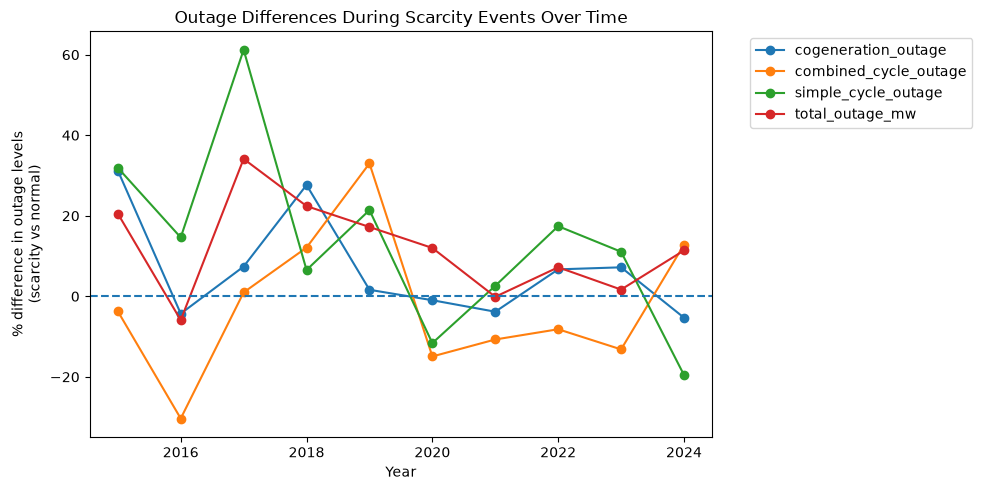

In [63]:
# ---------------------------------------------------------------------
# Outage differences over time
# ---------------------------------------------------------------------

plot_df = (
    yearly_outage_comparison
    .pivot(
        index="year_alberta",
        columns="feature",
        values="pct_difference"
    )
)

plt.figure(figsize=(10, 5))

for col in plot_df.columns:
    plt.plot(
        plot_df.index,
        plot_df[col],
        marker="o",
        label=col
    )

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Year")
plt.ylabel(
    "% difference in outage levels\n(scarcity vs normal)"
)

plt.title(
    "Outage Differences During Scarcity Events Over Time"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

#### Individual Outage Types

Outages provide some additional information about scarcity conditions, but their importance depends on the type of generation affected and the broader system state.

Simple-cycle outages show the strongest outage-related relationship. Across the full dataset, simple-cycle outages were approximately 48% higher during scarcity hours, consistent with their role as peaking resources that become most valuable during tight system conditions. However, this relationship weakens after 2020, indicating that simple-cycle availability alone does not explain modern scarcity events.

Total outages were also higher during scarcity hours, but the relationship changed over time. Earlier years showed larger differences, with total outages substantially elevated during scarcity events in 2017 and 2018. After 2020, the difference became much smaller, suggesting that aggregate outage levels are less informative than the type and timing of unavailable capacity.

Combined-cycle outages showed no consistent scarcity relationship across years. This suggests that outage volume alone does not determine scarcity risk; the impact of unavailable thermal capacity depends on system demand, renewable output, and remaining available generation.

Overall, outage results reinforce that scarcity is not caused by outages in isolation. As Alberta's generation fleet evolved, the relationship shifted from broad reductions in available generation toward a more complex interaction between demand, renewable conditions, thermal availability, and system margins.

### 2.2. Outages Relative to System Demand

In [ ]:
# ---------------------------------------------------------------------
# Outage composition: scarcity vs normal hours
# ---------------------------------------------------------------------

outage_mix_features = [
    "total_outage_mw",
    "thermal_outage_mw",
    "renewable_outage_mw",
    "storage_outage_mw",
]


outage_mix_comparison = pd.DataFrame({
    "scarcity": scarcity[outage_mix_features].mean(),
    "normal": normal[outage_mix_features].mean(),
})


outage_mix_comparison["difference"] = (
    outage_mix_comparison["scarcity"]
    - outage_mix_comparison["normal"]
)


outage_mix_comparison["pct_difference"] = (
    outage_mix_comparison["difference"]
    / outage_mix_comparison["normal"]
    * 100
)


outage_mix_comparison.sort_values(
    "pct_difference",
    ascending=False
)

,scarcity,normal,difference,pct_difference
storage_outage_mw,21.283988,9.236011,12.047977,130.445678
renewable_outage_mw,1376.942749,976.829989,400.112760,40.960327
total_outage_mw,4844.743656,4349.531906,495.211750,11.385403
thermal_outage_mw,3446.516918,3363.465906,83.051013,2.469209


In [ ]:
# ---------------------------------------------------------------------
# Year-over-year outage scarcity signal
# ---------------------------------------------------------------------

outage_impact_features = [
    "thermal_outage_mw",
    "renewable_outage_mw",
]


outage_impact_by_year = []


for year, group in master.groupby("year_alberta"):

    scarcity_year = group[group["scarcity_event"] == 1]
    normal_year = group[group["scarcity_event"] == 0]

    for feature in outage_impact_features:

        scarcity_mean = scarcity_year[feature].mean()
        normal_mean = normal_year[feature].mean()

        pct_difference = (
            (scarcity_mean - normal_mean)
            / normal_mean
            * 100
        )

        outage_impact_by_year.append({
            "year_alberta": year,
            "feature": feature,
            "pct_difference": pct_difference,
        })


outage_impact_by_year = pd.DataFrame(
    outage_impact_by_year
)


display(
    outage_impact_by_year
)

,year_alberta,feature,pct_difference
0,2015,thermal_outage_mw,23.071996
1,2015,renewable_outage_mw,-12.345600
2,2016,thermal_outage_mw,-6.606755
3,2016,renewable_outage_mw,5.954536
4,2017,thermal_outage_mw,35.511895
5,2017,renewable_outage_mw,13.800214
6,2018,thermal_outage_mw,25.481962
7,2018,renewable_outage_mw,-25.488850
8,2019,thermal_outage_mw,18.609893
9,2019,renewable_outage_mw,-0.943413


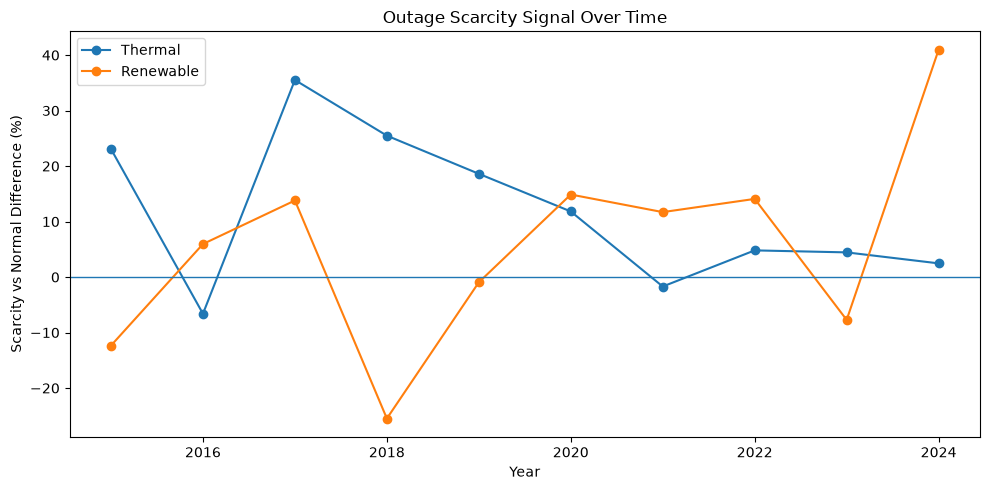

In [ ]:
# ---------------------------------------------------------------------
# Outage scarcity signal over time
# ---------------------------------------------------------------------

plt.figure(figsize=(10, 5))


for feature in outage_impact_features:

    plot_data = outage_impact_by_year[
        outage_impact_by_year["feature"] == feature
    ]

    label = (
        feature
        .replace("_outage_mw", "")
        .replace("_", " ")
        .title()
    )

    plt.plot(
        plot_data["year_alberta"],
        plot_data["pct_difference"],
        marker="o",
        label=label
    )


plt.axhline(
    0,
    linewidth=1
)


plt.xlabel("Year")
plt.ylabel(
    "Scarcity vs Normal Difference (%)"
)

plt.title(
    "Outage Scarcity Signal Over Time"
)


plt.legend()

plt.tight_layout()
plt.show()

In [67]:
# ---------------------------------------------------------------------
# Outages relative to system demand: yearly AUC test
# ---------------------------------------------------------------------

outage_demand_features = [
    "thermal_outage_share",
    "renewable_outage_share",
    "total_outage_share",
]

yearly_outage_demand_auc = []

for year, year_df in master.groupby("year_alberta"):

    for feature in outage_demand_features:

        temp = year_df[[feature, "scarcity_event"]].dropna()

        # AUC requires both scarcity and normal observations
        if temp["scarcity_event"].nunique() < 2:
            continue

        auc = roc_auc_score(
            temp["scarcity_event"],
            temp[feature]
        )

        # Orient so larger outage burden = larger scarcity signal
        if auc < 0.5:
            direction = "negative"
            auc_display = 1 - auc
        else:
            direction = "positive"
            auc_display = auc

        yearly_outage_demand_auc.append({
            "year_alberta": year,
            "feature": feature,
            "auc": auc_display,
            "direction": direction,
            "n_obs": len(temp),
        })

yearly_outage_demand_auc = (
    pd.DataFrame(yearly_outage_demand_auc)
    .sort_values(
        ["year_alberta", "auc"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

display(yearly_outage_demand_auc)

,year_alberta,feature,auc,direction,n_obs
0,2015,thermal_outage_share,0.679269,positive,8753
1,2015,total_outage_share,0.665619,positive,8753
2,2015,renewable_outage_share,0.642745,negative,8753
3,2016,total_outage_share,0.701167,negative,8784
4,2016,thermal_outage_share,0.696697,negative,8784
5,2016,renewable_outage_share,0.623149,negative,8784
6,2017,thermal_outage_share,0.772306,positive,8760
7,2017,total_outage_share,0.761188,positive,8760
8,2017,renewable_outage_share,0.541771,positive,8760
9,2018,renewable_outage_share,0.717821,negative,8760


#### Outages Relative to System Demand

Outage impacts depend on the type of capacity affected and the broader operating conditions of the system. While total outages were only moderately higher during scarcity hours, the composition and scale of unavailable generation provide additional insight into scarcity formation.

Renewable outages showed the strongest relative difference, with renewable unavailable capacity approximately 41% higher during scarcity events. However, this relationship is not consistent across the historical period, with renewable outage differences varying substantially by year. The demand-normalized AUC results similarly show a relatively unstable relationship, although renewable outage share becomes more informative in some of the later years. This suggests that renewable outages are not a direct standalone driver of scarcity, but become more consequential as renewable penetration increases and their availability represents a larger component of effective supply.

Thermal outages showed a smaller overall difference, with thermal unavailable capacity approximately 2.5% higher during scarcity hours. However, the year-by-year and demand-normalized results reveal a substantially stronger relationship in the earlier period, particularly around 2017–2019. Thermal and total outage shares reached AUCs above 0.70 in several of these years, demonstrating that the relationship was not simply caused by higher demand during scarcity hours. After 2020, this signal weakens considerably, with demand-normalized outage AUCs generally moving much closer to 0.50–0.60.

Storage outages showed the largest percentage difference, but the absolute magnitude was small due to the limited storage capacity in the dataset. Storage availability may become increasingly relevant as storage penetration grows, but it currently represents a secondary scarcity factor.

Overall, the outage analysis suggests that scarcity relevance depends not only on how much capacity is unavailable, but on what type of capacity is unavailable, how large that outage is relative to system demand, and the broader generation regime. Earlier scarcity events show a clearer relationship with thermal capacity outages, while that relationship weakens in the modern system as renewable penetration and system flexibility change the sources of scarcity risk. Outages therefore appear to be an important component of system tightness rather than a universal standalone cause of scarcity.


### 2.3. Outage Ramps

In [ ]:
# ---------------------------------------------------------------------
# Outage ramp features
# ---------------------------------------------------------------------

outage_types = {
    "total_outage_mw": "total",
    "simple_cycle_outage": "simple_cycle",
    "combined_cycle_outage": "combined_cycle",
    "cogeneration_outage": "cogeneration",
}

ramp_horizons = [1, 3, 6, 24]

outage_ramps = pd.DataFrame(index=master.index)

for outage_col, outage_name in outage_types.items():
    for horizon in ramp_horizons:
        outage_ramps[f"{outage_name}_outage_change_{horizon}h"] = (
            master[outage_col]
            - master[outage_col].shift(horizon)
        )

outage_ramps["scarcity_event"] = master["scarcity_event"]

In [ ]:
# ---------------------------------------------------------------------
# Scarcity vs normal outage ramps
# ---------------------------------------------------------------------

outage_ramp_features = [
    col for col in outage_ramps.columns
    if col != "scarcity_event"
]

ramp_comparison = pd.DataFrame({
    "scarcity": outage_ramps.loc[
        outage_ramps["scarcity_event"] == 1,
        outage_ramp_features
    ].mean(),

    "normal": outage_ramps.loc[
        outage_ramps["scarcity_event"] == 0,
        outage_ramp_features
    ].mean(),
})

ramp_comparison["difference"] = (
    ramp_comparison["scarcity"]
    - ramp_comparison["normal"]
)

ramp_comparison.sort_values(
    "difference",
    ascending=False
)

,scarcity,normal,difference
total_outage_change_24h,90.647379,-4.031253,94.678632
total_outage_change_6h,40.507784,-1.835719,42.343503
cogeneration_outage_change_6h,23.958485,-1.106352,25.064836
total_outage_change_3h,16.896731,-0.764136,17.660867
cogeneration_outage_change_24h,10.883757,-0.507181,11.390938
combined_cycle_outage_change_6h,7.147639,-0.348237,7.495876
cogeneration_outage_change_3h,6.408147,-0.297118,6.705266
combined_cycle_outage_change_24h,5.936949,-0.351081,6.288029
combined_cycle_outage_change_3h,3.192787,-0.156465,3.349251
simple_cycle_outage_change_3h,1.405034,-0.064777,1.469810


In [ ]:
# ---------------------------------------------------------------------
# Outage ramp AUC ranking
# ---------------------------------------------------------------------

outage_ramp_auc = []

for feature in outage_ramp_features:
    outage_ramp_auc.append(
        feature_auc(
            outage_ramps,
            feature
        )
    )

outage_ramp_auc_df = (
    pd.DataFrame(outage_ramp_auc)
    .sort_values(
        "auc",
        ascending=False
    )
    .reset_index(drop=True)
)

outage_ramp_auc_df

,feature,auc,direction,n_obs
0,cogeneration_outage_change_6h,0.598373,positive,87659
1,total_outage_change_24h,0.571110,positive,87641
2,combined_cycle_outage_change_6h,0.549782,positive,87659
3,total_outage_change_6h,0.545884,positive,87659
4,cogeneration_outage_change_3h,0.537622,positive,87662
5,cogeneration_outage_change_24h,0.529131,positive,87641
6,combined_cycle_outage_change_3h,0.520677,positive,87662
7,total_outage_change_3h,0.516639,positive,87662
8,total_outage_change_1h,0.513084,negative,87664
9,simple_cycle_outage_change_3h,0.510205,positive,87662


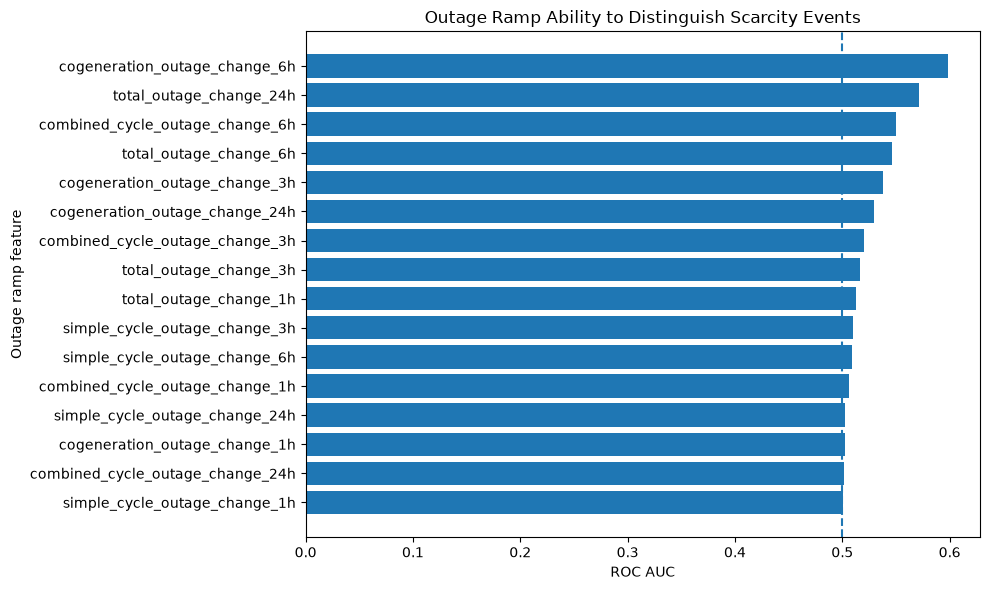

In [ ]:
# ---------------------------------------------------------------------
# Outage ramp signal ranking
# ---------------------------------------------------------------------

plot_df = (
    outage_ramp_auc_df
    .sort_values("auc")
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["feature"],
    plot_df["auc"]
)

plt.axvline(
    0.5,
    linestyle="--"
)

plt.xlabel("ROC AUC")
plt.ylabel("Outage ramp feature")
plt.title("Outage Ramp Ability to Distinguish Scarcity Events")

plt.tight_layout()
plt.show()

#### Outage Ramps

Outage levels and outage dynamics contain different information. Raw outage levels generally provide stronger descriptive differences, particularly for simple-cycle and renewable outages. However, changes in outage levels over several hours provide additional information about emerging scarcity conditions. The strongest ramp signal was the six-hour change in cogeneration outages (AUC ≈ 0.60), followed by the 24-hour change in total outages (AUC ≈ 0.57). In contrast, one-hour outage changes were almost indistinguishable from random discrimination. This suggests that rapidly changing outages at very short horizons are not particularly informative, while accumulating deterioration in generation availability over several hours may provide a modest early indication of system stress.

### 2.4. Outage Deciles

In [75]:
# ---------------------------------------------------------------------
# Outage deciles within generation regimes
# ---------------------------------------------------------------------

outage_decile_features = [
    "thermal_outage_mw",
    "total_outage_mw",
    "renewable_outage_mw",
    "simple_cycle_outage",
    "cogeneration_outage",
    "combined_cycle_outage",
]

price_thresholds = {
    "scarcity_300": 300,
    "scarcity_500": 500,
    "scarcity_800": 800,
}

outage_decile_results = []

for generation_regime, regime_group in master.groupby(
    "generation_regime"
):

    for price_regime, threshold in price_thresholds.items():

        event = regime_group["pool_price"] > threshold

        for feature in outage_decile_features:

            temp = regime_group[[feature]].copy()

            temp["event"] = event.astype(int)

            temp = temp.dropna(subset=[feature])

            temp["decile"] = pd.qcut(
                temp[feature],
                q=10,
                labels=False,
                duplicates="drop"
            )

            decile_summary = (
                temp
                .groupby("decile", observed=True)
                .agg(
                    feature_value_mean=(feature, "mean"),
                    event_rate=("event", "mean"),
                    observations=("event", "count")
                )
                .reset_index()
            )

            decile_summary["feature"] = feature
            decile_summary["generation_regime"] = generation_regime
            decile_summary["price_regime"] = price_regime
            decile_summary["threshold"] = threshold

            outage_decile_results.append(decile_summary)

outage_decile_df = (
    pd.concat(
        outage_decile_results,
        ignore_index=True
    )
    .sort_values(
        ["feature", "generation_regime", "threshold", "decile"]
    )
    .reset_index(drop=True)
)

display(
    HTML(
        f"""
        <div style="
            max-height:600px;
            overflow:auto;
        ">
        {outage_decile_df.to_html(index=False)}
        </div>
        """
    )
)

decile,feature_value_mean,event_rate,observations,feature,generation_regime,price_regime,threshold
0,800.231177,0.077563,2643,cogeneration_outage,coal_exit_transition,scarcity_300,300
1,949.294709,0.030453,2627,cogeneration_outage,coal_exit_transition,scarcity_300,300
2,1057.976820,0.036599,2623,cogeneration_outage,coal_exit_transition,scarcity_300,300
3,1178.248699,0.027160,2651,cogeneration_outage,coal_exit_transition,scarcity_300,300
4,1278.089506,0.017490,2630,cogeneration_outage,coal_exit_transition,scarcity_300,300
5,1356.113032,0.022997,2609,cogeneration_outage,coal_exit_transition,scarcity_300,300
6,1432.289977,0.022399,2634,cogeneration_outage,coal_exit_transition,scarcity_300,300
7,1524.705583,0.033042,2633,cogeneration_outage,coal_exit_transition,scarcity_300,300
8,1643.399848,0.048780,2624,cogeneration_outage,coal_exit_transition,scarcity_300,300
9,1848.887034,0.043726,2630,cogeneration_outage,coal_exit_transition,scarcity_300,300


Using DataFrame: decile_regime_df
Shape: (708, 8)
Features available: ['net_load', 'renewable_share', 'wind_system_generation', 'total_imports_mw', 'total_outage_mw', 'supply_pressure_proxy_mw', 'spark_spread', 'ail_mw']
Thresholds available: [np.int64(100), np.int64(300), np.int64(500)]
Regimes available: ['coal_exit_transition', 'coal_transition', 'renewables_gas_flexibility']

Actually available for plotting:
Features: ['total_outage_mw']
Thresholds: [300, 500]


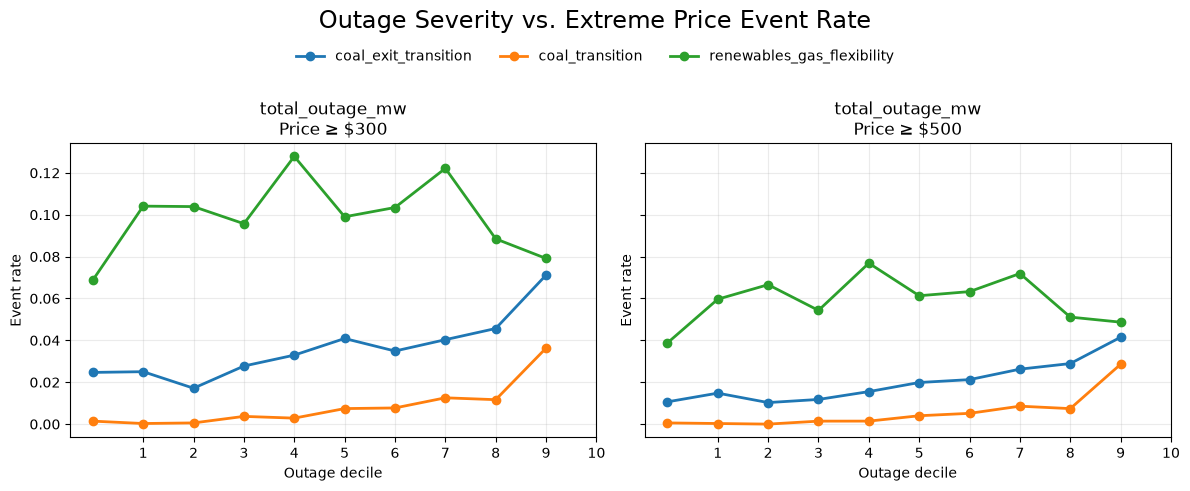

In [93]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Find the actual decile-results DataFrame
# ============================================================

required_cols = {
    "decile",
    "event_rate",
    "feature",
    "generation_regime",
    "threshold",
}

candidates = []

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        if required_cols.issubset(obj.columns):
            candidates.append((name, obj))

if not candidates:
    raise ValueError("Could not find a decile-results DataFrame.")

# Use the largest matching dataframe
name, df = max(candidates, key=lambda x: len(x[1]))

plot_df = df.copy()

print(f"Using DataFrame: {name}")
print(f"Shape: {plot_df.shape}")
print(f"Features available: {plot_df['feature'].unique().tolist()}")
print(f"Thresholds available: {sorted(plot_df['threshold'].unique())}")
print(f"Regimes available: {plot_df['generation_regime'].unique().tolist()}")

# ============================================================
# Requested features / thresholds
# Only plot combinations that actually exist
# ============================================================

requested_features = [
    "total_outage_mw",
    "thermal_outage_mw",
    "simple_cycle_outage",
]

requested_thresholds = [300, 500, 800]

available_features = [
    f for f in requested_features
    if f in plot_df["feature"].astype(str).unique()
]

available_thresholds = [
    t for t in requested_thresholds
    if t in pd.to_numeric(plot_df["threshold"], errors="coerce").unique()
]

print("\nActually available for plotting:")
print("Features:", available_features)
print("Thresholds:", available_thresholds)

if not available_features or not available_thresholds:
    raise ValueError(
        "None of the requested feature/threshold combinations exist "
        "in the current decile-results table."
    )

# ============================================================
# Clean numeric columns
# ============================================================

plot_df["decile"] = pd.to_numeric(plot_df["decile"], errors="coerce")
plot_df["event_rate"] = pd.to_numeric(plot_df["event_rate"], errors="coerce")
plot_df["threshold"] = pd.to_numeric(plot_df["threshold"], errors="coerce")

plot_df = plot_df[
    plot_df["feature"].isin(available_features)
    & plot_df["threshold"].isin(available_thresholds)
].copy()

# ============================================================
# ONE figure
# rows = features
# columns = thresholds
# lines = generation regimes
# ============================================================

fig, axes = plt.subplots(
    len(available_features),
    len(available_thresholds),
    figsize=(
        6 * len(available_thresholds),
        4.5 * len(available_features)
    ),
    squeeze=False,
    sharex=True,
    sharey=True
)

regimes = sorted(plot_df["generation_regime"].dropna().unique())

for i, feature in enumerate(available_features):

    for j, threshold in enumerate(available_thresholds):

        ax = axes[i, j]

        panel = plot_df[
            (plot_df["feature"] == feature)
            & (plot_df["threshold"] == threshold)
        ].copy()

        for regime in regimes:

            line = (
                panel[panel["generation_regime"] == regime]
                .sort_values("decile")
            )

            if not line.empty:
                ax.plot(
                    line["decile"],
                    line["event_rate"],
                    marker="o",
                    linewidth=2,
                    label=regime
                )

        ax.set_title(
            f"{feature}\nPrice ≥ ${threshold}"
        )

        ax.set_xticks(range(1, 11))
        ax.set_xlabel("Outage decile")
        ax.set_ylabel("Event rate")
        ax.grid(True, alpha=0.25)

# ============================================================
# One shared legend
# ============================================================

handles, labels = axes[0, 0].get_legend_handles_labels()

if handles:
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=min(3, len(labels)),
        frameon=False
    )

fig.suptitle(
    "Outage Severity vs. Extreme Price Event Rate",
    fontsize=17,
    y=1.08
)

plt.tight_layout()
plt.show()

Rows available: 270
Features: <ArrowStringArray>
['simple_cycle_outage', 'thermal_outage_mw', 'total_outage_mw']
Length: 3, dtype: str
Thresholds: [np.int64(300), np.int64(500), np.int64(800)]
Regimes: <ArrowStringArray>
['coal_exit_transition', 'coal_transition', 'renewables_gas_flexibility']
Length: 3, dtype: str


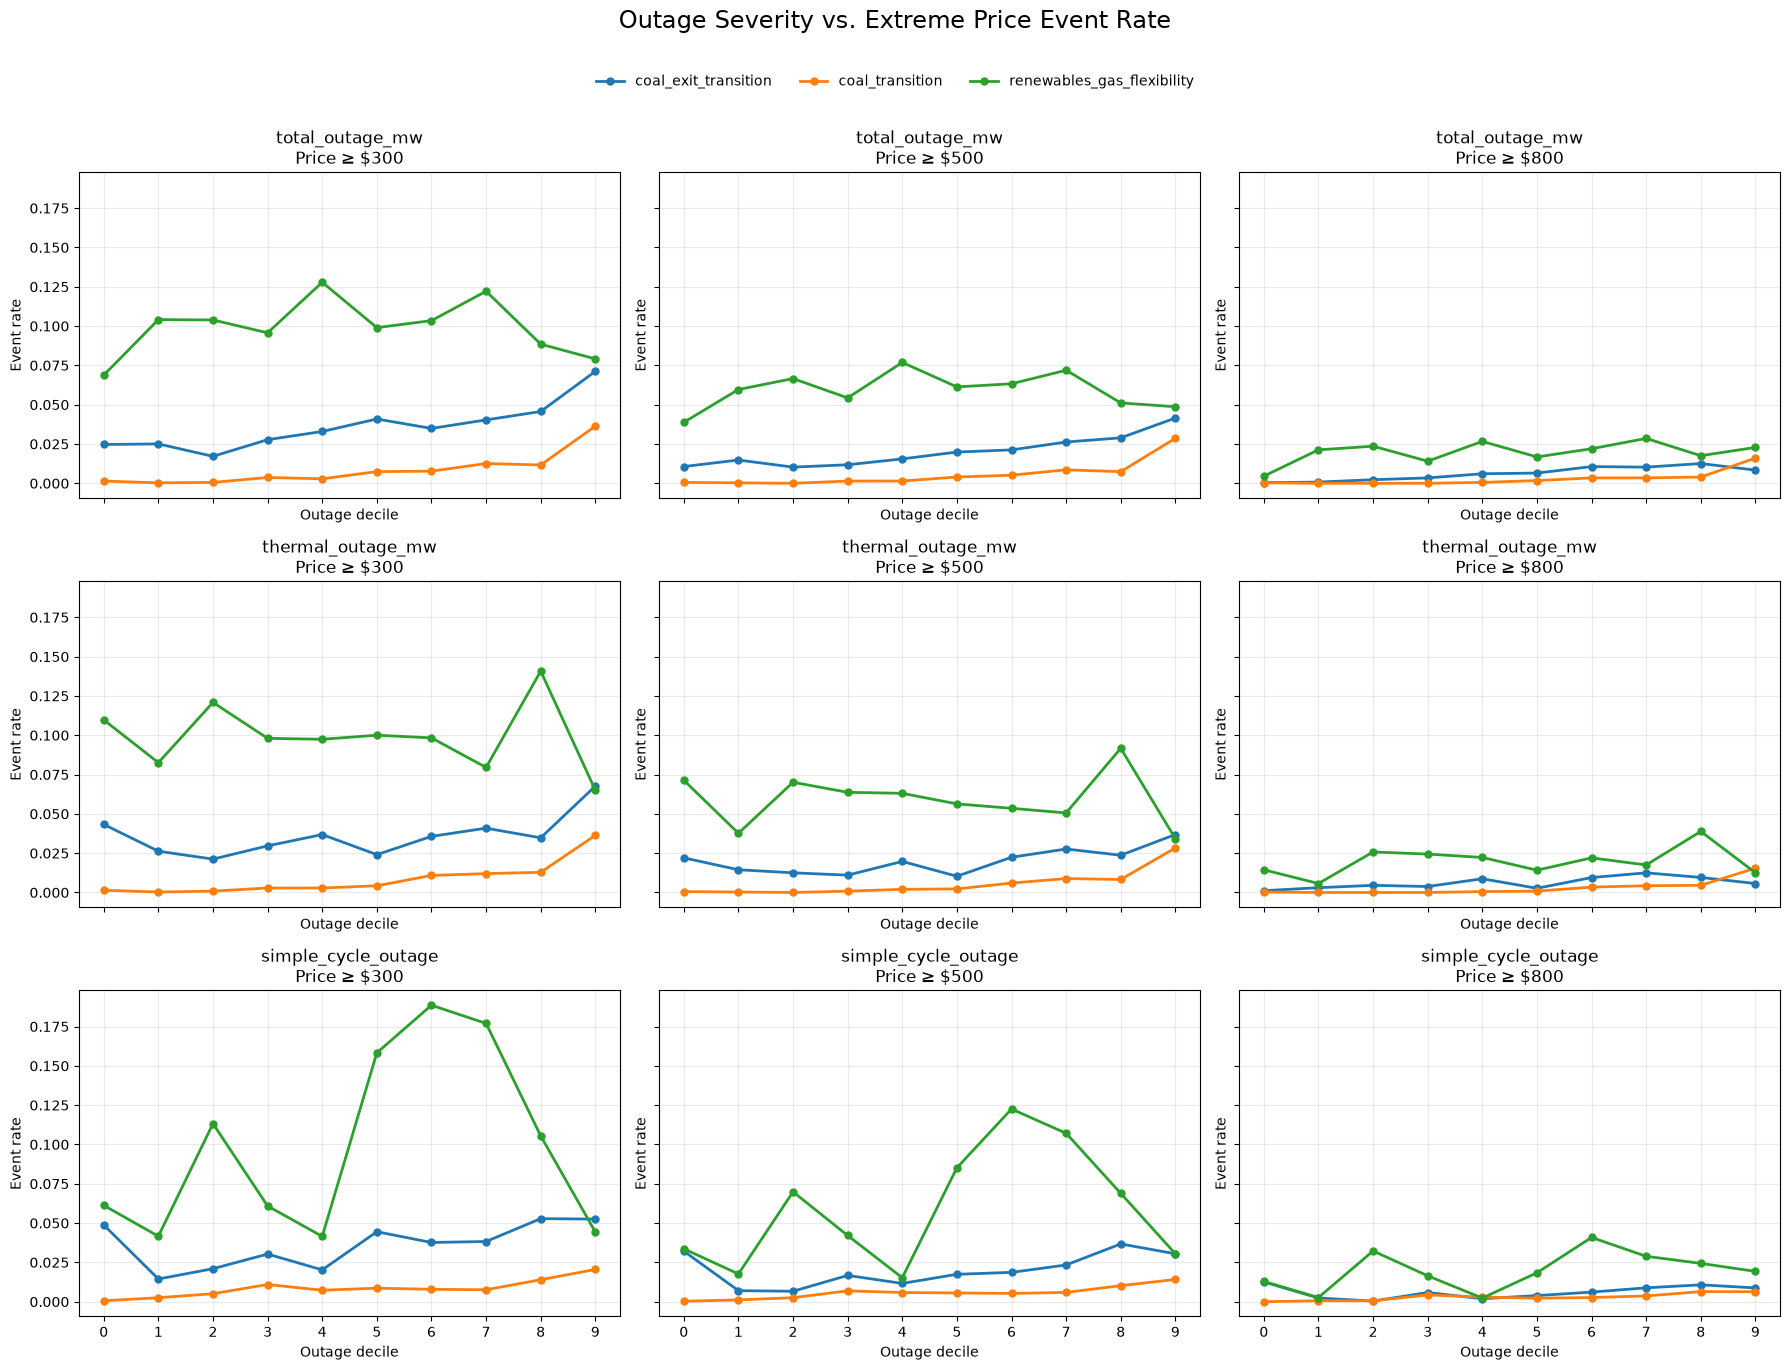

In [100]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Requested visualization
# ============================================================

plot_features = [
    "total_outage_mw",
    "thermal_outage_mw",
    "simple_cycle_outage",
]

plot_thresholds = [300, 500, 800]

# Use the dataframe created directly above
plot_df = outage_decile_df.copy()

# ------------------------------------------------------------
# Clean types
# ------------------------------------------------------------

plot_df["decile"] = pd.to_numeric(
    plot_df["decile"], errors="coerce"
)

plot_df["threshold"] = pd.to_numeric(
    plot_df["threshold"], errors="coerce"
)

plot_df["event_rate"] = pd.to_numeric(
    plot_df["event_rate"], errors="coerce"
)

plot_df["feature"] = plot_df["feature"].astype(str)
plot_df["generation_regime"] = plot_df["generation_regime"].astype(str)

# ------------------------------------------------------------
# Keep only requested combinations
# ------------------------------------------------------------

plot_df = plot_df[
    plot_df["feature"].isin(plot_features)
    & plot_df["threshold"].isin(plot_thresholds)
].copy()

print("Rows available:", len(plot_df))
print("Features:", plot_df["feature"].unique())
print("Thresholds:", sorted(plot_df["threshold"].unique()))
print("Regimes:", plot_df["generation_regime"].unique())

# ------------------------------------------------------------
# Create ONE 3 × 3 figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(18, 13),
    sharex=True,
    sharey=True
)

regimes = [
    "coal_exit_transition",
    "coal_transition",
    "renewables_gas_flexibility",
]

for row, feature in enumerate(plot_features):

    for col, threshold in enumerate(plot_thresholds):

        ax = axes[row, col]

        panel = plot_df[
            (plot_df["feature"] == feature)
            & (plot_df["threshold"] == threshold)
        ].copy()

        for regime in regimes:

            line = panel[
                panel["generation_regime"] == regime
            ].sort_values("decile")

            if not line.empty:
                ax.plot(
                    line["decile"],
                    line["event_rate"],
                    marker="o",
                    linewidth=2,
                    markersize=5,
                    label=regime
                )

        ax.set_title(
            f"{feature}\nPrice ≥ ${threshold}"
        )

        ax.set_xlabel("Outage decile")
        ax.set_ylabel("Event rate")

        ax.set_xticks(range(10))

        ax.grid(
            True,
            alpha=0.25
        )

# ------------------------------------------------------------
# Shared legend
# ------------------------------------------------------------

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=3,
    frameon=False
)

fig.suptitle(
    "Outage Severity vs. Extreme Price Event Rate",
    fontsize=17,
    y=1.05
)

plt.tight_layout()
plt.show()

#### Outage Deciles

The decile analysis reveals a strong interaction between outage magnitude, generation regime, and the severity of the price event. Across the three outage-related features examined, the relationship between outage magnitude and scarcity is substantially stronger in the renewables/gas-flexibility regime than in the coal-transition regimes. This suggests that the same physical outage burden can have very different market consequences depending on the composition and flexibility of the generation fleet.

Total outage burden

Total_outage_mw shows the clearest and most consistent relationship with extreme-price risk. In the renewables/gas-flexibility regime, event rates remain elevated across essentially the entire outage distribution. For the $300/MWh threshold, event rates are approximately 7–13% across deciles, while even the $800/MWh threshold reaches roughly 2–3% in the upper portion of the outage distribution.

The relationship is particularly notable at the upper end of the outage distribution. The highest outage decile reaches approximately 5,455 MW, compared with about 2,610 MW in the lowest decile. Although event rates do not increase monotonically across every decile, scarcity risk remains structurally high throughout the distribution.

By comparison, the coal-transition regime shows much lower event rates. Its $300/MWh event rate rises from roughly 0.1% in the lower deciles to approximately 3.6% in the highest decile, while the corresponding $800/MWh event rate rises from essentially zero to about 1.6%. The coal-exit-transition regime generally sits between these extremes, with the upper outage deciles associated with materially higher scarcity rates, particularly at the $300/MWh threshold.

Thermal outage magnitude

Thermal_outage_mw produces a similar regime-dependent pattern. Within the renewables/gas-flexibility regime, thermal outage magnitude is associated with consistently high event rates. The $300/MWh event rate remains around 8–14% across much of the outage distribution, while the $800/MWh rate reaches almost 4% in the ninth decile.

The coal-transition regime again exhibits a substantially weaker relationship. Its $300/MWh event rate increases from effectively zero in the lower deciles to approximately 3.6% in the highest decile. This indicates that thermal outages are associated with greater scarcity risk, but their market consequences are strongly conditioned by the surrounding generation system.

Simple-cycle outage

Simple_cycle_outage shows the most interesting nonlinear behavior. In the renewables/gas-flexibility regime, event rates are already elevated at relatively modest outage levels and become particularly high through the middle and upper portion of the distribution. For example, the $300/MWh event rate reaches approximately 19% around the seventh decile, with similarly elevated rates in adjacent deciles.

This pattern differs substantially from the coal-transition regimes, where simple-cycle outage event rates remain comparatively low and only rise meaningfully toward the upper outage deciles. The magnitude of the difference suggests that simple-cycle availability may be particularly important to scarcity risk under the renewables/gas-flexibility configuration.

One possible interpretation is that this pattern is consistent with greater reliance on flexible gas generation to balance variability in a system with a larger renewable share. Under that configuration, losing simple-cycle capacity may have a larger marginal effect on the system's ability to respond to tight supply conditions. However, the decile analysis is observational, so this should be interpreted as a mechanism consistent with the results rather than as a causal conclusion.

Threshold effects

The three scarcity thresholds reveal a clear severity gradient. Moving from $300/MWh to $500/MWh and then to $800/MWh progressively reduces event rates, but the underlying differences between generation regimes remain visible. The renewables/gas-flexibility regime continues to exhibit substantially greater exposure to extreme events, particularly for large outage burdens.

This suggests that outage variables are not simply proxies for a generic increase in price. Their relationship with the tail of the price distribution depends strongly on the generation regime and on how extreme the price event is.

Key interpretation

The central result is therefore not simply that more outages lead to a higher probability of scarcity. Rather, the market consequence of outages depends on what generation system is available to absorb the loss of capacity.

In the coal-transition regimes, relatively large outage burdens can often be associated with comparatively low extreme-price event rates, although the risk increases at the highest outage deciles. In the renewables/gas-flexibility regime, the same broad class of outage conditions is associated with substantially greater scarcity risk.

The results therefore provide evidence of an important interaction between physical availability and structural generation composition. Outage magnitude should be interpreted jointly with generation regime rather than treated as a universally stable predictor of scarcity. The decile plots make this interaction visible by showing how the relationship between outage severity and extreme-price event rates changes across both generation configurations and price thresholds.

### 2.5. Outage Type Comparison

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Outage types to compare
# ------------------------------------------------------------

outage_type_features = [
    "total_outage_mw",
    "thermal_outage_mw",
    "renewable_outage_mw",
    "simple_cycle_outage",
]

thresholds = [300, 500, 800]

# ------------------------------------------------------------
# Build decile summaries within generation regime
# ------------------------------------------------------------

comparison_rows = []

for regime, regime_df in master.groupby("generation_regime"):

    for feature in outage_type_features:

        if feature not in regime_df.columns:
            continue

        temp = regime_df[[feature, "pool_price"]].dropna().copy()

        if len(temp) < 20:
            continue

        # Deciles based on outage magnitude within regime
        temp["decile"] = pd.qcut(
            temp[feature],
            q=10,
            labels=False,
            duplicates="drop"
        )

        for threshold in thresholds:

            temp["event"] = (
                temp["pool_price"] > threshold
            ).astype(int)

            summary = (
                temp
                .groupby("decile", observed=True)
                .agg(
                    feature_value_mean=(feature, "mean"),
                    event_rate=("event", "mean"),
                    observations=("event", "count")
                )
                .reset_index()
            )

            summary["feature"] = feature
            summary["generation_regime"] = regime
            summary["threshold"] = threshold

            comparison_rows.append(summary)

outage_type_df = (
    pd.concat(comparison_rows, ignore_index=True)
    .sort_values(
        ["feature", "generation_regime", "threshold", "decile"]
    )
    .reset_index(drop=True)
)

display(outage_type_df.head(20))
print("Rows:", len(outage_type_df))

,decile,feature_value_mean,event_rate,observations,feature,generation_regime,threshold
0,0,101.951049,0.014243,2668,renewable_outage_mw,coal_exit_transition,300
1,1,158.998610,0.026335,2734,renewable_outage_mw,coal_exit_transition,300
2,2,199.461893,0.021480,2514,renewable_outage_mw,coal_exit_transition,300
3,3,219.244507,0.018120,2649,renewable_outage_mw,coal_exit_transition,300
4,4,244.713753,0.028045,2603,renewable_outage_mw,coal_exit_transition,300
5,5,282.049068,0.030574,2682,renewable_outage_mw,coal_exit_transition,300
6,6,327.912316,0.034857,2582,renewable_outage_mw,coal_exit_transition,300
7,7,379.660347,0.045609,2653,renewable_outage_mw,coal_exit_transition,300
8,8,449.026054,0.071264,2610,renewable_outage_mw,coal_exit_transition,300
9,9,603.166616,0.070525,2609,renewable_outage_mw,coal_exit_transition,300


Rows: 360


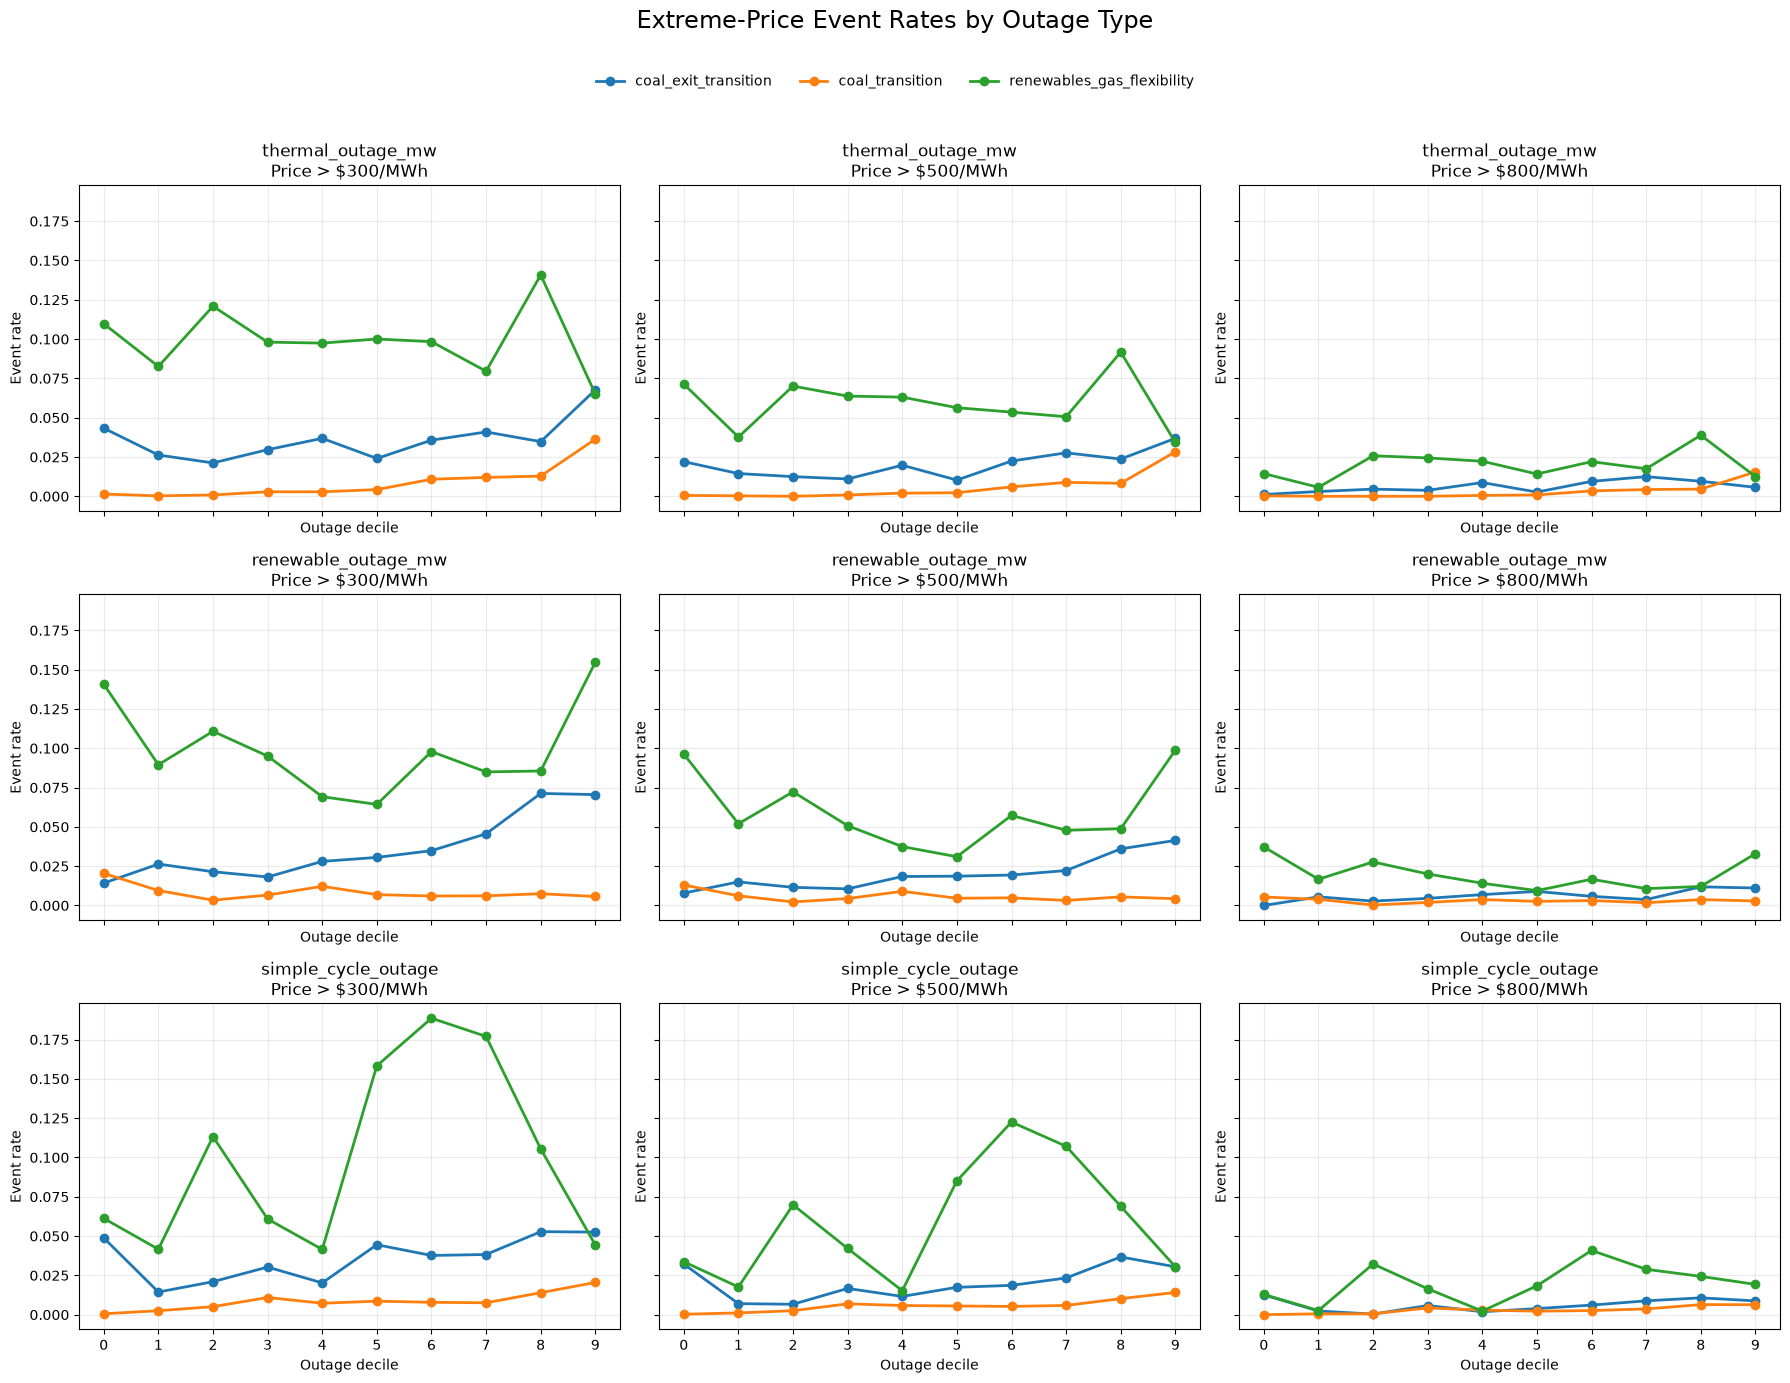

In [103]:
# ------------------------------------------------------------
# Compare outage types
#
# Rows = outage type
# Columns = price threshold
# Lines = generation regime
# ------------------------------------------------------------

features_to_plot = [
    "thermal_outage_mw",
    "renewable_outage_mw",
    "simple_cycle_outage",
]

fig, axes = plt.subplots(
    len(features_to_plot),
    len(thresholds),
    figsize=(18, 13),
    sharex=True,
    sharey=True,
    squeeze=False
)

regimes = sorted(
    outage_type_df["generation_regime"].dropna().unique()
)

for i, feature in enumerate(features_to_plot):

    for j, threshold in enumerate(thresholds):

        ax = axes[i, j]

        panel = outage_type_df[
            (outage_type_df["feature"] == feature)
            & (outage_type_df["threshold"] == threshold)
        ]

        for regime in regimes:

            line = (
                panel[
                    panel["generation_regime"] == regime
                ]
                .sort_values("decile")
            )

            if not line.empty:
                ax.plot(
                    line["decile"],
                    line["event_rate"],
                    marker="o",
                    linewidth=2,
                    label=regime
                )

        ax.set_title(
            f"{feature}\nPrice > ${threshold}/MWh"
        )

        ax.set_xlabel("Outage decile")
        ax.set_ylabel("Event rate")
        ax.set_xticks(range(10))
        ax.grid(True, alpha=0.25)

handles, labels = axes[0, 0].get_legend_handles_labels()

if handles:
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=3,
        frameon=False
    )

fig.suptitle(
    "Extreme-Price Event Rates by Outage Type",
    fontsize=17,
    y=1.06
)

plt.tight_layout()
plt.show()

### 2.6. Absolute Outage vs. Relative Outage Burden

In [104]:
# ------------------------------------------------------------
# Construct relative outage measures
# ------------------------------------------------------------

relative_outage_df = master[
    [
        "timestamp_utc",
        "generation_regime",
        "pool_price",
        "total_outage_mw",
        "thermal_outage_mw",
        "renewable_outage_mw",
        "simple_cycle_outage",
        "total_system_available",
        "total_system_capacity",
        "ail_mw",
    ]
].copy()

# Avoid division by zero
available_capacity = (
    relative_outage_df["total_system_available"]
    .replace(0, np.nan)
)

capacity = (
    relative_outage_df["total_system_capacity"]
    .replace(0, np.nan)
)

relative_outage_df["outage_share_available"] = (
    relative_outage_df["total_outage_mw"]
    / available_capacity
)

relative_outage_df["outage_share_capacity"] = (
    relative_outage_df["total_outage_mw"]
    / capacity
)

relative_outage_df["thermal_outage_share_available"] = (
    relative_outage_df["thermal_outage_mw"]
    / available_capacity
)

relative_outage_df["renewable_outage_share_available"] = (
    relative_outage_df["renewable_outage_mw"]
    / available_capacity
)

relative_outage_df["simple_cycle_outage_share_available"] = (
    relative_outage_df["simple_cycle_outage"]
    / available_capacity
)

display(
    relative_outage_df[
        [
            "total_outage_mw",
            "outage_share_available",
            "outage_share_capacity",
            "thermal_outage_share_available",
            "renewable_outage_share_available",
            "simple_cycle_outage_share_available",
        ]
    ].describe()
)

,total_outage_mw,outage_share_available,outage_share_capacity,thermal_outage_share_available,renewable_outage_share_available,simple_cycle_outage_share_available
count,87665.000000,87665.000000,87665.000000,87665.000000,87665.000000,87665.000000
mean,3490.680190,0.273376,0.210791,0.240743,0.032370,0.019406
std,724.832681,0.063805,0.038030,0.067713,0.024330,0.010814
min,1661.300000,0.119561,0.105927,0.081156,0.002710,0.001790
25%,2981.400000,0.228077,0.183830,0.190559,0.015467,0.012007
50%,3440.300000,0.267078,0.208950,0.236442,0.023662,0.016430
75%,3921.300000,0.311023,0.234961,0.281642,0.041385,0.023294
max,6991.150000,0.643381,0.388512,0.621410,0.204934,0.081945


In [105]:
# ------------------------------------------------------------
# Compare decile event rates for:
#
#   1. absolute total outage
#   2. outage as share of available capacity
# ------------------------------------------------------------

comparison_features = [
    "total_outage_mw",
    "outage_share_available",
]

threshold = 500

rows = []

for regime, regime_df in relative_outage_df.groupby(
    "generation_regime"
):

    for feature in comparison_features:

        temp = regime_df[
            [feature, "pool_price"]
        ].dropna().copy()

        temp["decile"] = pd.qcut(
            temp[feature],
            q=10,
            labels=False,
            duplicates="drop"
        )

        temp["event"] = (
            temp["pool_price"] > threshold
        ).astype(int)

        summary = (
            temp
            .groupby("decile", observed=True)
            .agg(
                feature_value_mean=(feature, "mean"),
                event_rate=("event", "mean"),
                observations=("event", "count")
            )
            .reset_index()
        )

        summary["feature"] = feature
        summary["generation_regime"] = regime

        rows.append(summary)

absolute_relative_df = pd.concat(
    rows,
    ignore_index=True
)

display(absolute_relative_df)

,decile,feature_value_mean,event_rate,observations,feature,generation_regime
0,0,2379.955640,0.010634,2633,total_outage_mw,coal_exit_transition
1,1,2720.446396,0.014795,2636,total_outage_mw,coal_exit_transition
2,2,2949.495086,0.010286,2625,total_outage_mw,coal_exit_transition
3,3,3121.592819,0.011778,2632,total_outage_mw,coal_exit_transition
4,4,3272.750625,0.015524,2641,total_outage_mw,coal_exit_transition
5,5,3413.308292,0.019870,2617,total_outage_mw,coal_exit_transition
6,6,3552.795258,0.021244,2636,total_outage_mw,coal_exit_transition
7,7,3721.396995,0.026246,2629,total_outage_mw,coal_exit_transition
8,8,3945.505746,0.028919,2628,total_outage_mw,coal_exit_transition
9,9,4457.729577,0.041492,2627,total_outage_mw,coal_exit_transition


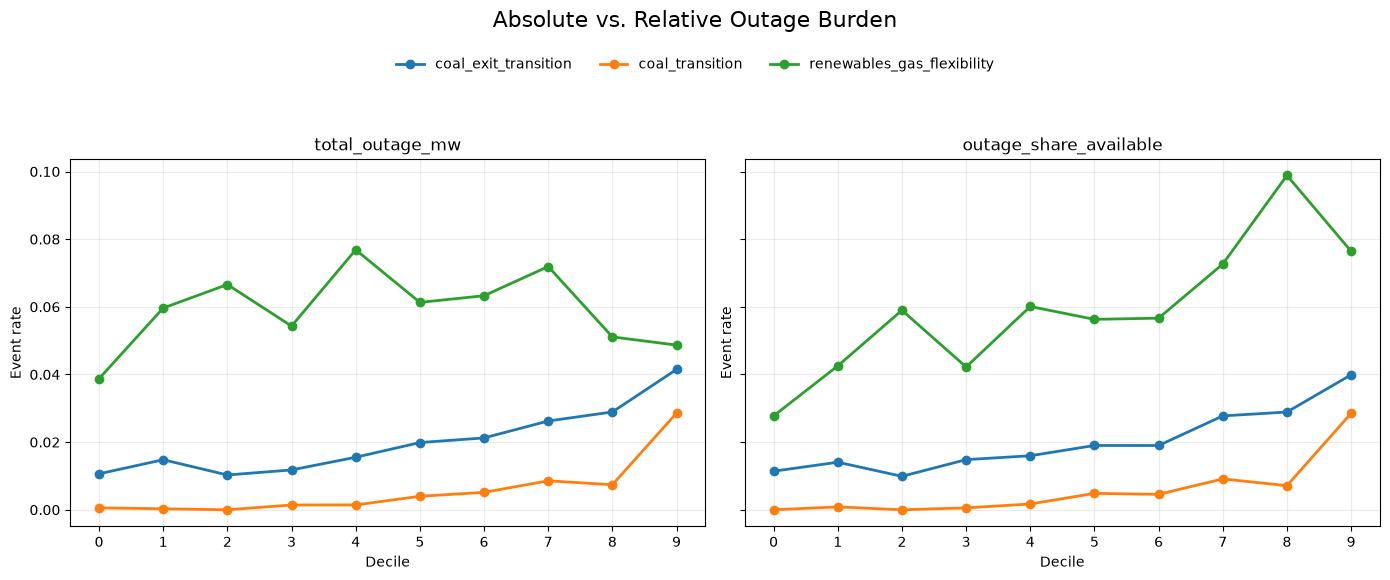

In [107]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    sharey=True
)

regimes = sorted(
    absolute_relative_df["generation_regime"].unique()
)

for ax, feature in zip(
    axes,
    comparison_features
):

    panel = absolute_relative_df[
        absolute_relative_df["feature"] == feature
    ]

    for regime in regimes:

        line = (
            panel[
                panel["generation_regime"] == regime
            ]
            .sort_values("decile")
        )

        ax.plot(
            line["decile"],
            line["event_rate"],
            marker="o",
            linewidth=2,
            label=regime
        )

    ax.set_title(feature)
    ax.set_xlabel("Decile")
    ax.set_ylabel("Event rate")
    ax.set_xticks(range(10))
    ax.grid(True, alpha=0.25)

fig.legend(
    *axes[0].get_legend_handles_labels(),
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=3,
    frameon=False
)

fig.suptitle(
    "Absolute vs. Relative Outage Burden",
    fontsize=16,
    y=1.15
)

plt.tight_layout()
plt.show()

### 2.7. Outages Under Different Load Conditions

In [108]:
# ------------------------------------------------------------
# Create load regimes
# ------------------------------------------------------------

load_df = master[
    [
        "ail_mw",
        "pool_price",
        "total_outage_mw",
        "thermal_outage_mw",
        "simple_cycle_outage",
        "generation_regime",
    ]
].dropna().copy()

load_df["load_regime"] = pd.qcut(
    load_df["ail_mw"],
    q=3,
    labels=[
        "low_load",
        "medium_load",
        "high_load"
    ]
)

load_df["scarcity_500"] = (
    load_df["pool_price"] > 500
).astype(int)

# ------------------------------------------------------------
# Event rates by load regime and outage quartile
# ------------------------------------------------------------

rows = []

for regime, regime_df in load_df.groupby(
    "generation_regime"
):

    for load_regime, load_group in regime_df.groupby(
        "load_regime",
        observed=True
    ):

        for feature in [
            "total_outage_mw",
            "thermal_outage_mw",
            "simple_cycle_outage",
        ]:

            temp = load_group[
                [feature, "scarcity_500"]
            ].dropna().copy()

            temp["outage_decile"] = pd.qcut(
                temp[feature],
                q=10,
                labels=False,
                duplicates="drop"
            )

            summary = (
                temp
                .groupby("outage_decile", observed=True)
                .agg(
                    event_rate=("scarcity_500", "mean"),
                    outage_mean=(feature, "mean"),
                    observations=("scarcity_500", "count")
                )
                .reset_index()
            )

            summary["generation_regime"] = regime
            summary["load_regime"] = str(load_regime)
            summary["feature"] = feature

            rows.append(summary)

load_outage_df = pd.concat(
    rows,
    ignore_index=True
)

display(load_outage_df)

,outage_decile,event_rate,outage_mean,observations,generation_regime,load_regime,feature
0,0,0.000000,2733.719861,861,coal_exit_transition,low_load,total_outage_mw
1,1,0.000000,3003.316414,859,coal_exit_transition,low_load,total_outage_mw
2,2,0.000000,3164.978630,861,coal_exit_transition,low_load,total_outage_mw
3,3,0.000000,3300.266014,868,coal_exit_transition,low_load,total_outage_mw
4,4,0.000000,3420.171345,855,coal_exit_transition,low_load,total_outage_mw
5,5,0.000000,3536.604070,860,coal_exit_transition,low_load,total_outage_mw
6,6,0.002342,3674.370141,854,coal_exit_transition,low_load,total_outage_mw
7,7,0.001163,3846.747674,860,coal_exit_transition,low_load,total_outage_mw
8,8,0.003492,4082.296740,859,coal_exit_transition,low_load,total_outage_mw
9,9,0.012791,4646.927093,860,coal_exit_transition,low_load,total_outage_mw


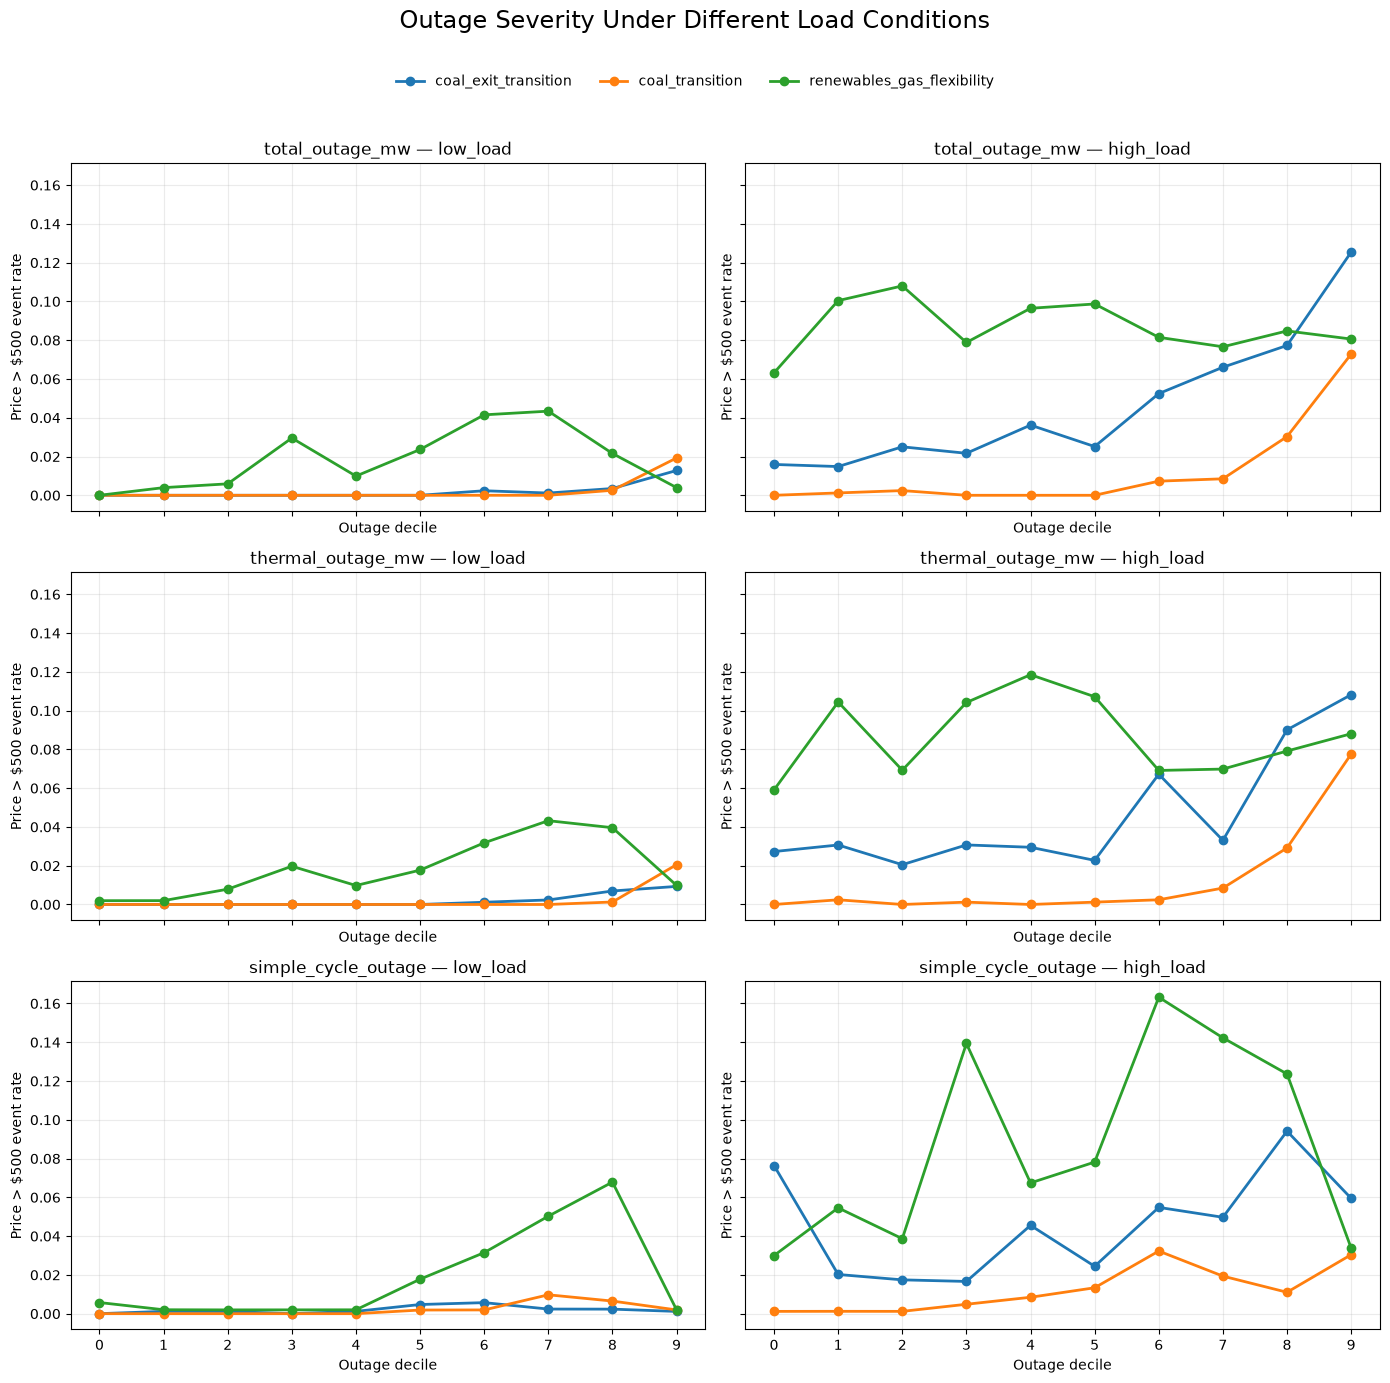

In [109]:
# ------------------------------------------------------------
# Plot high-load vs low-load outage relationships
# ------------------------------------------------------------

features = [
    "total_outage_mw",
    "thermal_outage_mw",
    "simple_cycle_outage",
]

load_states = [
    "low_load",
    "high_load",
]

fig, axes = plt.subplots(
    len(features),
    2,
    figsize=(14, 13),
    sharex=True,
    sharey=True,
    squeeze=False
)

regimes = sorted(
    load_outage_df["generation_regime"].unique()
)

for i, feature in enumerate(features):

    for j, load_state in enumerate(load_states):

        ax = axes[i, j]

        panel = load_outage_df[
            (load_outage_df["feature"] == feature)
            & (load_outage_df["load_regime"] == load_state)
        ]

        for regime in regimes:

            line = (
                panel[
                    panel["generation_regime"] == regime
                ]
                .sort_values("outage_decile")
            )

            ax.plot(
                line["outage_decile"],
                line["event_rate"],
                marker="o",
                linewidth=2,
                label=regime
            )

        ax.set_title(
            f"{feature} — {load_state}"
        )

        ax.set_xlabel("Outage decile")
        ax.set_ylabel("Price > $500 event rate")
        ax.set_xticks(range(10))
        ax.grid(True, alpha=0.25)

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=False
)

fig.suptitle(
    "Outage Severity Under Different Load Conditions",
    fontsize=17,
    y=1.06
)

plt.tight_layout()
plt.show()

### 2.8. Outages and Import Dependence

In [116]:
### 2.8. Outages and Import Dependence

# ------------------------------------------------------------
# Define import regimes
# ------------------------------------------------------------

import_df = master[
    [
        "total_imports_mw",
        "pool_price",
        "total_outage_mw",
        "thermal_outage_mw",
        "simple_cycle_outage",
        "generation_regime",
    ]
].dropna().copy()

import_df["import_regime"] = pd.qcut(
    import_df["total_imports_mw"],
    q=3,
    labels=[
        "low_imports",
        "medium_imports",
        "high_imports"
    ]
)

import_df["scarcity_500"] = (
    import_df["pool_price"] > 500
).astype(int)

# ------------------------------------------------------------
# Decile analysis
# ------------------------------------------------------------

rows = []

for regime, regime_df in import_df.groupby(
    "generation_regime"
):

    for import_regime, import_group in regime_df.groupby(
        "import_regime",
        observed=True
    ):

        for feature in [
            "total_outage_mw",
            "thermal_outage_mw",
            "simple_cycle_outage",
        ]:

            temp = import_group[
                [feature, "scarcity_500"]
            ].dropna().copy()

            temp["outage_decile"] = pd.qcut(
                temp[feature],
                q=10,
                labels=False,
                duplicates="drop"
            )

            summary = (
                temp
                .groupby("outage_decile", observed=True)
                .agg(
                    event_rate=("scarcity_500", "mean"),
                    outage_mean=(feature, "mean"),
                    observations=("scarcity_500", "count")
                )
                .reset_index()
            )

            summary["generation_regime"] = regime
            summary["import_regime"] = str(import_regime)
            summary["feature"] = feature

            rows.append(summary)

import_outage_df = pd.concat(
    rows,
    ignore_index=True
)

display(import_outage_df)

,outage_decile,event_rate,outage_mean,observations,generation_regime,import_regime,feature
0,0,0.000000,2297.809756,369,coal_exit_transition,low_imports,total_outage_mw
1,1,0.000000,2534.319459,370,coal_exit_transition,low_imports,total_outage_mw
2,2,0.005450,2753.896458,367,coal_exit_transition,low_imports,total_outage_mw
3,3,0.000000,2920.200813,369,coal_exit_transition,low_imports,total_outage_mw
4,4,0.008108,3094.102973,370,coal_exit_transition,low_imports,total_outage_mw
5,5,0.002725,3267.697548,367,coal_exit_transition,low_imports,total_outage_mw
6,6,0.000000,3421.057880,368,coal_exit_transition,low_imports,total_outage_mw
7,7,0.000000,3580.268564,369,coal_exit_transition,low_imports,total_outage_mw
8,8,0.016304,3749.818207,368,coal_exit_transition,low_imports,total_outage_mw
9,9,0.021680,4082.747425,369,coal_exit_transition,low_imports,total_outage_mw


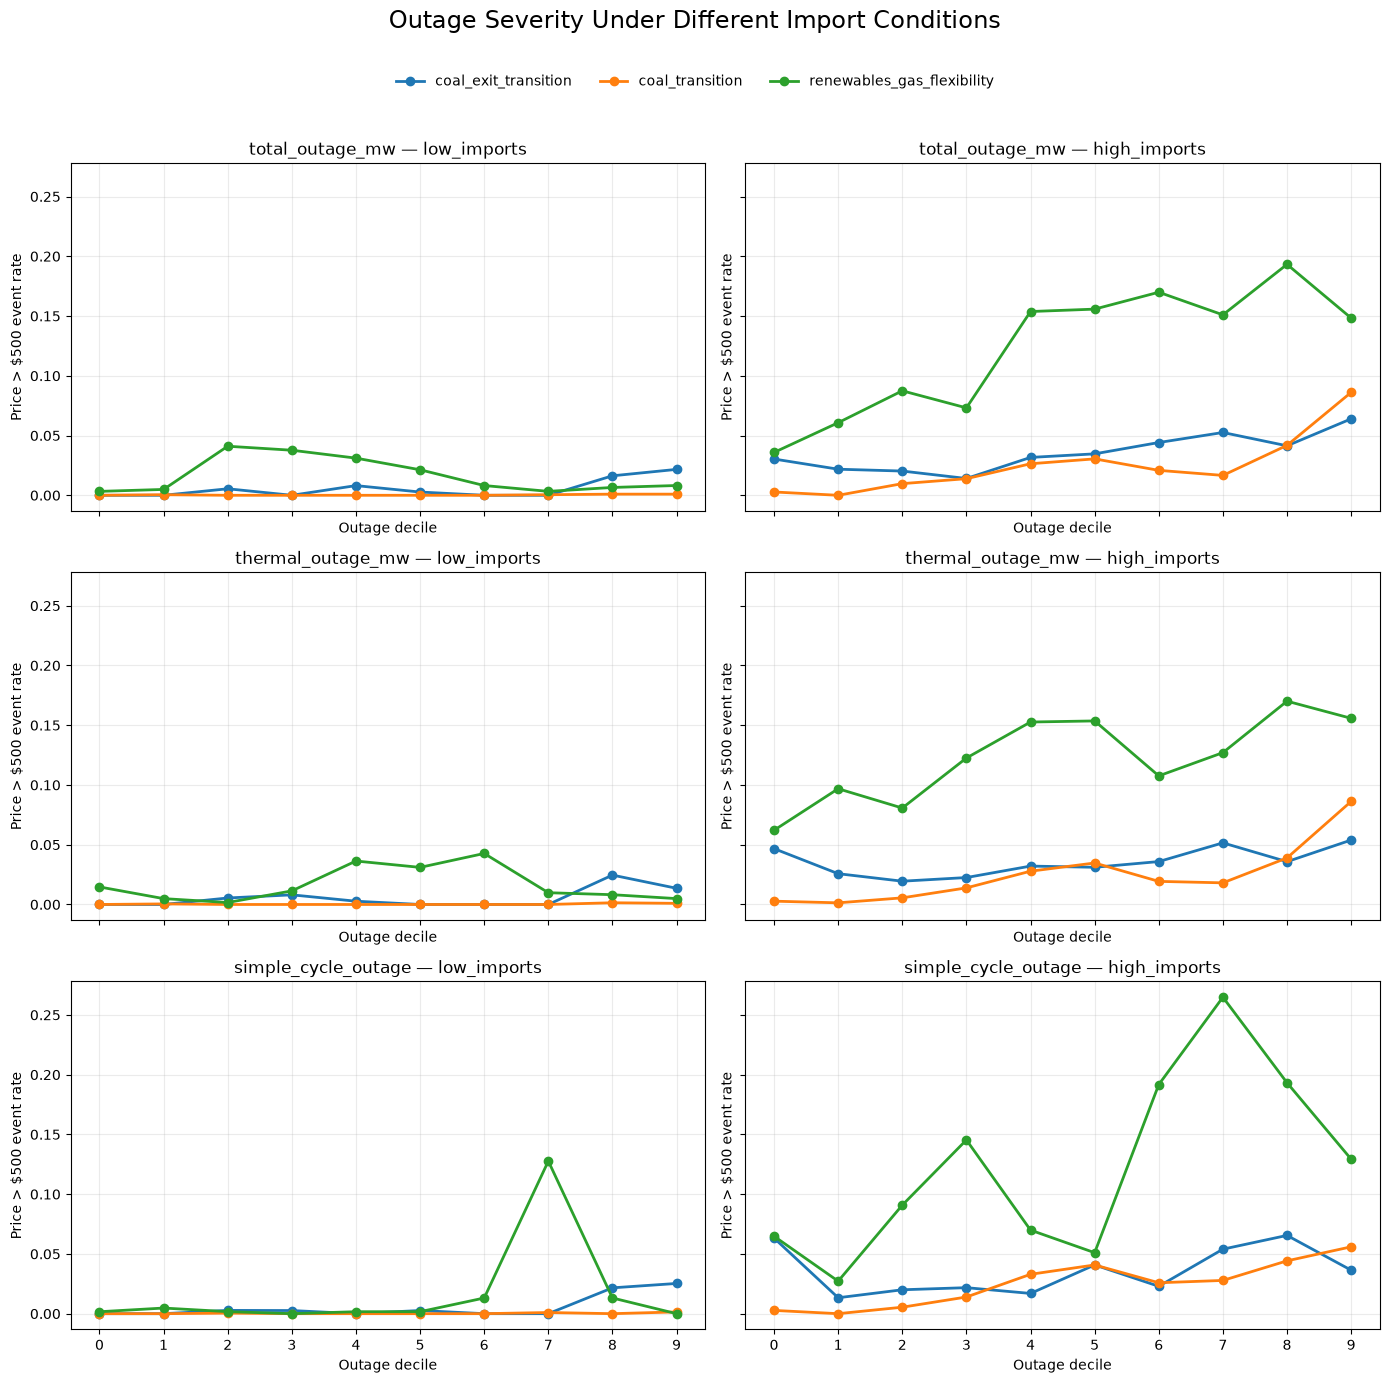

In [117]:
# ------------------------------------------------------------
# Compare low-import and high-import conditions
# ------------------------------------------------------------

features = [
    "total_outage_mw",
    "thermal_outage_mw",
    "simple_cycle_outage",
]

import_states = [
    "low_imports",
    "high_imports",
]

fig, axes = plt.subplots(
    len(features),
    2,
    figsize=(14, 13),
    sharex=True,
    sharey=True,
    squeeze=False
)

regimes = sorted(
    import_outage_df["generation_regime"].unique()
)

for i, feature in enumerate(features):

    for j, import_state in enumerate(import_states):

        ax = axes[i, j]

        panel = import_outage_df[
            (import_outage_df["feature"] == feature)
            & (
                import_outage_df["import_regime"]
                == import_state
            )
        ]

        for regime in regimes:

            line = (
                panel[
                    panel["generation_regime"] == regime
                ]
                .sort_values("outage_decile")
            )

            ax.plot(
                line["outage_decile"],
                line["event_rate"],
                marker="o",
                linewidth=2,
                label=regime
            )

        ax.set_title(
            f"{feature} — {import_state}"
        )

        ax.set_xlabel("Outage decile")
        ax.set_ylabel("Price > $500 event rate")
        ax.set_xticks(range(10))
        ax.grid(True, alpha=0.25)

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=False
)

fig.suptitle(
    "Outage Severity Under Different Import Conditions",
    fontsize=17,
    y=1.06
)

plt.tight_layout()
plt.show()

### 2.9. Outages and Pre-Existing System Tightness

In [118]:
# ------------------------------------------------------------
# System tightness variables
# ------------------------------------------------------------

tightness_features = [
    "ail_mw",
    "renewable_share",
    "total_imports_mw",
    "reserve_proxy_pct",
    "supply_pressure_proxy_mw",
    "total_outage_mw",
]

tightness_df = master[
    tightness_features
    + [
        "pool_price",
        "generation_regime",
    ]
].dropna().copy()

tightness_df["scarcity_500"] = (
    tightness_df["pool_price"] > 500
).astype(int)

# ------------------------------------------------------------
# Correlation with extreme-price event
# ------------------------------------------------------------

corr = (
    tightness_df[
        tightness_features + ["scarcity_500"]
    ]
    .corr(numeric_only=True)["scarcity_500"]
    .drop("scarcity_500")
    .sort_values()
)

print("Correlation with $500/MWh event:")
display(corr.to_frame("correlation"))

Correlation with $500/MWh event:


,correlation
renewable_share,-0.126069
reserve_proxy_pct,-0.074279
total_outage_mw,0.077333
supply_pressure_proxy_mw,0.099961
total_imports_mw,0.143845
ail_mw,0.159774


In [119]:
# ------------------------------------------------------------
# Compare outage burden after conditioning on system tightness
#
# Divide reserve proxy into tertiles and examine outage deciles
# ------------------------------------------------------------

condition_df = master[
    [
        "total_outage_mw",
        "reserve_proxy_pct",
        "pool_price",
        "generation_regime",
    ]
].dropna().copy()

condition_df["tightness_regime"] = pd.qcut(
    condition_df["reserve_proxy_pct"],
    q=3,
    labels=[
        "tight",
        "medium",
        "loose"
    ]
)

condition_df["scarcity_500"] = (
    condition_df["pool_price"] > 500
).astype(int)

rows = []

for regime, regime_df in condition_df.groupby(
    "generation_regime"
):

    for tightness, group_df in regime_df.groupby(
        "tightness_regime",
        observed=True
    ):

        temp = group_df[
            [
                "total_outage_mw",
                "scarcity_500",
            ]
        ].copy()

        temp["outage_decile"] = pd.qcut(
            temp["total_outage_mw"],
            q=10,
            labels=False,
            duplicates="drop"
        )

        summary = (
            temp
            .groupby("outage_decile", observed=True)
            .agg(
                outage_mean=("total_outage_mw", "mean"),
                event_rate=("scarcity_500", "mean"),
                observations=("scarcity_500", "count")
            )
            .reset_index()
        )

        summary["generation_regime"] = regime
        summary["tightness_regime"] = str(tightness)

        rows.append(summary)

conditional_outage_df = pd.concat(
    rows,
    ignore_index=True
)

display(conditional_outage_df)

,outage_decile,outage_mean,event_rate,observations,generation_regime,tightness_regime
0,0,2359.178620,0.020255,1333,coal_exit_transition,tight
1,1,2685.656377,0.027925,1325,coal_exit_transition,tight
2,2,2951.681777,0.028614,1328,coal_exit_transition,tight
3,3,3163.067442,0.024006,1333,coal_exit_transition,tight
4,4,3345.549021,0.048946,1328,coal_exit_transition,tight
5,5,3504.686103,0.040785,1324,coal_exit_transition,tight
6,6,3666.346287,0.035259,1333,coal_exit_transition,tight
7,7,3848.304733,0.060856,1331,coal_exit_transition,tight
8,8,4099.101060,0.046934,1321,coal_exit_transition,tight
9,9,4612.079233,0.051166,1329,coal_exit_transition,tight


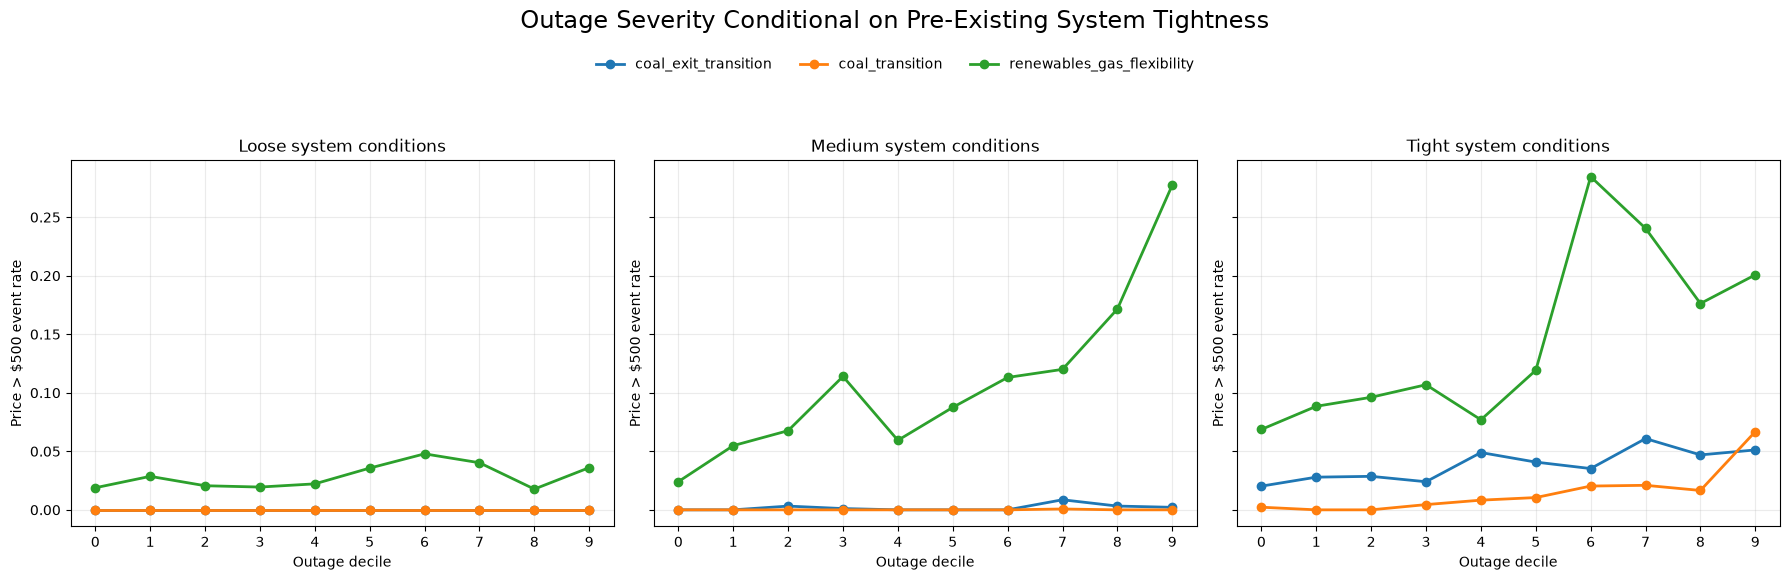

In [120]:
# ------------------------------------------------------------
# Plot outage severity conditional on reserve/tightness state
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    sharex=True,
    sharey=True
)

for ax, tightness in zip(
    axes,
    ["loose", "medium", "tight"]
):

    panel = conditional_outage_df[
        conditional_outage_df["tightness_regime"]
        == tightness
    ]

    for regime in sorted(
        panel["generation_regime"].unique()
    ):

        line = (
            panel[
                panel["generation_regime"] == regime
            ]
            .sort_values("outage_decile")
        )

        ax.plot(
            line["outage_decile"],
            line["event_rate"],
            marker="o",
            linewidth=2,
            label=regime
        )

    ax.set_title(
        f"{tightness.capitalize()} system conditions"
    )

    ax.set_xlabel("Outage decile")
    ax.set_ylabel("Price > $500 event rate")
    ax.set_xticks(range(10))
    ax.grid(True, alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=3,
    frameon=False
)

fig.suptitle(
    "Outage Severity Conditional on Pre-Existing System Tightness",
    fontsize=17,
    y=1.15
)

plt.tight_layout()
plt.show()

### 2.10. Incremental Information from Outage Magnitude

In [121]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# ------------------------------------------------------------
# Variables
# ------------------------------------------------------------

baseline_features = [
    "ail_mw",
    "renewable_share",
    "total_imports_mw",
    "reserve_proxy_pct",
    "spark_spread_proxy",
]

outage_features = [
    "total_outage_mw",
    "thermal_outage_mw",
    "simple_cycle_outage",
]

categorical_features = [
    "generation_regime",
]

model_features = (
    baseline_features
    + outage_features
    + categorical_features
)

model_df = master[
    model_features
    + ["pool_price"]
].copy()

model_df["scarcity_500"] = (
    model_df["pool_price"] > 500
).astype(int)

model_df = model_df.drop(
    columns=["pool_price"]
).dropna()

print("Model observations:", len(model_df))
print(
    "Event rate:",
    model_df["scarcity_500"].mean()
)

Model observations: 87665
Event rate: 0.026087948440084413


In [122]:
# ------------------------------------------------------------
# Train/test split
# ------------------------------------------------------------

X = model_df.drop(columns="scarcity_500")
y = model_df["scarcity_500"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# Baseline model
# ------------------------------------------------------------

baseline_numeric = baseline_features

baseline_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            baseline_numeric
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
    ]
)

baseline_model = Pipeline(
    steps=[
        (
            "preprocess",
            baseline_preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000
            )
        ),
    ]
)

baseline_model.fit(
    X_train[
        baseline_features
        + categorical_features
    ],
    y_train
)

baseline_probability = baseline_model.predict_proba(
    X_test[
        baseline_features
        + categorical_features
    ]
)[:, 1]

baseline_auc = roc_auc_score(
    y_test,
    baseline_probability
)

# ------------------------------------------------------------
# Extended model with outages
# ------------------------------------------------------------

extended_numeric = (
    baseline_features
    + outage_features
)

extended_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            extended_numeric
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
    ]
)

extended_model = Pipeline(
    steps=[
        (
            "preprocess",
            extended_preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000
            )
        ),
    ]
)

extended_model.fit(
    X_train[
        extended_numeric
        + categorical_features
    ],
    y_train
)

extended_probability = extended_model.predict_proba(
    X_test[
        extended_numeric
        + categorical_features
    ]
)[:, 1]

extended_auc = roc_auc_score(
    y_test,
    extended_probability
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print(f"Baseline AUC:  {baseline_auc:.4f}")
print(f"Outage AUC:    {extended_auc:.4f}")
print(f"AUC improvement: {extended_auc - baseline_auc:+.4f}")

Baseline AUC:  1.0000
Outage AUC:    1.0000
AUC improvement: +0.0000



## Section 4 - Availability Thermal

### 4.1. Scarcity vs normal availability comparison

In [ ]:
# Define aggregate thermal availability from individual thermal generation types.
# These features are added to the master dataframe for reuse throughout this section.

master["thermal_availability"] = (
    master["combined_cycle_system_available"]
    + master["simple_cycle_system_available"]
    + master["cogeneration_system_available"]
)

master["combined_cycle_availability"] = (
    master["combined_cycle_system_available"]
)

master["simple_cycle_availability"] = (
    master["simple_cycle_system_available"]
)

master["cogeneration_availability"] = (
    master["cogeneration_system_available"]
)


# Define scarcity and normal hours.

scarcity = master[master["scarcity_event"] == 1]
normal = master[master["scarcity_event"] == 0]


# Define availability features for comparison and validation.

availability_features = [
    "thermal_availability",
    "combined_cycle_availability",
    "simple_cycle_availability",
    "cogeneration_availability",
]


# Compare generation availability during scarcity and normal hours.

availability_comparison = pd.DataFrame({
    "scarcity": scarcity[availability_features].mean(),
    "normal": normal[availability_features].mean(),
})


# Calculate absolute difference.

availability_comparison["difference"] = (
    availability_comparison["scarcity"]
    - availability_comparison["normal"]
)


# Calculate percentage difference.

availability_comparison["pct_difference"] = (
    availability_comparison["difference"]
    / availability_comparison["normal"].replace(0, np.nan)
    * 100
)


# Display from largest availability decline to smallest.

availability_comparison.sort_values(
    "pct_difference",
    ascending=True
)

,scarcity,normal,difference,pct_difference
simple_cycle_availability,746.808251,765.903259,-19.095007,-2.493136
thermal_availability,5519.186819,5286.040448,233.146371,4.410605
combined_cycle_availability,1584.390503,1514.409016,69.981488,4.621043
cogeneration_availability,3187.988064,3005.728174,182.259890,6.063752


NameError: name 'import_outage_df' is not defined

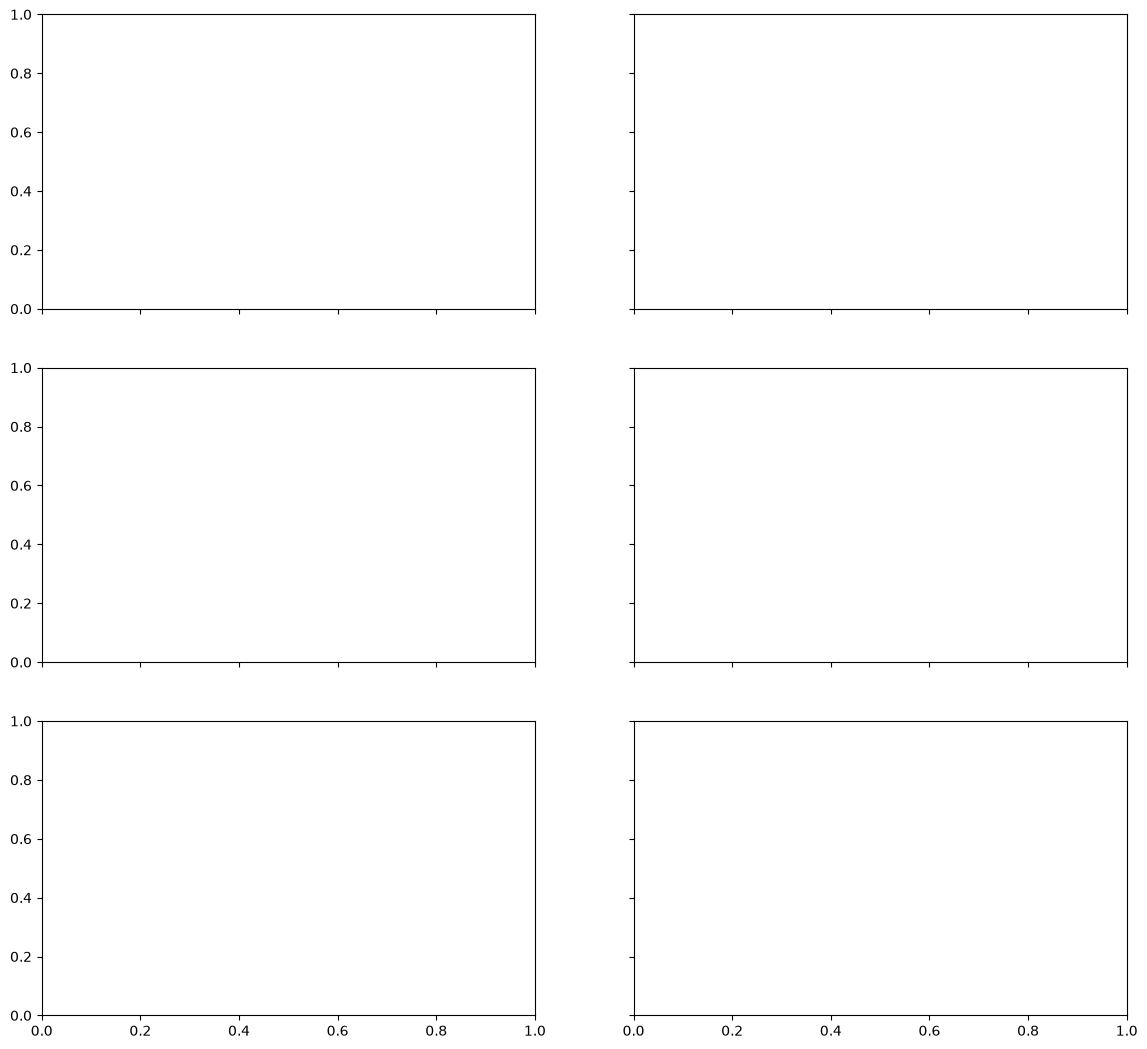

In [110]:
# ------------------------------------------------------------
# Compare low-import and high-import conditions
# ------------------------------------------------------------

features = [
    "total_outage_mw",
    "thermal_outage_mw",
    "simple_cycle_outage",
]

import_states = [
    "low_imports",
    "high_imports",
]

fig, axes = plt.subplots(
    len(features),
    2,
    figsize=(14, 13),
    sharex=True,
    sharey=True,
    squeeze=False
)

regimes = sorted(
    import_outage_df["generation_regime"].unique()
)

for i, feature in enumerate(features):

    for j, import_state in enumerate(import_states):

        ax = axes[i, j]

        panel = import_outage_df[
            (import_outage_df["feature"] == feature)
            & (
                import_outage_df["import_regime"]
                == import_state
            )
        ]

        for regime in regimes:

            line = (
                panel[
                    panel["generation_regime"] == regime
                ]
                .sort_values("outage_decile")
            )

            ax.plot(
                line["outage_decile"],
                line["event_rate"],
                marker="o",
                linewidth=2,
                label=regime
            )

        ax.set_title(
            f"{feature} — {import_state}"
        )

        ax.set_xlabel("Outage decile")
        ax.set_ylabel("Price > $500 event rate")
        ax.set_xticks(range(10))
        ax.grid(True, alpha=0.25)

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=False
)

fig.suptitle(
    "Outage Severity Under Different Import Conditions",
    fontsize=17,
    y=1.06
)

plt.tight_layout()
plt.show()

In [ ]:
# Compare generation availability during scarcity and normal hours
# by Alberta calendar year.

availability_yoy = []

for year, group in master.groupby("year_alberta"):

    scarcity_year = group[group["scarcity_event"] == 1]
    normal_year = group[group["scarcity_event"] == 0]

    for feature in availability_features:

        scarcity_mean = scarcity_year[feature].mean()
        normal_mean = normal_year[feature].mean()

        difference = scarcity_mean - normal_mean

        pct_difference = (
            difference / normal_mean * 100
            if normal_mean != 0
            else np.nan
        )

        availability_yoy.append({
            "year_alberta": year,
            "feature": feature,
            "scarcity": scarcity_mean,
            "normal": normal_mean,
            "difference": difference,
            "pct_difference": pct_difference,
        })

availability_yoy_df = (
    pd.DataFrame(availability_yoy)
    .sort_values(
        ["year_alberta", "pct_difference"],
        ascending=[True, True]
    )
    .reset_index(drop=True)
)

availability_yoy_df

,year_alberta,feature,scarcity,normal,difference,pct_difference
0,2015,cogeneration_availability,2282.846154,2676.052998,-393.206844,-14.693537
1,2015,thermal_availability,4090.484615,4514.806564,-424.321948,-9.398452
2,2015,simple_cycle_availability,662.523077,723.813406,-61.290329,-8.467697
3,2015,combined_cycle_availability,1145.115385,1114.940160,30.175225,2.706443
4,2016,simple_cycle_availability,715.250000,742.194077,-26.944077,-3.630328
5,2016,cogeneration_availability,2568.750000,2509.685649,59.064351,2.353456
6,2016,thermal_availability,4646.750000,4450.430979,196.319021,4.411236
7,2016,combined_cycle_availability,1362.750000,1198.551253,164.198747,13.699769
8,2017,simple_cycle_availability,636.363636,725.171677,-88.808040,-12.246485
9,2017,thermal_availability,4620.000000,4796.965939,-176.965939,-3.689122


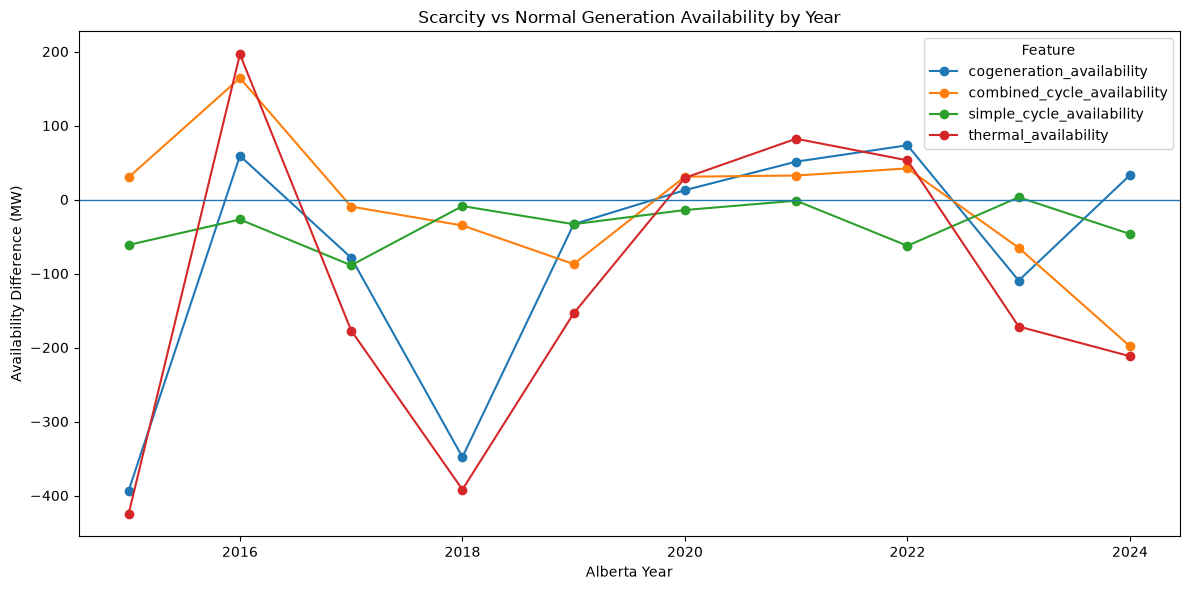

In [ ]:
# Plot the scarcity-normal availability difference over time.

import matplotlib.pyplot as plt

availability_yoy_plot = availability_yoy_df.pivot(
    index="year_alberta",
    columns="feature",
    values="difference"
)

availability_yoy_plot.plot(
    figsize=(12, 6),
    marker="o"
)

plt.axhline(0, linewidth=1)
plt.title("Scarcity vs Normal Generation Availability by Year")
plt.xlabel("Alberta Year")
plt.ylabel("Availability Difference (MW)")
plt.legend(title="Feature")
plt.tight_layout()
plt.show()

### 2.9. Outages and Pre-existing System Tightness

In [111]:
# ------------------------------------------------------------
# System tightness variables
# ------------------------------------------------------------

tightness_features = [
    "ail_mw",
    "renewable_share",
    "total_imports_mw",
    "reserve_proxy_pct",
    "supply_pressure_proxy_mw",
    "total_outage_mw",
]

tightness_df = master[
    tightness_features
    + [
        "pool_price",
        "generation_regime",
    ]
].dropna().copy()

tightness_df["scarcity_500"] = (
    tightness_df["pool_price"] > 500
).astype(int)

# ------------------------------------------------------------
# Correlation with extreme-price event
# ------------------------------------------------------------

corr = (
    tightness_df[
        tightness_features + ["scarcity_500"]
    ]
    .corr(numeric_only=True)["scarcity_500"]
    .drop("scarcity_500")
    .sort_values()
)

print("Correlation with $500/MWh event:")
display(corr.to_frame("correlation"))

Correlation with $500/MWh event:


,correlation
renewable_share,-0.126069
reserve_proxy_pct,-0.074279
total_outage_mw,0.077333
supply_pressure_proxy_mw,0.099961
total_imports_mw,0.143845
ail_mw,0.159774


In [112]:
# ------------------------------------------------------------
# Compare outage burden after conditioning on system tightness
#
# Divide reserve proxy into tertiles and examine outage deciles
# ------------------------------------------------------------

condition_df = master[
    [
        "total_outage_mw",
        "reserve_proxy_pct",
        "pool_price",
        "generation_regime",
    ]
].dropna().copy()

condition_df["tightness_regime"] = pd.qcut(
    condition_df["reserve_proxy_pct"],
    q=3,
    labels=[
        "tight",
        "medium",
        "loose"
    ]
)

condition_df["scarcity_500"] = (
    condition_df["pool_price"] > 500
).astype(int)

rows = []

for regime, regime_df in condition_df.groupby(
    "generation_regime"
):

    for tightness, group_df in regime_df.groupby(
        "tightness_regime",
        observed=True
    ):

        temp = group_df[
            [
                "total_outage_mw",
                "scarcity_500",
            ]
        ].copy()

        temp["outage_decile"] = pd.qcut(
            temp["total_outage_mw"],
            q=10,
            labels=False,
            duplicates="drop"
        )

        summary = (
            temp
            .groupby("outage_decile", observed=True)
            .agg(
                outage_mean=("total_outage_mw", "mean"),
                event_rate=("scarcity_500", "mean"),
                observations=("scarcity_500", "count")
            )
            .reset_index()
        )

        summary["generation_regime"] = regime
        summary["tightness_regime"] = str(tightness)

        rows.append(summary)

conditional_outage_df = pd.concat(
    rows,
    ignore_index=True
)

display(conditional_outage_df)

,outage_decile,outage_mean,event_rate,observations,generation_regime,tightness_regime
0,0,2359.178620,0.020255,1333,coal_exit_transition,tight
1,1,2685.656377,0.027925,1325,coal_exit_transition,tight
2,2,2951.681777,0.028614,1328,coal_exit_transition,tight
3,3,3163.067442,0.024006,1333,coal_exit_transition,tight
4,4,3345.549021,0.048946,1328,coal_exit_transition,tight
5,5,3504.686103,0.040785,1324,coal_exit_transition,tight
6,6,3666.346287,0.035259,1333,coal_exit_transition,tight
7,7,3848.304733,0.060856,1331,coal_exit_transition,tight
8,8,4099.101060,0.046934,1321,coal_exit_transition,tight
9,9,4612.079233,0.051166,1329,coal_exit_transition,tight


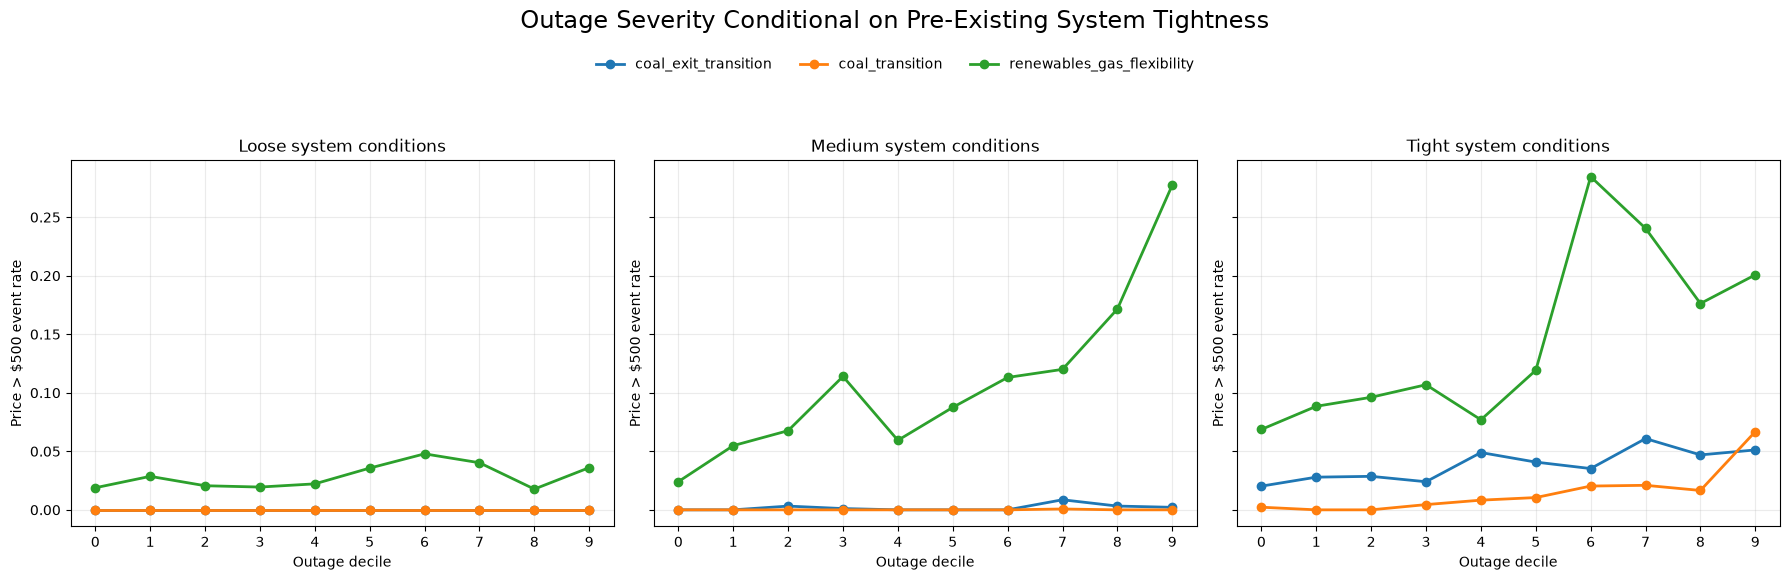

In [113]:
# ------------------------------------------------------------
# Plot outage severity conditional on reserve/tightness state
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    sharex=True,
    sharey=True
)

for ax, tightness in zip(
    axes,
    ["loose", "medium", "tight"]
):

    panel = conditional_outage_df[
        conditional_outage_df["tightness_regime"]
        == tightness
    ]

    for regime in sorted(
        panel["generation_regime"].unique()
    ):

        line = (
            panel[
                panel["generation_regime"] == regime
            ]
            .sort_values("outage_decile")
        )

        ax.plot(
            line["outage_decile"],
            line["event_rate"],
            marker="o",
            linewidth=2,
            label=regime
        )

    ax.set_title(
        f"{tightness.capitalize()} system conditions"
    )

    ax.set_xlabel("Outage decile")
    ax.set_ylabel("Price > $500 event rate")
    ax.set_xticks(range(10))
    ax.grid(True, alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=3,
    frameon=False
)

fig.suptitle(
    "Outage Severity Conditional on Pre-Existing System Tightness",
    fontsize=17,
    y=1.15
)

plt.tight_layout()
plt.show()

### 2.10. Incremental Information from Outage Magnitude

In [114]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# ------------------------------------------------------------
# Variables
# ------------------------------------------------------------

baseline_features = [
    "ail_mw",
    "renewable_share",
    "total_imports_mw",
    "reserve_proxy_pct",
    "spark_spread_proxy",
]

outage_features = [
    "total_outage_mw",
    "thermal_outage_mw",
    "simple_cycle_outage",
]

categorical_features = [
    "generation_regime",
]

model_features = (
    baseline_features
    + outage_features
    + categorical_features
)

model_df = master[
    model_features
    + ["pool_price"]
].copy()

model_df["scarcity_500"] = (
    model_df["pool_price"] > 500
).astype(int)

model_df = model_df.drop(
    columns=["pool_price"]
).dropna()

print("Model observations:", len(model_df))
print(
    "Event rate:",
    model_df["scarcity_500"].mean()
)

Model observations: 87665
Event rate: 0.026087948440084413


In [115]:
# ------------------------------------------------------------
# Train/test split
# ------------------------------------------------------------

X = model_df.drop(columns="scarcity_500")
y = model_df["scarcity_500"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# Baseline model
# ------------------------------------------------------------

baseline_numeric = baseline_features

baseline_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            baseline_numeric
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
    ]
)

baseline_model = Pipeline(
    steps=[
        (
            "preprocess",
            baseline_preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000
            )
        ),
    ]
)

baseline_model.fit(
    X_train[
        baseline_features
        + categorical_features
    ],
    y_train
)

baseline_probability = baseline_model.predict_proba(
    X_test[
        baseline_features
        + categorical_features
    ]
)[:, 1]

baseline_auc = roc_auc_score(
    y_test,
    baseline_probability
)

# ------------------------------------------------------------
# Extended model with outages
# ------------------------------------------------------------

extended_numeric = (
    baseline_features
    + outage_features
)

extended_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            extended_numeric
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
    ]
)

extended_model = Pipeline(
    steps=[
        (
            "preprocess",
            extended_preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000
            )
        ),
    ]
)

extended_model.fit(
    X_train[
        extended_numeric
        + categorical_features
    ],
    y_train
)

extended_probability = extended_model.predict_proba(
    X_test[
        extended_numeric
        + categorical_features
    ]
)[:, 1]

extended_auc = roc_auc_score(
    y_test,
    extended_probability
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print(f"Baseline AUC:  {baseline_auc:.4f}")
print(f"Outage AUC:    {extended_auc:.4f}")
print(f"AUC improvement: {extended_auc - baseline_auc:+.4f}")

Baseline AUC:  1.0000
Outage AUC:    1.0000
AUC improvement: +0.0000


### Year-over-year availability patterns

The relationship between generation availability and scarcity conditions changes substantially across the study period. Unlike outage metrics, where higher unavailable capacity generally corresponds to tighter conditions, availability measures show that scarcity is not consistently associated with lower available generation. This suggests that scarcity events are often driven by the interaction between available supply, demand conditions, imports, renewable output, and system operating margins rather than simply the absolute level of available generation.

In the earlier years of the dataset, scarcity events were more strongly associated with reduced thermal availability. In 2015, thermal availability was approximately 9% lower during scarcity hours, driven primarily by lower cogeneration availability. Cogeneration availability was nearly 15% lower during scarcity conditions that year. A similar pattern occurred in 2018, where thermal availability was approximately 8% lower during scarcity hours, again largely reflecting reduced cogeneration availability.

However, this relationship weakened over time as Alberta's generation fleet evolved. Between 2020 and 2022, thermal availability during scarcity hours was slightly higher than during normal conditions. For example, in 2021 thermal availability was approximately 1.5% higher during scarcity periods, while in 2022 it was approximately 1% higher. This indicates that recent scarcity events were not primarily caused by a lack of available thermal capacity, but rather by periods where available capacity was insufficient relative to demand and other system conditions.

Cogeneration availability shows the strongest historical relationship among the thermal categories, particularly in the earlier years. Large negative differences in 2015 and 2018 indicate that unavailable cogeneration capacity contributed to system tightness during some scarcity periods. However, after 2020, cogeneration availability differences became small or even positive, suggesting that its role as a scarcity driver has become less consistent.

Combined-cycle availability displays a similar transition. Early years show mixed results, with some years showing lower availability during scarcity and others showing higher availability. After 2020, combined-cycle availability was generally slightly higher during scarcity hours until 2023 and 2024, when the relationship reversed. In 2024, combined-cycle availability was approximately 9% lower during scarcity events, representing one of the largest recent availability declines.

Simple-cycle availability provides the weakest and least consistent signal. Although simple-cycle units are typically important peaking resources, their availability differences between scarcity and normal periods are relatively small across most years. The largest declines occurred in 2015 and 2017, while later years show minimal differences. This suggests that scarcity is not primarily explained by simple-cycle availability alone, despite the importance of these units during tight operating conditions.

Overall, the year-over-year availability analysis reinforces that scarcity drivers have shifted over the 2015–2025 period. Earlier scarcity events were more closely associated with reduced thermal availability, particularly from cogeneration resources. More recent scarcity events appear less dependent on total available thermal capacity and more dependent on the interaction between demand growth, renewable variability, transmission constraints, imports, and available operating margins.

Availability therefore provides a different perspective from outage analysis. Outages measure forced reductions in supply, while availability captures the remaining generation capability of the system. The results suggest that low availability can contribute to scarcity, but high availability does not eliminate scarcity risk when demand or other system constraints push the market toward tight operating conditions.

### 3.2. AUC Validation

In [ ]:
# Create thermal and renewable availability margin features.
# These are added temporarily for scarcity analysis.

master["thermal_available_margin_mw"] = (
    master["thermal_availability"]
    - master["ail_mw"]
)

master["thermal_available_margin_pct"] = (
    master["thermal_available_margin_mw"]
    / master["ail_mw"]
)


# Create renewable availability features.

master["renewable_availability"] = (
    master["wind_system_available"]
    + master["solar_system_available"]
)

master["renewable_available_margin_mw"] = (
    master["renewable_availability"]
    - master["ail_mw"]
)

master["renewable_available_margin_pct"] = (
    master["renewable_available_margin_mw"]
    / master["ail_mw"]
)


# Validate whether availability measures and availability margins
# distinguish scarcity from normal hours.

availability_auc_results = []

availability_features_test = [
    "thermal_availability",
    "combined_cycle_availability",
    "simple_cycle_availability",
    "cogeneration_availability",
    "renewable_availability",
    "thermal_available_margin_mw",
    "thermal_available_margin_pct",
    "renewable_available_margin_mw",
    "renewable_available_margin_pct",
]


for feature in availability_features_test:

    # AUC test
    result = feature_auc(
        master,
        feature
    )

    # Scarcity vs normal comparison
    scarcity_mean = master.loc[
        master["scarcity_event"] == 1,
        feature
    ].mean()

    normal_mean = master.loc[
        master["scarcity_event"] == 0,
        feature
    ].mean()

    margin = scarcity_mean - normal_mean

    margin_pct = (
        margin / normal_mean * 100
        if normal_mean != 0
        else np.nan
    )

    # Add comparison metrics
    result["scarcity_mean"] = scarcity_mean
    result["normal_mean"] = normal_mean
    result["margin"] = margin
    result["margin_pct"] = margin_pct

    availability_auc_results.append(result)


availability_auc_df = (
    pd.DataFrame(availability_auc_results)
    .sort_values("auc", ascending=False)
    .reset_index(drop=True)
)


availability_auc_df

,feature,auc,direction,n_obs,scarcity_mean,normal_mean,margin,margin_pct
0,thermal_available_margin_mw,0.689709,negative,87665,-4817.077322,-4292.054134,-525.023189,12.232446
1,renewable_availability,0.634024,positive,62009,3263.339445,2789.655540,473.683904,16.980014
2,thermal_availability,0.615212,positive,87665,5519.186819,5286.040448,233.146371,4.410605
3,cogeneration_availability,0.611248,positive,87665,3187.988064,3005.728174,182.259890,6.063752
4,combined_cycle_availability,0.606431,positive,87665,1584.390503,1514.409016,69.981488,4.621043
5,renewable_available_margin_pct,0.597450,positive,62009,-0.682996,-0.714238,0.031242,-4.374106
6,simple_cycle_availability,0.570917,negative,87665,746.808251,765.903259,-19.095007,-2.493136
7,thermal_available_margin_pct,0.566086,negative,87665,-0.465912,-0.447666,-0.018246,4.075739
8,renewable_available_margin_mw,0.508954,negative,62009,-7097.487463,-6960.021046,-137.466417,1.975086


In [ ]:
# Calculate year-over-year AUC performance for availability features.

availability_yoy_auc_results = []

availability_features_yoy = [
    "thermal_availability",
    "combined_cycle_availability",
    "simple_cycle_availability",
    "cogeneration_availability",
    "renewable_availability",
    "thermal_available_margin_mw",
    "thermal_available_margin_pct",
    "renewable_available_margin_mw",
    "renewable_available_margin_pct",
]


for year, group in master.groupby("year_alberta"):

    # Require both scarcity and normal observations
    if group["scarcity_event"].nunique() < 2:
        continue

    for feature in availability_features_yoy:

        # Skip features with no valid data in this year
        test_df = group[[feature, "scarcity_event"]].dropna()

        if len(test_df) == 0:
            continue

        # Skip years where only one class remains after dropna
        if test_df["scarcity_event"].nunique() < 2:
            continue

        result = feature_auc(
            group,
            feature
        )

        scarcity_mean = group.loc[
            group["scarcity_event"] == 1,
            feature
        ].mean()

        normal_mean = group.loc[
            group["scarcity_event"] == 0,
            feature
        ].mean()

        margin = scarcity_mean - normal_mean

        margin_pct = (
            margin / normal_mean * 100
            if normal_mean != 0
            else np.nan
        )

        availability_yoy_auc_results.append({
            "year_alberta": year,
            "feature": feature,
            "auc": result["auc"],
            "direction": result["direction"],
            "n_obs": result["n_obs"],
            "scarcity_mean": scarcity_mean,
            "normal_mean": normal_mean,
            "margin": margin,
            "margin_pct": margin_pct,
        })


availability_yoy_auc_df = (
    pd.DataFrame(availability_yoy_auc_results)
    .sort_values(
        ["year_alberta", "auc"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)


# Display full dataframe with scrollable output

pd.set_option(
    "display.max_rows",
    None
)

pd.set_option(
    "display.max_columns",
    None
)

display(availability_yoy_auc_df)

,year_alberta,feature,auc,direction,n_obs,scarcity_mean,normal_mean,margin,margin_pct
0,2015,thermal_available_margin_pct,0.876633,negative,8753,-0.576192,-0.504157,-0.072035,14.288273
1,2015,thermal_available_margin_mw,0.835146,negative,8753,-5557.800000,-4638.990722,-918.809278,19.806232
2,2015,cogeneration_availability,0.819784,negative,8753,2282.846154,2676.052998,-393.206844,-14.693537
3,2015,simple_cycle_availability,0.781279,negative,8753,662.523077,723.813406,-61.290329,-8.467697
4,2015,thermal_availability,0.768871,negative,8753,4090.484615,4514.806564,-424.321948,-9.398452
5,2015,combined_cycle_availability,0.512187,positive,8753,1145.115385,1114.940160,30.175225,2.706443
6,2016,thermal_available_margin_mw,0.939849,negative,8784,-5652.000000,-4606.286446,-1045.713554,22.701879
7,2016,thermal_available_margin_pct,0.797096,negative,8784,-0.549082,-0.507407,-0.041675,8.213298
8,2016,combined_cycle_availability,0.689095,positive,8784,1362.750000,1198.551253,164.198747,13.699769
9,2016,simple_cycle_availability,0.638497,negative,8784,715.250000,742.194077,-26.944077,-3.630328


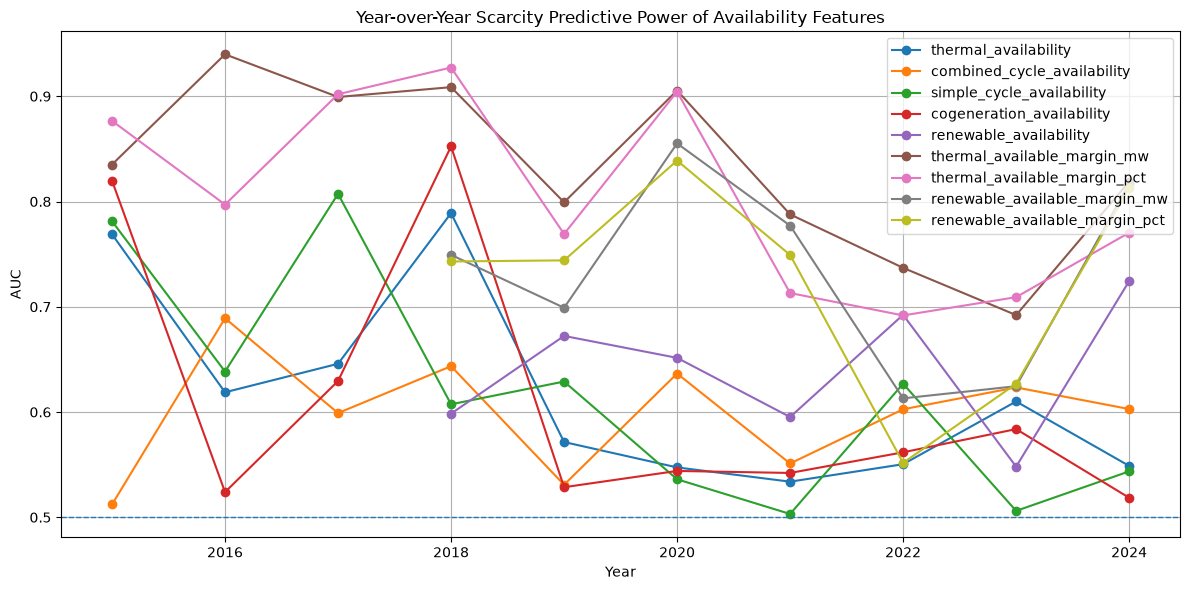

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for feature in availability_features_yoy:

    feature_data = availability_yoy_auc_df[
        availability_yoy_auc_df["feature"] == feature
    ]

    plt.plot(
        feature_data["year_alberta"],
        feature_data["auc"],
        marker="o",
        label=feature
    )


plt.axhline(
    0.5,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Year-over-Year Scarcity Predictive Power of Availability Features"
)

plt.xlabel(
    "Year"
)

plt.ylabel(
    "AUC"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

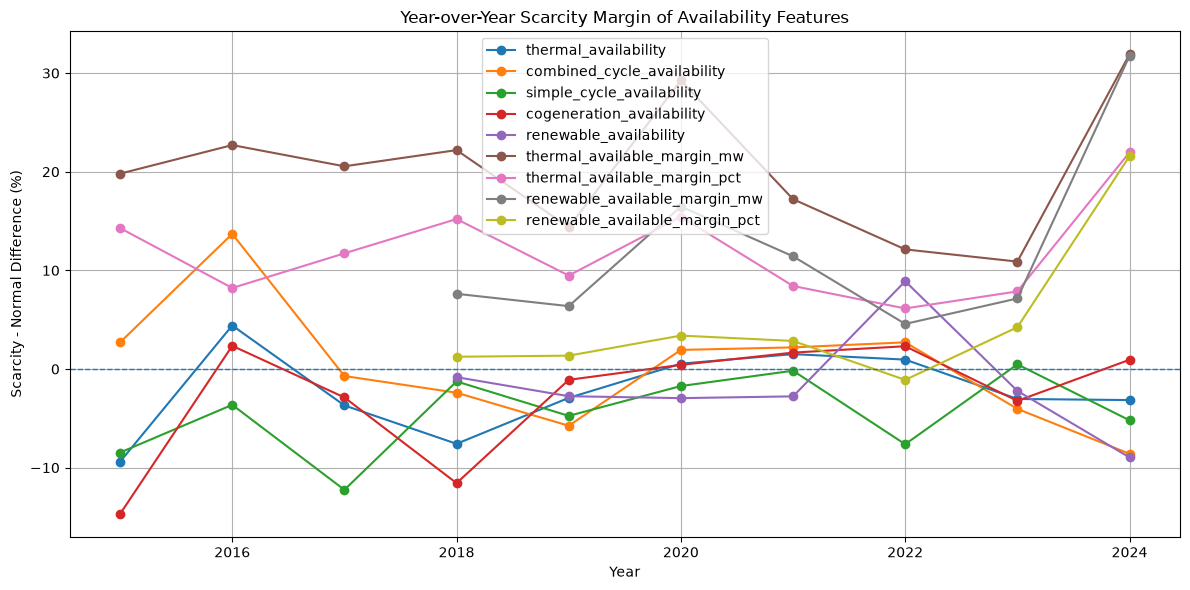

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for feature in availability_features_yoy:
    
    feature_data = availability_yoy_auc_df[
        availability_yoy_auc_df["feature"] == feature
    ]

    plt.plot(
        feature_data["year_alberta"],
        feature_data["margin_pct"],
        marker="o",
        label=feature
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1,
)

plt.title(
    "Year-over-Year Scarcity Margin of Availability Features"
)

plt.xlabel(
    "Year"
)

plt.ylabel(
    "Scarcity - Normal Difference (%)"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

#### Availability AUC

Availability analysis shows that absolute generation availability is only a moderate indicator of scarcity conditions, while availability relative to system demand provides a much stronger signal of system tightness.

Thermal availability alone shows a limited relationship with scarcity events. Average thermal availability during scarcity hours was approximately 5,519 MW compared to 5,286 MW during normal hours, a difference of +233 MW (+4.4%). This positive relationship is counterintuitive at first, but reflects that scarcity events are not necessarily caused by lower absolute available generation. Instead, they occur when available generation is insufficient relative to the level of demand.

To capture this relationship, thermal availability margin was calculated as available thermal generation minus Alberta Internal Load. This metric provides a substantially stronger scarcity signal, with an AUC of approximately 0.69 compared to 0.62 for raw thermal availability. During scarcity hours, thermal availability margin was approximately 525 MW lower than normal operating conditions, representing a 12.2% deterioration in available thermal headroom. In other words, scarcity periods are characterized less by a lack of generation capacity and more by a reduced buffer between available supply and system demand.

The same pattern appears in renewable availability. Absolute renewable availability provides a weaker scarcity signal, while renewable availability margins relative to demand perform substantially better. This suggests that renewable resources contribute to system tightness primarily through their interaction with demand rather than their absolute output levels. A given level of renewable generation can provide very different levels of system support depending on the size of the underlying load requirement.

The year-over-year analysis reinforces this finding. Thermal availability margins consistently outperform raw availability metrics across most years, with particularly strong scarcity separation observed in 2016, 2017, 2018, 2020, and 2024. In 2024, thermal availability margin showed a scarcity-normal difference of approximately -1,070 MW, while renewable availability margin showed a difference of approximately -1,370 MW. These results indicate that recent scarcity events have been associated with significantly reduced operating headroom rather than simply reduced generation availability.

Simple-cycle availability provides comparatively little predictive value, with an AUC near 0.57. This suggests that peaking resources are not a primary differentiator between scarcity and normal conditions. Their availability may not decline during scarcity periods because these units are often maintained or dispatched specifically during tighter system conditions.

Overall, the analysis indicates that scarcity is fundamentally a system tightness problem rather than an availability problem. The most informative metrics are those that measure available supply relative to demand, as these capture the remaining operational cushion available to the Alberta electricity system.

### 3.3. Availability Relative to Demand

In [ ]:
# Normalize thermal availability by Alberta Internal Load.

master["thermal_availability_to_ail"] = (
    master["thermal_availability"]
    / master["ail_mw"]
)


# Compare thermal availability relative to load during scarcity
# and normal operating conditions.

availability_to_load = pd.DataFrame({
    "scarcity": scarcity["thermal_availability_to_ail"].mean(),
    "normal": normal["thermal_availability_to_ail"].mean(),
}, index=["thermal_availability_to_ail"])


# Calculate absolute difference.

availability_to_load["difference"] = (
    availability_to_load["scarcity"]
    - availability_to_load["normal"]
)


# Calculate percentage difference.

availability_to_load["pct_difference"] = (
    availability_to_load["difference"]
    / availability_to_load["normal"].replace(0, np.nan)
    * 100
)


availability_to_load

KeyError: 'thermal_availability_to_ail'

In [ ]:
# Test whether thermal availability relative to system demand
# provides a stronger scarcity signal than raw availability.

availability_to_load_auc = feature_auc(
    master,
    "thermal_availability_to_ail"
)

pd.DataFrame([availability_to_load_auc])

,feature,auc,direction,n_obs
0,thermal_availability_to_ail,0.566086,negative,87665


Thermal availability normalized by Alberta Internal Load was also evaluated to determine whether a percentage-based reserve indicator provided additional insight into scarcity conditions. Thermal availability as a share of load was lower during scarcity hours, averaging 53.4% compared to 55.2% during normal conditions, representing a decline of approximately 1.8 percentage points. However, this metric produced a weaker scarcity classification performance (AUC = 0.57) compared with the absolute thermal availability margin measured in MW (AUC = 0.69).

This suggests that scarcity conditions are better captured by the absolute quantity of available supply headroom rather than the percentage of demand served by available thermal resources. While the normalized metric correctly identifies the direction of system tightness, converting the shortage into MW provides a more operationally relevant measure of system stress.

### 3.4. Availability distribution

In [ ]:
# Refresh scarcity and normal subsets.

scarcity = master[master["scarcity_event"] == 1]
normal = master[master["scarcity_event"] == 0]


# Compare distributions of thermal availability and thermal available margin
# between scarcity and normal hours.

availability_quantiles = [0.10, 0.25, 0.50, 0.75, 0.90]


# Thermal availability distribution

thermal_availability_distribution = pd.DataFrame({
    "scarcity": scarcity["thermal_availability"].quantile(
        availability_quantiles
    ),
    "normal": normal["thermal_availability"].quantile(
        availability_quantiles
    ),
})

thermal_availability_distribution["difference"] = (
    thermal_availability_distribution["scarcity"]
    - thermal_availability_distribution["normal"]
)

thermal_availability_distribution["pct_difference"] = (
    thermal_availability_distribution["difference"]
    / thermal_availability_distribution["normal"].replace(0, np.nan)
    * 100
)


# Thermal available margin distribution

thermal_margin_distribution = pd.DataFrame({
    "scarcity": scarcity["thermal_available_margin_mw"].quantile(
        availability_quantiles
    ),
    "normal": normal["thermal_available_margin_mw"].quantile(
        availability_quantiles
    ),
})

thermal_margin_distribution["difference"] = (
    thermal_margin_distribution["scarcity"]
    - thermal_margin_distribution["normal"]
)

thermal_margin_distribution["pct_difference"] = (
    thermal_margin_distribution["difference"]
    / thermal_margin_distribution["normal"].replace(0, np.nan)
    * 100
)


thermal_availability_distribution, thermal_margin_distribution

(      scarcity  normal  difference  pct_difference
 0.10    4724.3  4383.0       341.3        7.786904
 0.25    5087.0  4784.0       303.0        6.333612
 0.50    5504.0  5221.0       283.0        5.420418
 0.75    6018.0  5709.0       309.0        5.412507
 0.90    6279.0  6178.0       101.0        1.634833,
       scarcity  normal  difference  pct_difference
 0.10   -5629.4 -5264.0      -365.4        6.941489
 0.25   -5272.0 -4868.0      -404.0        8.299096
 0.50   -4806.5 -4350.0      -456.5       10.494253
 0.75   -4399.0 -3761.0      -638.0       16.963574
 0.90   -4005.3 -3294.0      -711.3       21.593807)

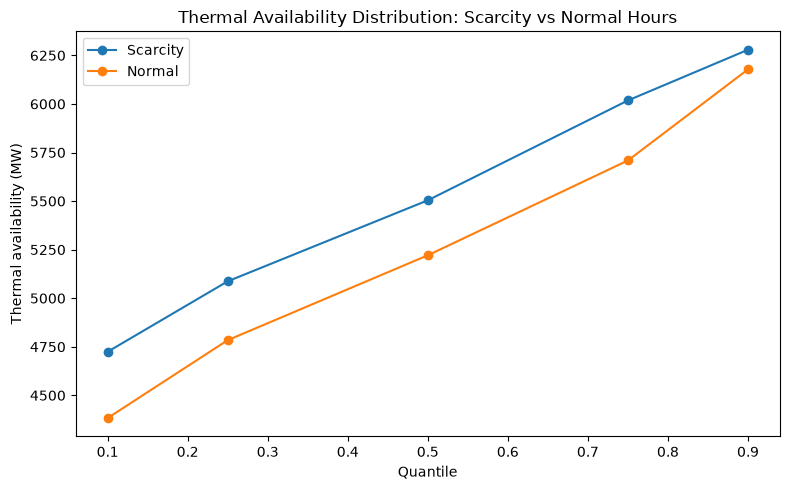

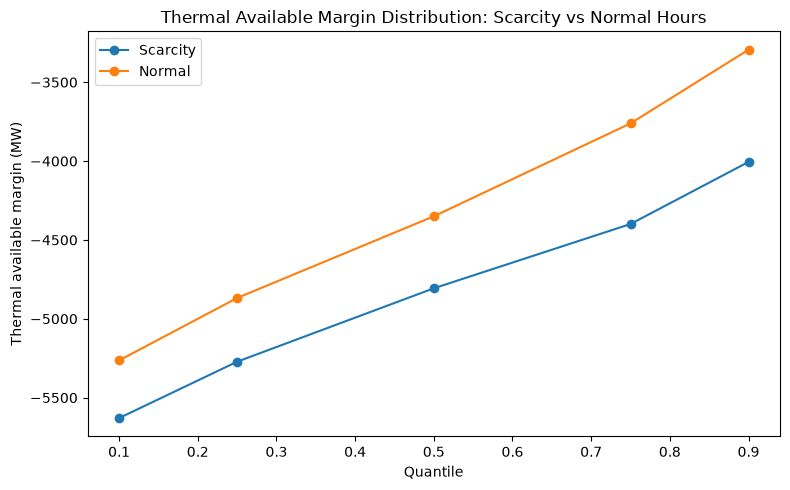

In [ ]:
# Plot thermal availability quantiles during scarcity and normal hours.

plt.figure(figsize=(8, 5))

plt.plot(
    thermal_availability_distribution.index,
    thermal_availability_distribution["scarcity"],
    marker="o",
    label="Scarcity"
)

plt.plot(
    thermal_availability_distribution.index,
    thermal_availability_distribution["normal"],
    marker="o",
    label="Normal"
)

plt.xlabel("Quantile")
plt.ylabel("Thermal availability (MW)")
plt.title("Thermal Availability Distribution: Scarcity vs Normal Hours")
plt.legend()

plt.tight_layout()
plt.show()



# Plot thermal available margin quantiles during scarcity and normal hours.

plt.figure(figsize=(8, 5))

plt.plot(
    thermal_margin_distribution.index,
    thermal_margin_distribution["scarcity"],
    marker="o",
    label="Scarcity"
)

plt.plot(
    thermal_margin_distribution.index,
    thermal_margin_distribution["normal"],
    marker="o",
    label="Normal"
)

plt.xlabel("Quantile")
plt.ylabel("Thermal available margin (MW)")
plt.title("Thermal Available Margin Distribution: Scarcity vs Normal Hours")
plt.legend()

plt.tight_layout()
plt.show()

Thermal availability distributions were compared between scarcity and normal operating periods to determine whether scarcity events were associated with reduced thermal generation capability. Contrary to expectations, thermal availability was consistently higher during scarcity hours across all quantiles. At the median, thermal availability during scarcity periods was approximately 5,504 MW compared with 5,221 MW during normal conditions, representing an increase of approximately 283 MW (+5.4%).

This result indicates that scarcity events are not primarily caused by insufficient thermal generation availability in absolute terms. Instead, higher thermal availability during scarcity periods likely reflects increased thermal unit commitment and dispatch response during stressed system conditions. Thermal generators appear to be operating at higher availability levels when the system is under pressure, meaning raw availability alone does not capture scarcity risk.

The relationship changes when thermal availability is evaluated relative to system demand through thermal available margin, defined as available thermal generation minus Alberta Internal Load. Thermal available margin was consistently lower during scarcity periods across every quantile. At the median, scarcity hours had a thermal margin of approximately -4,807 MW compared with -4,350 MW during normal conditions, representing a reduction of approximately 457 MW. The difference increased further in the upper quantiles, reaching a reduction of more than 700 MW at the 90th percentile.

These results demonstrate that scarcity is driven by supply-demand tightness rather than absolute generation availability. While thermal capacity is often more available during stressed conditions, the available capacity relative to system demand becomes increasingly constrained. This confirms that margin-based features provide a stronger representation of scarcity risk than raw availability measures.

### 3.6. year over year availability compariosn

In [ ]:
# Compare thermal availability during scarcity and normal hours
# by Alberta calendar year.

availability_yoy = (
    master
    .groupby(["year_alberta", "scarcity_event"])["thermal_availability"]
    .mean()
    .unstack()
    .rename(columns={
        0: "normal",
        1: "scarcity"
    })
)

availability_yoy["difference"] = (
    availability_yoy["scarcity"]
    - availability_yoy["normal"]
)

availability_yoy["pct_difference"] = (
    availability_yoy["difference"]
    / availability_yoy["normal"]
    * 100
)

availability_yoy

scarcity_event,normal,scarcity,difference,pct_difference
year_alberta,,,,
2015,4514.806564,4090.484615,-424.321948,-9.398452
2016,4450.430979,4646.750000,196.319021,4.411236
2017,4796.965939,4620.000000,-176.965939,-3.689122
2018,5168.970496,4777.072848,-391.897648,-7.581735
2019,5256.899370,5103.135870,-153.763501,-2.924985
2020,5427.342096,5456.765101,29.423005,0.542125
2021,5444.764821,5526.977162,82.212340,1.509934
2022,5552.288868,5605.292642,53.003774,0.954629
2023,5653.687427,5482.116129,-171.571298,-3.034680


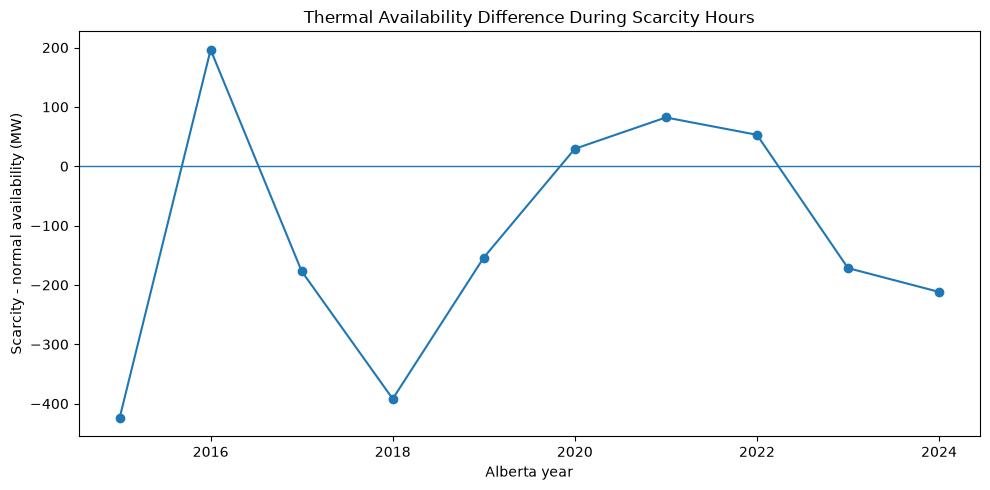

In [ ]:
# Plot the scarcity-normal availability difference over time.

plt.figure(figsize=(10, 5))

plt.axhline(0, linewidth=1)

plt.plot(
    availability_yoy.index,
    availability_yoy["difference"],
    marker="o"
)

plt.xlabel("Alberta year")
plt.ylabel("Scarcity - normal availability (MW)")
plt.title("Thermal Availability Difference During Scarcity Hours")
plt.tight_layout()
plt.show()

Year-over-year comparisons show that the relationship between raw thermal availability and scarcity is inconsistent across Alberta operating years. In some years scarcity events coincide with lower thermal availability, while in others thermal availability is higher during scarcity periods. This variability reinforces that absolute thermal availability is not a reliable standalone indicator of scarcity.

### 3.7. Availbility ramp

In [ ]:
# Compare thermal availability ramps and thermal availability margin ramps
# during scarcity and normal hours.

ramp_features = {}

for hours in [1, 3, 6, 24]:

    # Raw thermal availability ramp
    ramp_features[
        f"thermal_availability_change_{hours}h"
    ] = (
        master["thermal_availability"]
        - master["thermal_availability"].shift(hours)
    )

    # Thermal availability margin ramp
    ramp_features[
        f"thermal_available_margin_change_{hours}h"
    ] = (
        master["thermal_available_margin_mw"]
        - master["thermal_available_margin_mw"].shift(hours)
    )


thermal_ramp_df = pd.DataFrame(
    ramp_features,
    index=master.index
)


thermal_ramp_comparison = pd.DataFrame({

    "scarcity": thermal_ramp_df.loc[
        scarcity.index
    ].mean(),

    "normal": thermal_ramp_df.loc[
        normal.index
    ].mean(),

})


thermal_ramp_comparison["difference"] = (
    thermal_ramp_comparison["scarcity"]
    - thermal_ramp_comparison["normal"]
)


thermal_ramp_comparison

,scarcity,normal,difference
thermal_availability_change_1h,-0.225480,0.062081,-0.287561
thermal_available_margin_change_1h,4.324338,-0.177652,4.501990
thermal_availability_change_3h,-10.759990,0.649628,-11.409617
thermal_available_margin_change_3h,-74.620654,3.493235,-78.113888
thermal_availability_change_6h,-32.082512,1.783509,-33.866021
thermal_available_margin_change_6h,-291.368448,13.511342,-304.879790
thermal_availability_change_24h,-15.791645,1.947569,-17.739214
thermal_available_margin_change_24h,-47.750908,2.911908,-50.662816


In [ ]:
# Compare thermal availability margin deterioration
# during scarcity vs normal hours by year.

thermal_margin_ramp_yoy = []


for year, group in master.groupby("year_alberta"):

    scarcity_year = group[group["scarcity_event"] == 1]
    normal_year = group[group["scarcity_event"] == 0]

    if len(scarcity_year) == 0 or len(normal_year) == 0:
        continue


    for hours in [1, 3, 6, 24]:

        feature = f"thermal_available_margin_change_{hours}h"

        scarcity_mean = (
            thermal_margin_ramp_df
            .loc[scarcity_year.index, feature]
            .mean()
        )

        normal_mean = (
            thermal_margin_ramp_df
            .loc[normal_year.index, feature]
            .mean()
        )


        thermal_margin_ramp_yoy.append({

            "year_alberta": year,
            "feature": feature,

            "scarcity": scarcity_mean,
            "normal": normal_mean,

            "difference": (
                scarcity_mean
                - normal_mean
            ),

            "pct_difference": (
                (scarcity_mean - normal_mean)
                / abs(normal_mean)
                * 100
                if normal_mean != 0
                else np.nan
            )
        })


thermal_margin_ramp_yoy_df = (
    pd.DataFrame(thermal_margin_ramp_yoy)
    .sort_values(
        ["year_alberta", "feature"]
    )
    .reset_index(drop=True)
)


thermal_margin_ramp_yoy_df

,year_alberta,feature,scarcity,normal,difference,pct_difference
0,2015,thermal_available_margin_change_1h,-19.323077,0.280561,-19.603638,-6.987291e+03
1,2015,thermal_available_margin_change_24h,-90.253846,1.974416,-92.228262,-4.671168e+03
2,2015,thermal_available_margin_change_3h,-176.746154,2.621114,-179.367268,-6.843170e+03
3,2015,thermal_available_margin_change_6h,-581.338462,8.555646,-589.894107,-6.894793e+03
4,2016,thermal_available_margin_change_1h,-67.750000,-0.006036,-67.743964,-1.122249e+06
5,2016,thermal_available_margin_change_24h,-236.500000,-0.156492,-236.343508,-1.510259e+05
6,2016,thermal_available_margin_change_3h,-426.750000,0.104328,-426.854328,-4.091464e+05
7,2016,thermal_available_margin_change_6h,-1122.250000,0.366970,-1122.616970,-3.059149e+05
8,2017,thermal_available_margin_change_1h,22.727273,-0.056464,22.783736,4.035120e+04
9,2017,thermal_available_margin_change_24h,-162.454545,-0.562921,-161.891624,-2.875918e+04


The analysis was extended to examine whether rapid changes in available thermal capacity provide an earlier indication of scarcity conditions. Rather than only examining the absolute level of thermal availability, these features measure the change in thermal availability and thermal available margin over different time horizons (1-hour, 3-hour, 6-hour, and 24-hour changes).

The results show a strong relationship between declining thermal availability and scarcity events. Thermal availability changes were negative during scarcity hours across all time horizons, while normal hours generally showed small positive changes. The difference becomes increasingly pronounced over longer horizons, with the 6-hour thermal availability change showing a scarcity-normal difference of approximately -33.9 MW and the 24-hour change showing a difference of approximately -17.7 MW. This indicates that scarcity events are often preceded by deterioration in thermal fleet availability rather than simply occurring when availability is already low.

Thermal available margin changes provide an even stronger signal. Since available margin incorporates system demand, it captures situations where available thermal capacity is declining relative to the amount of capacity required to serve load. During scarcity hours, thermal available margin declined substantially across all time horizons. The 3-hour margin change showed a scarcity-normal difference of approximately -78 MW, while the 6-hour margin change showed a difference of approximately -305 MW. These results suggest that rapid erosion of operating margin is a more informative scarcity indicator than changes in raw thermal availability alone.

The year-over-year analysis shows that thermal margin deterioration has remained a consistent characteristic of scarcity events, although the magnitude varies by year. From 2015 through 2024, scarcity hours generally exhibited significantly larger negative thermal margin changes compared with normal operating hours. The strongest separation occurred during years such as 2016, 2018, 2020, and 2021, where scarcity events were associated with several hundred megawatts of thermal margin loss over 6-hour windows.

The large percentage differences in the year-over-year table should be interpreted cautiously because normal-hour margin changes are often close to zero, causing the percentage calculation to become extremely large. The absolute MW differences provide a more meaningful measure of system stress. Overall, the results indicate that deteriorating thermal available margin is a stronger scarcity signal than static availability levels, suggesting that scarcity events are frequently driven by rapid tightening of the supply-demand balance rather than simply low available generation.

### 3.8. renewables

In [ ]:
# Create renewable availability margin features.
# These are added temporarily for scarcity analysis.

master["renewable_available_margin_mw"] = (
    master["renewable_availability"]
    - master["ail_mw"]
)

master["renewable_available_margin_pct"] = (
    master["renewable_available_margin_mw"]
    / master["ail_mw"]
)


# Create renewable availability and margin ramp features.

renewable_ramp_features = {}

for hours in [1, 3, 6, 24]:

    renewable_ramp_features[
        f"renewable_availability_change_{hours}h"
    ] = (
        master["renewable_availability"]
        - master["renewable_availability"].shift(hours)
    )

    renewable_ramp_features[
        f"renewable_available_margin_change_{hours}h"
    ] = (
        master["renewable_available_margin_mw"]
        - master["renewable_available_margin_mw"].shift(hours)
    )


renewable_ramp_df = pd.DataFrame(
    renewable_ramp_features,
    index=master.index
)


# Compare scarcity vs normal hours.

renewable_ramp_comparison = pd.DataFrame({
    "scarcity": renewable_ramp_df.loc[
        scarcity.index
    ].mean(),

    "normal": renewable_ramp_df.loc[
        normal.index
    ].mean(),
})


renewable_ramp_comparison["difference"] = (
    renewable_ramp_comparison["scarcity"]
    - renewable_ramp_comparison["normal"]
)


renewable_ramp_comparison

,scarcity,normal,difference
renewable_availability_change_1h,1.653006,-0.025867,1.678873
renewable_available_margin_change_1h,6.550822,-0.377125,6.927947
renewable_availability_change_3h,5.288218,-0.098684,5.386902
renewable_available_margin_change_3h,-55.275276,3.637837,-58.913114
renewable_availability_change_6h,9.010515,-0.096185,9.106700
renewable_available_margin_change_6h,-239.752224,15.499262,-255.251487
renewable_availability_change_24h,-18.589647,3.117304,-21.706951
renewable_available_margin_change_24h,-47.864384,4.608123,-52.472507


In [ ]:
# Year-over-year comparison of renewable availability
# and renewable margin deterioration during scarcity.

renewable_yoy_results = []


renewable_features_yoy = [
    "renewable_availability_change_1h",
    "renewable_available_margin_change_1h",
    "renewable_availability_change_3h",
    "renewable_available_margin_change_3h",
    "renewable_availability_change_6h",
    "renewable_available_margin_change_6h",
    "renewable_availability_change_24h",
    "renewable_available_margin_change_24h",
]


for year, group in master.groupby("year_alberta"):

    scarcity_year = group[group["scarcity_event"] == 1]
    normal_year = group[group["scarcity_event"] == 0]


    for feature in renewable_features_yoy:

        scarcity_mean = renewable_ramp_df.loc[
            scarcity_year.index,
            feature
        ].mean()

        normal_mean = renewable_ramp_df.loc[
            normal_year.index,
            feature
        ].mean()


        difference = scarcity_mean - normal_mean


        renewable_yoy_results.append({
            "year_alberta": year,
            "feature": feature,
            "scarcity": scarcity_mean,
            "normal": normal_mean,
            "difference": difference,
        })


renewable_yoy_df = (
    pd.DataFrame(renewable_yoy_results)
    .sort_values(
        ["year_alberta", "feature"]
    )
    .reset_index(drop=True)
)


renewable_yoy_df

,year_alberta,feature,scarcity,normal,difference
0,2015,renewable_availability_change_1h,NaN,NaN,NaN
1,2015,renewable_availability_change_24h,NaN,NaN,NaN
2,2015,renewable_availability_change_3h,NaN,NaN,NaN
3,2015,renewable_availability_change_6h,NaN,NaN,NaN
4,2015,renewable_available_margin_change_1h,NaN,NaN,NaN
5,2015,renewable_available_margin_change_24h,NaN,NaN,NaN
6,2015,renewable_available_margin_change_3h,NaN,NaN,NaN
7,2015,renewable_available_margin_change_6h,NaN,NaN,NaN
8,2016,renewable_availability_change_1h,NaN,NaN,NaN
9,2016,renewable_availability_change_24h,NaN,NaN,NaN


Renewable availability dynamics were analyzed to determine whether changes in renewable output contribute to scarcity events. Similar to thermal analysis, both raw renewable availability changes and renewable available margin changes were evaluated across multiple time horizons.

The results indicate that renewable available margin changes provide a stronger scarcity signal than raw renewable availability changes. While renewable availability ramps are highly variable due to weather-driven generation patterns, renewable margin deterioration captures situations where renewable capacity is declining relative to system demand.

The strongest signal occurs over longer short-term windows, particularly the 6-hour renewable available margin change. During scarcity hours, renewable available margin declined by approximately 240 MW on average, compared with a small positive change during normal hours. This indicates that renewable shortfalls can contribute to tightening system conditions several hours before scarcity events occur.

However, renewable signals are less consistent than thermal availability signals. Renewable output can increase during scarcity hours if generation is recovering from previously low levels, meaning absolute renewable ramps alone do not fully explain system stress. The more relevant measure is whether renewable availability is sufficient relative to demand.

Overall, renewable available margin deterioration appears to be a useful secondary scarcity indicator. It captures periods where renewable generation fails to provide expected system support, but it should be combined with thermal availability and thermal margin indicators to fully characterize Alberta system tightness.

## 4. 

## Section 3 — Capacity Margin Analysis

**Objective:** Evaluate whether scarcity is better explained by the
relationship between available thermal generation and system demand than
by either variable individually.

**Method:** Construct two relative-capacity features, `thermal_capacity_margin`
and `thermal_availability_pct`, combining thermal availability and net
load into a single measure of system tightness.

**Interpretation:** Absolute availability does not indicate whether the
system is stressed, because the operational significance of available
generation depends on the amount of demand it must serve. Relative
measures may therefore provide stronger scarcity signals than either
component alone.

In [ ]:
# Thermal capacity margin as thermal availability minus net load.
df["thermal_capacity_margin"] = df["thermal_availability"] - df["net_load"]

In [ ]:
# Thermal availability as a percentage of net load.
df["thermal_availability_pct"] = df["thermal_availability"] / df["net_load"]

In [ ]:
print(feature_auc(df, "thermal_availability_pct"))
print(feature_auc(df, "thermal_capacity_margin"))

### Observations

**Relative capacity measures outperform absolute availability.**
Thermal availability alone contains only modest scarcity information. By
combining availability with net load, both engineered features produced
substantially stronger AUC values:

- `thermal_availability_pct`: 0.790
- `thermal_capacity_margin`: 0.813

Both outperform net load alone (AUC = 0.780) and significantly
outperform raw thermal availability.

**Capacity margin is the strongest feature tested so far.**
Thermal capacity margin produced the highest AUC observed in the notebook,
consistent with the physical reality of power markets -- operators and
market participants are ultimately concerned with how much dispatchable
capacity remains available after accounting for demand.

**Relative supply-demand balance appears more important than absolute
capacity.**
A thermal availability value of 6,000 MW may represent a comfortable
condition during low demand but a stressed condition during high demand.
Incorporating net load directly gives a more realistic measure of system
tightness.

**Capacity margin slightly outperforms availability percentage.**
This may indicate that scarcity is more closely related to the absolute
MW difference between available capacity and demand than to the
percentage relationship between the two. Decile and regime comparisons
below test whether this holds across different operating conditions.

### Capacity State Analysis

**Objective:** Evaluate how scarcity risk changes when high net load and
low thermal availability occur individually and simultaneously.

**Method:** Classify each hour into one of four operating states --
neither condition, high net load only, low thermal availability only, or
both simultaneously. High net load is the top 20% of net load hours; low
thermal availability is the bottom 20% of thermal availability hours. For
each state, calculate observation count, scarcity frequency, average pool
price, and average thermal availability.

**Interpretation:** If scarcity is fundamentally driven by supply-demand
imbalance, hours with both elevated net load and reduced thermal
availability should show the highest scarcity frequency and pool prices.

In [ ]:
# High net load: top 20th percentile.
df["high_net_load"] = df["net_load"] > df["net_load"].quantile(0.8)

# Low thermal availability: bottom 20th percentile.
df["low_thermal_availability"] = (
    df["thermal_availability"] < df["thermal_availability"].quantile(0.2)
)

In [ ]:
conditions = [
    (~df["high_net_load"]) & (~df["low_thermal_availability"]),
    (df["high_net_load"]) & (~df["low_thermal_availability"]),
    (~df["high_net_load"]) & (df["low_thermal_availability"]),
    (df["high_net_load"]) & (df["low_thermal_availability"]),
]

labels = ["Neither", "High net load", "Low availability", "Both"]

df["capacity_state"] = np.select(conditions, labels, default="unknown")

capacity_state_summary = (
    df.groupby("capacity_state").agg(
        n_hours=("scarcity_event", "size"),
        scarcity_rates=("scarcity_event", "mean"),
        avg_price=("price__ACTUAL_POOL_PRICE", "mean"),
        avg_thermal_availability=("thermal_availability", "mean"),
    ).reindex(labels)
)

capacity_state_summary

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(capacity_state_summary.index, capacity_state_summary["scarcity_rates"] * 100)

plt.ylabel("Scarcity rate (%)")
plt.title("Figure 3. Scarcity frequency by net load and thermal availability state")
plt.xticks(rotation=25, ha="right")

plt.tight_layout()
plt.show()

### Observations

**High net load remains the dominant scarcity condition.**
Hours classified as high net load experienced scarcity nearly 19% of the
time, compared to only 3% for hours where neither condition was present --
consistent with net load being the strongest individual scarcity driver.

**Low thermal availability contributes additional risk.**
Hours with low thermal availability experienced scarcity approximately
6.6% of the time -- a smaller effect than high net load, but still
meaningful.

**Scarcity risk is highest when both conditions occur simultaneously.**
Hours with both elevated net load and reduced thermal availability
experienced scarcity approximately 34% of the time -- the highest
scarcity frequency observed among all operating states, indicating that
supply-side and demand-side stress reinforce one another.

**Pool prices respond similarly.**
Average pool prices rose to roughly $298/MWh when both conditions were
present, showing the same conditions associated with scarcity also
correspond to substantially tighter market outcomes.

**Supply-demand interactions appear more informative than individual
variables.**
This helps explain why thermal capacity margin outperformed both thermal
availability and net load individually.

### Capacity Margin Decile Analysis

**Objective:** Evaluate how scarcity risk changes across different levels
of system tightness.

**Method:** Convert both `thermal_capacity_margin` and
`thermal_availability_pct` into deciles and calculate scarcity frequency,
average pool price, and average capacity conditions for each bucket.

**Interpretation:** If capacity conditions genuinely drive scarcity, the
lowest-capacity deciles should show substantially higher scarcity
frequencies and pool prices than the highest-capacity deciles.

In [ ]:
df["thermal_availability_pct_decile"] = pd.qcut(
    df["thermal_availability_pct"], 10, labels=False, duplicates="drop"
)

margin_decile_summary = (
    df.groupby("thermal_availability_pct_decile").agg(
        n_hours=("scarcity_event", "size"),
        scarcity_rate=("scarcity_event", "mean"),
        avg_thermal_availability_pct=("thermal_availability_pct", "mean"),
        avg_price=("price__ACTUAL_POOL_PRICE", "mean"),
    )
)

margin_decile_summary

In [ ]:
# Decile 0 = tightest margin hours; decile 9 = most comfortable margin hours.
df["thermal_capacity_margin_decile"] = pd.qcut(
    df["thermal_capacity_margin"], 10, labels=False, duplicates="drop"
)

capacity_margin_decile_summary = (
    df.groupby("thermal_capacity_margin_decile").agg(
        n_hours=("scarcity_event", "size"),
        scarcity_rate=("scarcity_event", "mean"),
        avg_margin=("thermal_capacity_margin", "mean"),
        avg_price=("price__ACTUAL_POOL_PRICE", "mean"),
    )
)

capacity_margin_decile_summary

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    margin_decile_summary.index,
    margin_decile_summary["scarcity_rate"] * 100,
    marker="o",
    label="Thermal availability %",
)
plt.plot(
    capacity_margin_decile_summary.index,
    capacity_margin_decile_summary["scarcity_rate"] * 100,
    marker="o",
    label="Thermal capacity margin",
)

plt.xlabel("Decile")
plt.ylabel("Scarcity rate (%)")
plt.title("Figure 4. Scarcity frequency by capacity condition decile")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Observations

**Scarcity risk declines almost monotonically as capacity conditions
improve.**
Both metrics produced smooth, monotonic scarcity probability curves:

- Thermal capacity margin: 29.7% (decile 0) -> 0.2% (decile 9)
- Thermal availability %: 24.8% (decile 0) -> 0.2% (decile 9)

**Capacity margin produces the strongest separation in stressed
conditions.**
The lowest capacity margin decile experiences scarcity nearly 30% of the
time, versus approximately 25% for the lowest availability-percentage
decile -- consistent with the earlier AUC result and suggesting absolute
MW shortfalls carry slightly more scarcity information than
percentage-based measures.

**Pool prices respond in the same direction as scarcity frequency.**
For thermal capacity margin, average price falls from $258/MWh (decile 0)
to $22/MWh (decile 9), reinforcing that these variables capture
meaningful operational stress rather than statistical noise.

**Capacity margin and availability percentage describe the same
underlying phenomenon.**
Although constructed differently, both curves nearly overlap -- both are
built from the same relationship between thermal availability and net
load, which supports the robustness of the core finding.

**Thermal capacity margin emerges as the preferred capacity-state
metric.**
It achieved the strongest AUC in the notebook, produced the highest
scarcity concentration in the most constrained decile, and is expressed
directly in MW, making it easier to interpret operationally than a
percentage ratio. It will serve as the primary capacity-state metric
moving forward.

### Load and Availability Heatmap

In [ ]:
df["load_decile"] = pd.qcut(df["net_load"], 10, labels=False, duplicates="drop")

df["availability_decile"] = pd.qcut(
    df["thermal_availability_pct"], 10, labels=False, duplicates="drop"
)

In [ ]:
heatmap_df = (
    df.groupby(["load_decile", "availability_decile"])["scarcity_event"]
    .mean()
    .unstack()
)

plt.figure(figsize=(9, 7))

plt.imshow(heatmap_df, aspect="auto", origin="lower")
plt.colorbar(label="Scarcity frequency")

plt.xlabel("Availability decile")
plt.ylabel("Load decile")
plt.title("Figure 5. Scarcity risk by load and thermal availability")

plt.tight_layout()
plt.show()

In [ ]:
# Test AUC values for each year to check temporal stability.
for year in [2020, 2021, 2022, 2023, 2024, 2025]:
    year_df = df[df["timestamp"].dt.year == year]
    result = feature_auc(year_df, "thermal_capacity_margin")
    print(f"  {year}: {result['auc']:.3f}")

### Observations

**Scarcity risk increases as load rises and availability falls.**
The heatmap shows a clear transition from low scarcity frequencies in the
upper-right corner (low load, high availability) to high scarcity
frequencies in the lower-left corner (high load, low availability).

**High load alone is not sufficient to create scarcity.**
Even within the highest load deciles, scarcity frequency remains
relatively low when thermal availability is high, suggesting elevated
demand does not automatically produce scarcity if sufficient dispatchable
generation remains available.

**Availability becomes most important during stressed conditions.**
The largest scarcity frequencies occur when high load coincides with low
availability -- the highest load decile combined with the lowest
availability decile approached a 40% scarcity rate.

**The capacity margin relationship appears structurally persistent.**
Thermal capacity margin maintained strong predictive performance across
every year examined (2020: 0.931, 2021: 0.840, 2022: 0.798, 2023: 0.806,
2024: 0.875, 2025: 0.847), suggesting the relationship is not driven by a
single weather regime, market event, or sample period, but captures a
persistent feature of Alberta market dynamics.

### Composite Stress Score Validation

**Objective:** Evaluate whether a composite system stress score provides
stronger scarcity separation than its individual component variables.

**Method:** Calculate ROC AUC using `stress_score_norm` against
`scarcity_event`, and compare against the previously tested individual
variables (net load, renewable share, wind generation). The stress score
combines high net load, low renewable share, and low wind generation.

**Interpretation:** If the composite score outperforms the individual
features, it suggests scarcity is driven by multiple interacting system
conditions rather than a single operational variable.

In [ ]:
auc = roc_auc_score(df["scarcity_event"], df["stress_score_norm"])

print(auc)

In [ ]:
# Two alternative stress-score definitions -- one with the reserve proxy
# feature, one without -- to see whether AUC improves without it.
stress_3 = (
    df["net_load_pct"] + df["low_renewable_pct"] + df["low_wind_pct"]
)

stress_4 = (
    df["net_load_pct"] + df["low_renewable_pct"] + df["low_wind_pct"] + df["low_reserve_pct"]
)

print(roc_auc_score(df["scarcity_event"], stress_3))
print(roc_auc_score(df["scarcity_event"], stress_4))

### Observations

**The composite stress score does not outperform net load.**
The stress score produced an AUC of approximately 0.75-0.76, while net
load alone achieved 0.78. Combining multiple scarcity indicators does not
automatically create a stronger ranking variable -- here, the strongest
signal is already captured by net load itself.

**Net load already contains information from several stress score
components.**
Because net load = demand - renewable generation, renewable share and
wind generation are not entirely independent of net load. Adding them to
the composite may introduce variables that partially describe the same
underlying condition rather than contributing new information. Future
composites should account for this overlap, and composites defined by
statistical optimization rather than physical intuition may be worth
exploring.

**Reserve conditions contribute incremental information.**
Adding the reserve proxy produced a small improvement (3-variable score:
0.753 -> 4-variable score: 0.760), showing that even a weak standalone
feature can add useful information in combination with others.

**The decline relative to earlier work is likely driven by the dataset
rebuild.**
The current dataset incorporates revised generation, outage,
availability, and interchange data along with a rebuilt feature
engineering pipeline, so changes in stress score performance may reflect
improvements in data quality rather than changes in underlying market
relationships.

### Stress Score Decile Analysis

**Objective:** Evaluate whether higher stress score values correspond to
progressively higher scarcity probabilities.

**Method:** Convert `stress_score_norm` into deciles (0 = lowest-stress
10% of hours, 9 = highest-stress 10%) and calculate average scarcity
frequency within each decile, comparing against net-load deciles.

**Interpretation:** A useful stress score should produce increasing
scarcity probabilities as stress increases; a monotonic relationship
indicates the score successfully ranks system conditions from low to high
risk.

In [ ]:
df["stress_decile"] = pd.qcut(
    df["stress_score_norm"], q=10, labels=False, duplicates="drop"
)

stress_decile_rates = df.groupby("stress_decile")["scarcity_event"].mean()

df["net_load_decile"] = pd.qcut(
    df["net_load"], q=10, labels=False, duplicates="drop"
)

netload_decile_rates = df.groupby("net_load_decile")["scarcity_event"].mean()

decile_comparison = pd.DataFrame({
    "stress_score": stress_decile_rates,
    "net_load": netload_decile_rates,
})

decile_comparison

### Observations

**The stress score provides additional context at moderate stress
levels.**
The stress score produces slightly higher scarcity frequencies than net
load throughout most of the distribution, suggesting renewable and wind
conditions help identify risk differences not fully captured by net load
alone, particularly at low-to-moderate stress.

**Net load remains strongest during extreme system conditions.**
In the highest decile, net load produced a scarcity frequency of
approximately 25%, versus 21% for the stress score -- net load remains
the dominant scarcity variable as the system approaches its most
constrained operating conditions, consistent with the earlier AUC
analysis.

## Section 4 — Simple-Cycle Outage Investigation

**Objective:** Investigate whether simple-cycle outages are uniquely
important during scarcity events.

Earlier sections showed total outages were relatively weak predictors of
scarcity, but simple-cycle outages appeared more informative than other
outage categories. This section tests whether that signal persists across
multiple views of the data.

**Method:** Evaluate simple-cycle outages using single-feature ROC AUC,
scarcity-vs-normal summary statistics, outage decile analysis, and a
high-net-load subset comparison.

**Interpretation:** If simple-cycle outages matter operationally, scarcity
frequency should increase when simple-cycle outages are elevated,
especially during already-stressed system conditions.

In [ ]:
# Define high simple-cycle outage conditions (top 20th percentile).
df["high_simple_cycle_outage"] = (
    df["outages__outage_simple_cycle"] > df["outages__outage_simple_cycle"].quantile(0.8)
)

In [ ]:
conditions = [
    (~df["high_net_load"]) & (~df["high_simple_cycle_outage"]),
    (df["high_net_load"]) & (~df["high_simple_cycle_outage"]),
    (~df["high_net_load"]) & (df["high_simple_cycle_outage"]),
    (df["high_net_load"]) & (df["high_simple_cycle_outage"]),
]

labels = ["Neither", "High net load", "High SC outage", "Both"]

df["simple_cycle_outage_state"] = np.select(conditions, labels, default="unknown")

simple_cycle_outage_state_summary = (
    df.groupby("simple_cycle_outage_state").agg(
        n_hours=("scarcity_event", "size"),
        scarcity_rates=("scarcity_event", "mean"),
        avg_price=("price__ACTUAL_POOL_PRICE", "mean"),
        avg_thermal_availability=("thermal_availability", "mean"),
    ).reindex(labels)
)

simple_cycle_outage_state_summary

In [ ]:
# Re-define high net load as a boolean series, then re-derive the
# high-load subset (added .copy() to avoid a SettingWithCopyWarning
# on the decile assignment below).
high_net_load = df["net_load"] > df["net_load"].quantile(0.8)

high_df = df[high_net_load].copy()

high_df["simple_cycle_outage_decile"] = pd.qcut(
    high_df["outages__outage_simple_cycle"], 10, labels=False, duplicates="drop"
)

high_load_sc_summary = (
    high_df.groupby("simple_cycle_outage_decile").agg(
        n_hours=("scarcity_event", "size"),
        scarcity_rate=("scarcity_event", "mean"),
        avg_outage=("outages__outage_simple_cycle", "mean"),
        avg_price=("price__ACTUAL_POOL_PRICE", "mean"),
    )
)

high_load_sc_summary

In [ ]:
# Simple-cycle capacity as a share of net load.
df["simple_cycle_share_of_load"] = (
    df["gen__gen_simple_cycle_system_available"] / df["net_load"]
)

feature_auc(df, "simple_cycle_share_of_load")

In [ ]:
df["simple_cycle_share_decile"] = pd.qcut(
    df["simple_cycle_share_of_load"], 10, labels=False, duplicates="drop"
)

sc_share_summary = (
    df.groupby("simple_cycle_share_decile").agg(
        n_hours=("scarcity_event", "size"),
        scarcity_rate=("scarcity_event", "mean"),
        avg_share=("simple_cycle_share_of_load", "mean"),
        avg_price=("price__ACTUAL_POOL_PRICE", "mean"),
    )
)

sc_share_summary

### Observations

**Simple-cycle outages appear most informative during already-stressed
conditions.**
Outage magnitude alone produced inconsistent scarcity relationships when
all hours were examined together, suggesting simple-cycle outages are not
a universal scarcity driver and instead depend on broader system
conditions.

**The relationship strengthens substantially during high net-load
periods.**
Restricting to the highest 20% of net-load hours, scarcity frequency
generally increases as simple-cycle outages rise -- peaking-unit outages
become more important once the system already requires large amounts of
dispatchable generation.

**High net load and elevated simple-cycle outages together produce the
highest scarcity frequencies.**
Hours with both conditions experienced scarcity approximately 32% of the
time -- substantially higher than either condition individually.

**Simple-cycle capacity relative to system demand contains meaningful
scarcity information.**
Simple-cycle share of load produced a stronger signal than availability
alone -- scarcity frequency declined from approximately 23% in the lowest
share-of-load decile to approximately 1% in the highest, indicating
scarcity becomes less likely when peaking resources represent a larger
proportion of system requirements.

**The underlying mechanism remains unclear.**
The current dataset does not include ramp rates, unit commitment
decisions, dispatch stack position, operating reserve deployment, or
real-time dispatch behaviour. Simple-cycle variables should currently be
viewed as informative scarcity indicators rather than fully understood
causal drivers -- future datasets with commitment and dispatch data may
clarify the mechanism.

## Section 5 — Regime Profiles

**Objective:** Characterize the operating conditions associated with
scarcity events.

**Method:** Compare scarcity and non-scarcity hours across net load,
renewable share, wind generation, imports, thermal availability, thermal
availability %, thermal capacity margin, and outages, then examine
distribution differences and load/availability interaction heatmaps.

**Interpretation:** Rather than identifying new predictors, this section
summarizes what scarcity conditions actually look like operationally.

In [ ]:
profile_features = [
    "net_load",
    "renewable_share",
    "gen_wind",
    "total_imports",
    "outage_total",
    "thermal_availability",
    "thermal_capacity_margin",
    "thermal_availability_pct",
]

In [ ]:
scarcity = df[df["scarcity_event"] == 1]
normal = df[df["scarcity_event"] == 0]

profile = pd.DataFrame({
    "scarcity": scarcity[profile_features].mean(),
    "normal": normal[profile_features].mean(),
})

profile["difference"] = profile["scarcity"] - profile["normal"]
profile["pct_difference"] = profile["difference"] / profile["normal"] * 100

profile.sort_values("pct_difference", ascending=False)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plot_features = ["net_load", "gen_wind", "thermal_capacity_margin", "renewable_share"]

for ax, feature in zip(axes.flatten(), plot_features):
    scarcity_vals = scarcity[feature].dropna()
    normal_vals = normal[feature].dropna()

    ax.violinplot([normal_vals, scarcity_vals], positions=[0, 1], showmedians=True)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Normal", "Scarcity"])
    ax.set_title(feature)
    ax.grid(True, alpha=0.3)

fig.suptitle("Figure 6. Feature distributions: scarcity vs normal hours", fontsize=13)
plt.tight_layout()
plt.show()

### Observations

**Scarcity hours exhibit a distinct operating profile.**
Compared to normal hours, scarcity events are characterized by higher net
load, lower renewable production, lower wind generation, reduced thermal
availability, and substantially tighter capacity margins -- consistent
across both average-value comparisons and distributional analysis.

**Renewable conditions differ more than outage conditions.**
Wind generation and renewable share were materially lower during scarcity
events across nearly the entire distribution, while total outage levels
differed only modestly -- reinforcing that outages alone are insufficient
to explain scarcity risk.

**Imports increase during scarcity events.**
Scarcity hours exhibited substantially higher import levels, suggesting
interties respond to tightening system conditions -- though this analysis
cannot determine whether imports lead or merely respond to emerging
scarcity.

**Capacity margin provides the clearest summary of system stress.**
Many of the individual scarcity characteristics identified throughout the
notebook ultimately converge in thermal capacity margin: higher demand,
lower renewable production, reduced availability, and tighter operating
conditions all contribute to lower margins, explaining why capacity
margin emerged as the strongest scarcity variable tested.

## Summary

The central finding of this notebook is that **thermal capacity margin**
is the strongest scarcity variable tested.

Thermal capacity margin achieved an overall AUC of 0.813, outperforming
net load, renewable share, wind generation, imports, outages, and raw
availability measures. The relationship also remained strong across
individual years, suggesting capacity margin captures a persistent
feature of Alberta market structure rather than a single-year artifact.

The broader interpretation is that scarcity is best understood as a
tightening supply-demand balance problem. High net load matters, but
scarcity risk rises most sharply when elevated demand coincides with
reduced available thermal capacity and weaker renewable output.

Outages, imports, and simple-cycle availability remain useful secondary
indicators, but they appear most meaningful when interpreted within the
broader capacity margin framework.

The regime-labelled, feature-engineered dataset produced here (net load,
thermal availability, thermal capacity margin, capacity state, and
simple-cycle share of load) provides the foundation for Notebook 3's
forecasting work.